# Transfer Market Valuation Forecaster
### Predicting player market values for roster planning and transfer-window negotiations

**Course:** OPIM 5671 Data Mining and Time Series Forecasting, Project #1 (Time Series Forecasting Applications)

## Project summary
| | |
|---|---|
| **Forecasting question** | Can historical market momentum and external indicators forecast a player's market valuation heading into future transfer windows? |
| **Target** | Market value in € millions |
| **Frequency and horizon** | Quarterly data; forecasts 2 to 4 quarters ahead (6 to 12 months) |
| **Intended users** | Sporting directors, technical scouting directors, agent negotiation teams |
| **Decisions supported** | Buy / sell / hold timing, bid caps for transfer windows, over- or under-valuation alerts |
| **Data** | Transfermarkt valuation history from Kaggle (`kanchana1990/football-transfer-value-intelligence-2024`) |
| **Validation design** | Chronological split: train on data before 2023, test on 2023-2024 |

## Notebook roadmap
1. Setup and data download
2. Data audit
3. Feasibility check
4. Cohort selection
5. Quarterly regularization
6. Feature engineering
7. Phase 1 summary and decisions log

*Modeling, decision logic and the prototype are added in later phases.*

**How to read this notebook:** every section opens with a short note on what we do and why, then the code, then a one-line takeaway. Settings that we chose (thresholds, caps, tier ordering) sit at the top of their code cell so they are easy to find and change.

## 1. Setup and data download

### 1.1 Download the dataset
**What we do:** Download the Transfermarkt dataset from Kaggle with `kagglehub`.

**Why:** The dataset is the only data source for the project, so we fetch it the same way every run. Re-running this cell reuses the cached copy.

**What to look for:** A printed folder path. The next cells read every file in that folder.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kanchana1990/football-transfer-value-intelligence-2024")

print("Path to dataset files:", path)

100%|██████████| 186k/186k [00:00<00:00, 14.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1


### 1.2 Import libraries
**What we do:** Import the libraries used throughout the notebook: `pandas` and `numpy` for data, `matplotlib` for charts, `display` for clean tables. Later sections add `statsmodels` for the forecasting models.

In [ ]:
# Libraries used throughout the notebook
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Show full text in table cells (helps with long column descriptions)
pd.set_option("display.max_colwidth", 120)

### 1.3 List the files in the download
**What we do:** List each file in the dataset folder with its size.

**What to look for:** Three CSV files: a data dictionary, a player attribute table and a valuation history table.

In [ ]:
# Collect file name and size for every file in the dataset folder
inventory = []
for root, dirs, files in os.walk(path):          # 'path' comes from the download cell above
    for f in files:
        full_path = os.path.join(root, f)
        inventory.append({"File": f, "Size (KB)": round(os.path.getsize(full_path) / 1024, 1)})

display(pd.DataFrame(inventory))

,File,Size (KB)
0,data_dictionary.csv,2.1
1,transfermarkt_player_values.parquet,68.5
2,transfermarkt_value_history.csv,593.6
3,transfermarkt_player_values.csv,142.2


## 2. Data audit

Before modeling, we need to know what the data contains, how it is structured and whether it can be trusted.

### 2.1 Load the tables and inspect their structure
**What we do:** Load every CSV into a dictionary and summarize each one: rows, columns, missing values, data types and an example value.

**Why:** The two main tables answer different questions. The **value history** table has one row per valuation event and gives us the time series. The **player** table has one row per player and gives us attributes such as league and position. They join on `player_id`.

**What to look for:** Column names we will rely on (`valuation_date`, `value_eur`, `age_at_date`, `league_name`), and any columns with missing values.

In [ ]:
# Load every CSV in the dataset folder into one dictionary
csv_files = [os.path.join(root, f)
             for root, dirs, files in os.walk(path)
             for f in files if f.endswith(".csv")]

raw_tables = {}   # dictionary: file name -> DataFrame (used by every later section)
for file_path in csv_files:
    raw_tables[os.path.basename(file_path)] = pd.read_csv(file_path)

# Overview: one row per file (replaces the long printouts)
overview = pd.DataFrame({
    "Rows": {name: df_.shape[0] for name, df_ in raw_tables.items()},
    "Columns": {name: df_.shape[1] for name, df_ in raw_tables.items()},
    "Total missing cells": {name: int(df_.isna().sum().sum()) for name, df_ in raw_tables.items()},
})
print("DATASET OVERVIEW")
display(overview)

DATASET OVERVIEW


,Rows,Columns,Total missing cells
data_dictionary.csv,34,3,0
transfermarkt_value_history.csv,9764,8,0
transfermarkt_player_values.csv,508,36,14


In [ ]:
# Schema table for each data file: type, missing count, unique count, and an example value
for name, df_ in raw_tables.items():
    if name == "data_dictionary.csv":
        continue
    schema = pd.DataFrame({
        "dtype": df_.dtypes.astype(str),
        "missing": df_.isna().sum(),
        "unique": df_.nunique(),
        "example": df_.iloc[0],
    })
    print(f"\nSCHEMA: {name}  ({df_.shape[0]:,} rows x {df_.shape[1]} columns)")
    display(schema)


SCHEMA: transfermarkt_value_history.csv  (9,764 rows x 8 columns)


,dtype,missing,unique,example
player_id,int64,0,508,108390
valuation_date,object,0,1115,01/06/2016
value_eur,int64,0,157,35000000
value_display,object,0,157,€35.00m
club,object,0,555,Chelsea FC
age_at_date,int64,0,19,24
year,int64,0,18,2016
month,int64,0,12,5



SCHEMA: transfermarkt_player_values.csv  (508 rows x 36 columns)


,dtype,missing,unique,example
player_id,int64,0,508,418560
name,object,0,507,Erling Haaland
age,float64,7,31,25.0
nationality,object,7,60,Norway
position,object,0,42,€200.00m
position_group,object,0,1,Other
current_club,object,0,66,Norway
league_name,object,0,5,Premier League
current_value_eur,float64,0,42,200000000.0
current_value_tier,object,0,5,World Class (100M+)


In [ ]:
# Show the data dictionary as a clean lookup table (what each column means)
print("\nDATA DICTIONARY")
display(raw_tables["data_dictionary.csv"])


DATA DICTIONARY


,column,type,description
0,player_id,string,Transfermarkt unique player ID
1,name,string,Player full name
2,age,int,Current age (at time of scrape)
3,nationality,string,Player nationality country
4,position,string,Specific position (e.g. Centre-Forward)
5,position_group,string,Grouped position: Forward / Midfielder / Defender / Goalkeeper
6,current_club,string,Club at time of scrape
7,league_name,string,"League the player was listed in (Premier League, La Liga, etc.)"
8,current_value_eur,float,Current market value in EUR
9,current_value_tier,string,Bucketed tier: World Class / Elite / Top / Regular / Developing


**Takeaway:** The download holds three files. The value history has 9,764 valuation events (the proposal quoted 9,779; we report the dataset's actual count). The player table covers 508 players. Values are in euros, so we convert to € millions in the next step.

### 2.2 Parse dates and validate the data
**What we do:** Parse the valuation dates, sort each player's events chronologically, convert euros to € millions and run four quality checks.

**Decision:** The dates are stored **day-first** (for example `13/06/2023` is 13 June). Letting pandas guess month-first fails on the first day above 12, so we pass the format explicitly. We then confirm the parse against the dataset's own `year` and `month` columns.

**Why the checks matter:** Wrong dates would silently misplace observations into the wrong quarters. Duplicate rows or players missing from the attribute table would break the later joins.

**What to look for:** All four checks read `OK`.

In [ ]:
# Load the two tables, parse dates, sort chronologically, convert value to € millions
hist = raw_tables["transfermarkt_value_history.csv"].copy()      # one row per valuation event
players = raw_tables["transfermarkt_player_values.csv"].copy()   # one row per player (attributes)

# Parse dates with an explicit day-first format (dd/mm/yyyy)
hist["valuation_date"] = pd.to_datetime(hist["valuation_date"], format="%d/%m/%Y")

# Sort chronologically within each player (same pattern as the Apple notebook)
hist = hist.sort_values(["player_id", "valuation_date"]).reset_index(drop=True)

# Convert euros to millions so the target matches the proposal (€ Millions)
hist["value_m"] = hist["value_eur"] / 1e6

# Number of valuation events per player = length of each player's series
events_per_player = hist.groupby("player_id")["valuation_date"].count()

In [ ]:
# Key facts about the data: date range, size, series length, value range
key_facts = pd.Series({
    "First valuation date": hist["valuation_date"].min().date(),
    "Last valuation date": hist["valuation_date"].max().date(),
    "Valuation events": f"{len(hist):,}",
    "Players in history": hist["player_id"].nunique(),
    "Players in player table": players["player_id"].nunique(),
    "Median events per player": events_per_player.median(),
    "Min / Max events per player": f"{events_per_player.min()} / {events_per_player.max()}",
    "Median value (€M)": round(hist["value_m"].median(), 1),
    "Max value (€M)": round(hist["value_m"].max(), 1),
}, name="Value").to_frame()

print("KEY FACTS")
display(key_facts)

KEY FACTS


,Value
First valuation date,2009-05-27
Last valuation date,2026-02-11
Valuation events,"9,764"
Players in history,508
Players in player table,508
Median events per player,19.0
Min / Max events per player,2 / 45
Median value (€M),15.0
Max value (€M),200.0


**Takeaway:** The history spans about ten years and players average roughly 19 valuation events each (9,764 events across 508 players). Compare the median and maximum value above: a large gap means the target is right-skewed, with a few stars worth far more than the typical player.

In [ ]:
# Data quality checks (expected value shown next to the result)

# Compare the parsed date with the dataset's own year/month columns, as a running month number
date_month = hist["valuation_date"].dt.year * 12 + hist["valuation_date"].dt.month
col_month  = hist["year"] * 12 + hist["month"]
mismatch   = date_month != col_month

# Known source issue: the date is the 1st of a month and the month column is one month earlier
known_shift = mismatch & (hist["valuation_date"].dt.day == 1) & ((date_month - col_month) == 1)

checks = pd.DataFrame([
    ["Year/month mismatches NOT explained by the 1st-of-month shift", int((mismatch & ~known_shift).sum()), 0],
    ["Duplicate player-date rows", int(hist.duplicated(["player_id", "valuation_date"]).sum()), 0],
    ["Players in history but not in player table",
     len(set(hist["player_id"]) - set(players["player_id"])), 0],
], columns=["Check", "Result", "Expected"])
checks["Status"] = np.where(checks["Result"] == checks["Expected"], "OK", "REVIEW")

print("DATA QUALITY CHECKS")
display(checks)
print(f"\nKnown issue: {int(known_shift.sum())} of {len(hist):,} rows ({known_shift.mean():.1%}) are dated the 1st of a month "
      f"while the year/month columns point to the previous month. We keep the parsed dates.")

DATA QUALITY CHECKS


,Check,Result,Expected,Status
0,Year/month mismatches NOT explained by the 1st-of-month shift,0,0,OK
1,Duplicate player-date rows,0,0,OK
2,Players in history but not in player table,0,0,OK



Known issue: 234 of 9,764 rows (2.4%) are dated the 1st of a month while the year/month columns point to the previous month. We keep the parsed dates.


In [ ]:
# Sensitivity check: how many rows would land in a different quarter if the year/month columns were right?
q_from_date = hist["valuation_date"].dt.year * 4 + hist["valuation_date"].dt.quarter   # our method
q_from_cols = hist["year"] * 4 + (hist["month"] - 1) // 3 + 1                          # dataset's columns
changed = q_from_date != q_from_cols

print(f"Rows that change quarter: {int(changed.sum())} of {len(hist):,} ({changed.mean():.2%})")

# Same check for the cohort players, if the cohort has already been selected
if "cohort_ids" in globals():
    in_cohort = hist["player_id"].isin(cohort_ids)
    print(f"Cohort rows that change quarter: {int((changed & in_cohort).sum())} of {int(in_cohort.sum())}")

Rows that change quarter: 114 of 9,764 (1.17%)


**Takeaway:** Parsed dates are valid and the tables join cleanly. The dataset's own `year` and `month` columns disagree with the parsed date in 234 rows (2.4%), always for dates on the 1st of a month, where the month column is one month earlier. We treat the parsed date as the source of truth. If the month column were right instead, 114 of 9,764 events (1.2%) would fall in the adjacent quarter; the same check on the final cohort is reported in section 4.3.

### 2.3 Visual overview
**What we do:** Four panels: series length per player, events per year, leagues and position groups.

**What to look for:** (1) Most players have many events, which is encouraging for time series work. (2) Whether events are spread evenly across years. (3) Which leagues exist, since we will use league as a feature. (4) Whether `position_group` actually separates players.

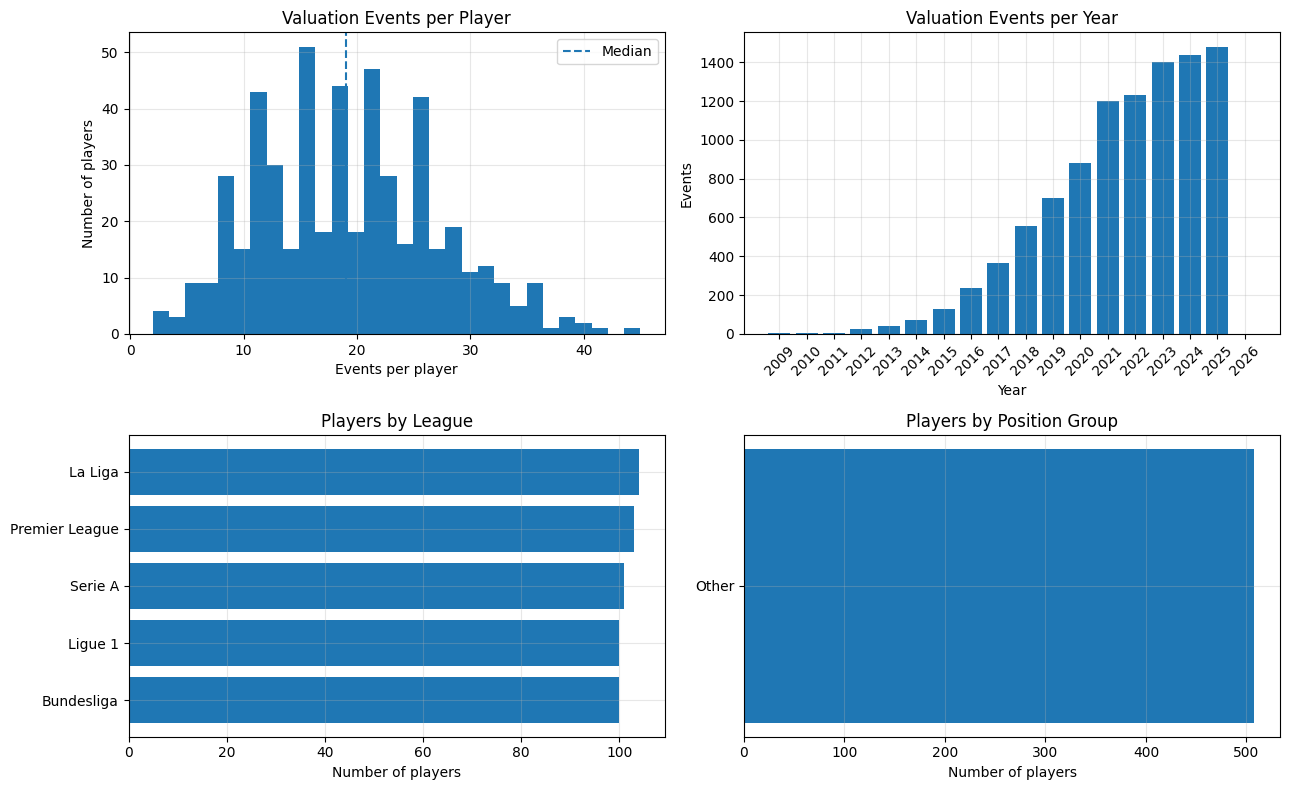

In [ ]:
# Four-panel overview of the dataset
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1: how long is each player's series?
axes[0, 0].hist(events_per_player, bins=30)
axes[0, 0].axvline(events_per_player.median(), linestyle="--", label="Median")
axes[0, 0].set_title("Valuation Events per Player")
axes[0, 0].set_xlabel("Events per player")
axes[0, 0].set_ylabel("Number of players")
axes[0, 0].legend()

# Panel 2: how is the history spread over time?
events_per_year = hist["year"].value_counts().sort_index()
axes[0, 1].bar(events_per_year.index.astype(str), events_per_year.values)
axes[0, 1].set_title("Valuation Events per Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Events")
axes[0, 1].tick_params(axis="x", rotation=45)

# Panel 3: which leagues are covered? (needed for the league-tier feature later)
league_counts = players["league_name"].value_counts().sort_values()
axes[1, 0].barh(league_counts.index, league_counts.values)
axes[1, 0].set_title("Players by League")
axes[1, 0].set_xlabel("Number of players")

# Panel 4: which positions are covered?
pos_counts = players["position_group"].value_counts().sort_values()
axes[1, 1].barh(pos_counts.index, pos_counts.values)
axes[1, 1].set_title("Players by Position Group")
axes[1, 1].set_xlabel("Number of players")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Takeaway:** League has several categories, so it can serve as a segment feature. We recheck `position_group` after cohort selection in section 4, where it turns out to be uninformative.

## 3. Feasibility check: does enough history exist?

**Goal:** Decide whether player-level quarterly forecasting is realistic with this data.

**The challenge:** Transfermarkt revises a player's value only a few times a year, so a player's history is irregular. To fit ARIMA-type models we need equally spaced quarters. We count, for every player, how many quarters have a **real** observation and how long the series **spans** from first to last observation.

**Why at least 16 quarters:** We train on data before 2023 and test on 2023-2024 (8 quarters). We want at least 8 training quarters on top of that, and more history makes seasonal and trend estimates more stable.

### 3.1 Assign events to quarters and measure coverage
**What we do:** Give each event a running quarter number (`year * 4 + quarter`), keep the **last** event when a player has several in one quarter, then compute for each player: first quarter, last quarter, number of real quarters, span, number of gaps and the share of real quarters.

**Decision:** Keeping the last event treats the value as an end-of-quarter reading, which is the value a club would face entering the next window.

In [ ]:
# Settings and quarter assignment
# ---- Settings (edit here only) ----
MIN_QUARTERS   = 16    # minimum series length in quarters (from the project plan)
MIN_REAL_SHARE = 0.5   # at least 50% of quarters must be real observations, not filled gaps

# ---- Step 1: assign each valuation event to a calendar quarter ----
# q_idx is a running quarter number (year*4 + quarter), which makes gap arithmetic simple
hist["q_idx"] = hist["valuation_date"].dt.year * 4 + hist["valuation_date"].dt.quarter

# If a player has 2+ events in one quarter, keep the last one (end-of-quarter value).
# hist is already sorted by date, so .last() returns the latest event in the quarter.
hist_q = (
    hist.groupby(["player_id", "q_idx"])["value_m"]
        .last()
        .reset_index()
)

In [ ]:
# Coverage statistics per player
# ---- Step 2: coverage statistics per player ----
coverage = hist_q.groupby("player_id")["q_idx"].agg(
    first_q="min", last_q="max", observed_q="nunique"
)

# Span = quarters from a player's first to last observation (length if gaps are forward-filled)
coverage["span_q"] = coverage["last_q"] - coverage["first_q"] + 1

# Filled quarters = quarters inside the span with no real observation (we would fill these)
coverage["filled_q"] = coverage["span_q"] - coverage["observed_q"]

# Share of the span that is real data (1.0 = no gaps)
coverage["real_share"] = coverage["observed_q"] / coverage["span_q"]

# Eligibility rule: long enough AND not too many filled gaps
coverage["eligible"] = (coverage["span_q"] >= MIN_QUARTERS) & (coverage["real_share"] >= MIN_REAL_SHARE)
eligible = coverage[coverage["eligible"]]

### 3.2 How many players pass each history threshold?
**What to look for:** The gap between the two columns. "Real quarters only" counts quarters with an actual observation; "span" counts quarters between first and last observation, gaps included. The larger that gap, the more forward-filling we would need.

In [ ]:
# Number of players passing each minimum-history threshold
thresholds = [8, 12, 16, 20, 24, 28]
feas = pd.DataFrame({
    "Min quarters": thresholds,
    "Players (real quarters only)": [(coverage["observed_q"] >= t).sum() for t in thresholds],
    "Players (span, gaps filled)": [(coverage["span_q"] >= t).sum() for t in thresholds],
}).set_index("Min quarters")

print("PLAYERS PASSING EACH HISTORY THRESHOLD")
display(feas)

PLAYERS PASSING EACH HISTORY THRESHOLD


,Players (real quarters only),"Players (span, gaps filled)"
Min quarters,,
8,459,495
12,380,453
16,278,400
20,192,359
24,100,284
28,40,217


**Takeaway:** 278 players have at least 16 quarters with a real observation, and 400 have a span of at least 16 quarters. Data is thinner than it first looks: requiring real observations removes about 120 players compared with counting the span.

In [ ]:
# Summary of the eligible pool
summary = pd.Series({
    "Players in history": len(coverage),
    f"Eligible (span >= {MIN_QUARTERS}q and real share >= {MIN_REAL_SHARE:.0%})": len(eligible),
    "Median span of eligible (quarters)": eligible["span_q"].median(),
    "Median real share of eligible": round(eligible["real_share"].median(), 2),
    "Total quarterly rows if all eligible used": int(eligible["span_q"].sum()),
    "Of which filled (not observed)": int(eligible["filled_q"].sum()),
}, name="Value").to_frame()

print("\nELIGIBLE COHORT SUMMARY")
display(summary)


ELIGIBLE COHORT SUMMARY


,Value
Players in history,508.00
Eligible (span >= 16q and real share >= 50%),399.00
Median span of eligible (quarters),29.00
Median real share of eligible,0.64
Total quarterly rows if all eligible used,12208.00
Of which filled (not observed),4384.00


**Takeaway:** 399 players would pass a 16-quarter span with at least 50% real quarters. Using all of them would give 12,208 quarterly rows, 4,384 of them filled, far more than the 100-500 observations the proposal targets. We therefore select a smaller, high-quality cohort in section 4.

### 3.3 Visual check
**What to look for:** Panel 3: players in the top-right corner (past both red lines) are eligible. Panel 4: how many players have a real observation in each quarter, especially around the 2023 test start.

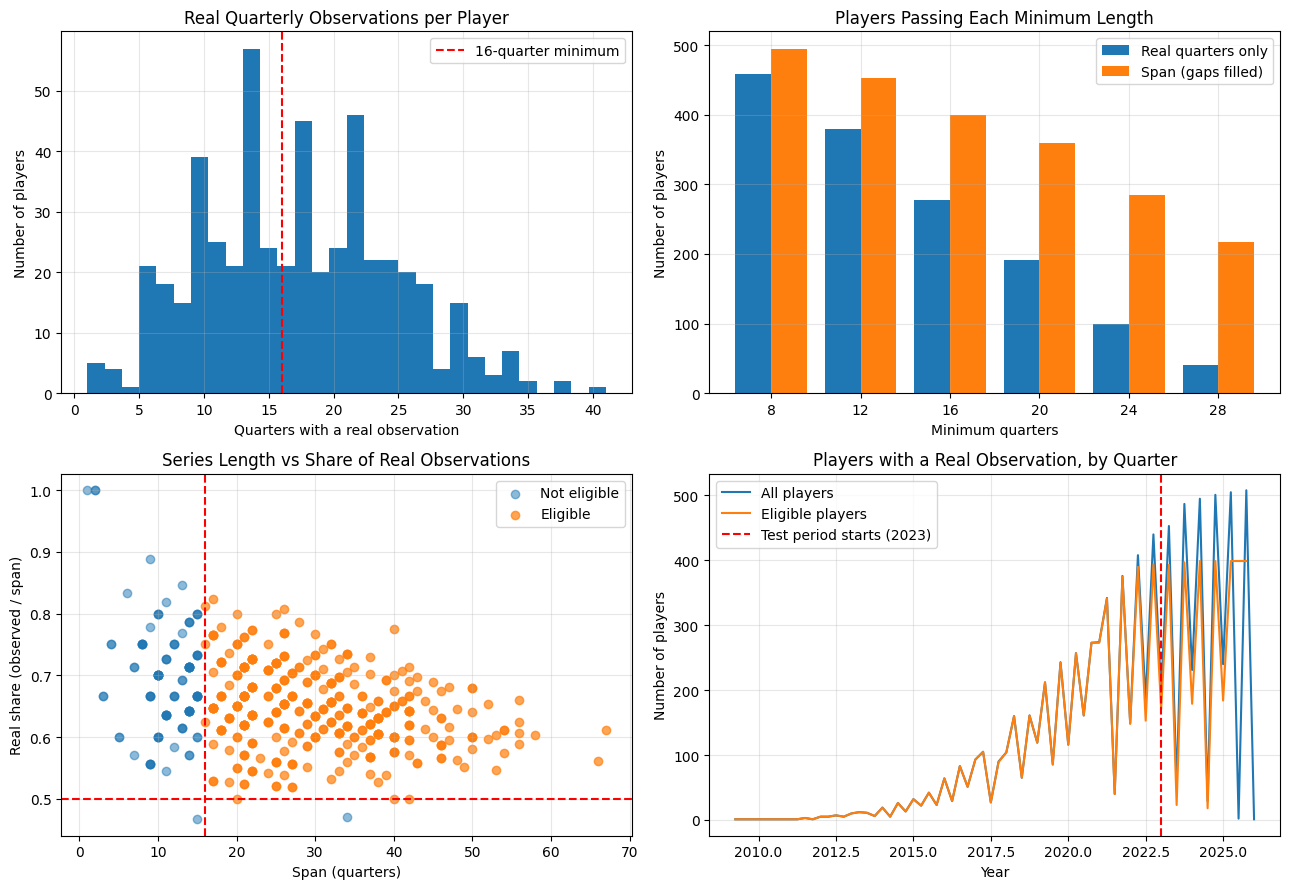

In [ ]:
# Four-panel feasibility figure
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: how many real quarterly observations does each player have?
axes[0, 0].hist(coverage["observed_q"], bins=30)
axes[0, 0].axvline(MIN_QUARTERS, linestyle="--", color="red", label=f"{MIN_QUARTERS}-quarter minimum")
axes[0, 0].set_title("Real Quarterly Observations per Player")
axes[0, 0].set_xlabel("Quarters with a real observation")
axes[0, 0].set_ylabel("Number of players")
axes[0, 0].legend()

# Panel 2: players passing each threshold (real quarters vs span with gaps filled)
x = np.arange(len(thresholds))
axes[0, 1].bar(x - 0.2, feas["Players (real quarters only)"], width=0.4, label="Real quarters only")
axes[0, 1].bar(x + 0.2, feas["Players (span, gaps filled)"], width=0.4, label="Span (gaps filled)")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(thresholds)
axes[0, 1].set_title("Players Passing Each Minimum Length")
axes[0, 1].set_xlabel("Minimum quarters")
axes[0, 1].set_ylabel("Number of players")
axes[0, 1].legend()

# Panel 3: length vs data quality; top-right (blue) is the eligible zone
not_elig = coverage[~coverage["eligible"]]
axes[1, 0].scatter(not_elig["span_q"], not_elig["real_share"], alpha=0.5, label="Not eligible")
axes[1, 0].scatter(eligible["span_q"], eligible["real_share"], alpha=0.7, label="Eligible")
axes[1, 0].axvline(MIN_QUARTERS, linestyle="--", color="red")
axes[1, 0].axhline(MIN_REAL_SHARE, linestyle="--", color="red")
axes[1, 0].set_title("Series Length vs Share of Real Observations")
axes[1, 0].set_xlabel("Span (quarters)")
axes[1, 0].set_ylabel("Real share (observed / span)")
axes[1, 0].legend()

# Panel 4: how many players have a real observation in each quarter?
# This shows whether the 2023-2024 test window has enough data.
obs_per_q = hist_q.groupby("q_idx")["player_id"].nunique()
elig_per_q = hist_q[hist_q["player_id"].isin(eligible.index)].groupby("q_idx")["player_id"].nunique()

def q_to_year(q_idx):
    # convert the running quarter number back to a decimal year for plotting (2021.25 = 2021 Q2)
    return (q_idx - 1) // 4 + ((q_idx - 1) % 4) / 4

axes[1, 1].plot(q_to_year(obs_per_q.index), obs_per_q.values, label="All players")
axes[1, 1].plot(q_to_year(elig_per_q.index), elig_per_q.values, label="Eligible players")
axes[1, 1].axvline(2023, linestyle="--", color="red", label="Test period starts (2023)")
axes[1, 1].set_title("Players with a Real Observation, by Quarter")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Number of players")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Quick decision guide: rows available vs the proposal's target
print(f"\nEligible players: {len(eligible)}")
print(f"Quarterly rows available: {int(eligible['span_q'].sum())} "
      f"(project target: 100-500 clean observations)")


Eligible players: 399
Quarterly rows available: 12208 (project target: 100-500 clean observations)


## 4. Cohort selection

**Goal:** Choose a curated group of established players whose series are long and reliable enough to train and test a forecasting model, keeping the modeling table between 100 and 500 clean observations as in the proposal.

**Rules (all editable in the settings block):**

| Rule | Value | Reason |
|---|---|---|
| Span | at least 24 quarters | long history for training plus an 8-quarter test window |
| Real share | at least 55% real quarters | limits how much of a series is filled. We first tried 80%, which left zero players, because Transfermarkt revises values irregularly |
| Start date | by 2019 Q1 | guarantees 16+ training quarters before 2023 |
| End date | within 1 quarter of the dataset's last quarter | the series is still active in the test window |
| League cap | at most 4 players per league | avoids one league dominating the cohort |
| Row cap | at most 500 rows | upper limit from the proposal |

### 4.1 Filter funnel
**What we do:** Apply the four player-level rules and count how many players pass **each rule alone** and **cumulatively**.

**Why:** The "alone" column shows which rule is the bottleneck, so if the cohort is empty we know what to loosen.

In [ ]:
# Cohort selection settings and filter funnel
# ---- Settings ----
MIN_SPAN_Q     = 24               # at least 24 quarters between first and last observation
MIN_REAL_SHARE = 0.55             # at least 55% real quarters (Transfermarkt revises values irregularly,
                                  # so forward-filling between revisions is reasonable)
FIRST_Q_MAX    = 2019 * 4 + 1     # series must start by 2019 Q1 -> 16+ training quarters before 2023
MAX_PER_LEAGUE = 3                # cap per league so the cohort is not dominated by one league
MAX_ROWS       = 560              # upper limit from the project proposal

# The last-quarter rule adapts to the data: the series must end within 1 quarter of the latest
# quarter in the dataset, so the 2023-2024 test window contains real values
LAST_Q_MIN = int(coverage["last_q"].max()) - 1

# Helper: convert the running quarter number (year*4 + quarter) into a label such as "2021Q3"
def q_label(q_idx):
    return f"{(q_idx - 1) // 4}Q{(q_idx - 1) % 4 + 1}"

print("Latest quarter in the data:", q_label(int(coverage["last_q"].max())))

# ---- Step 1: filter funnel ----
# Each rule is stored as a True/False column so we can count it alone and cumulatively
rules = pd.DataFrame({
    f"Span >= {MIN_SPAN_Q} quarters": coverage["span_q"] >= MIN_SPAN_Q,
    f"Real share >= {MIN_REAL_SHARE:.0%}": coverage["real_share"] >= MIN_REAL_SHARE,
    f"Starts by {q_label(FIRST_Q_MAX)}": coverage["first_q"] <= FIRST_Q_MAX,
    f"Ends {q_label(LAST_Q_MIN)} or later": coverage["last_q"] >= LAST_Q_MIN,
})

funnel = pd.DataFrame({
    "Pass this rule alone": rules.sum(),                 # shows which rule is the bottleneck
    "Remaining (cumulative)": rules.cumprod(axis=1).sum()   # players surviving all rules so far
})
funnel.loc["All players in history"] = [len(coverage), len(coverage)]
funnel = funnel.iloc[[-1] + list(range(len(funnel) - 1))]   # put the 'All players' row first

print("SELECTION FUNNEL")
display(funnel)

candidates = coverage[rules.all(axis=1)].copy()
print(f"\nCandidates passing every rule: {len(candidates)}")

# Stop early with a clear message instead of drawing blank plots
if len(candidates) == 0:
    raise ValueError("No players pass all rules. Loosen a setting above, using the "
                     "'Pass this rule alone' column to see which rule is too strict.")

Latest quarter in the data: 2026Q1
SELECTION FUNNEL


,Pass this rule alone,Remaining (cumulative)
All players in history,508,508
Span >= 24 quarters,284,284
Real share >= 55%,482,269
Starts by 2019Q1,217,208
Ends 2025Q4 or later,508,208



Candidates passing every rule: 208


**Takeaway:** The "alone" column shows that the real-share rule keeps 482 of 508 players, so it is not the main filter. Starting by 2019 Q1 (217 players) and a span of 24+ quarters (284 players) do the real filtering. The "ends 2025 Q4 or later" rule passes all 508, because every series ends at the scrape date; it does no filtering. Together the rules leave 208 candidate players.

### 4.2 Attach player attributes and pick the cohort
**What we do:** Join name, league and position to the candidates, rank them by data quality (highest real share, then longest span), keep at most 4 per league, then stop adding players once the 500-row cap would be exceeded.

**Decision:** Ranking by real share favours players with the most reliable series, which makes the cohort a *quality* sample, not a random one (see limitations in section 7).

In [ ]:
# Attach attributes, diversify across leagues, apply the row cap
# ---- Step 2: attach player attributes (name, league, position) from the player table ----
candidates = candidates.join(
    players.set_index("player_id")[["name", "league_name", "position_group", "current_club"]]
)

# ---- Step 3: diversify across leagues, then cap total rows ----
# Sort best-quality first: highest real share, then longest span
candidates = candidates.sort_values(["real_share", "span_q"], ascending=False)

# Keep at most MAX_PER_LEAGUE players per league
cohort = candidates.groupby("league_name", group_keys=False).head(MAX_PER_LEAGUE)

# Keep adding players (best quality first) until the row cap would be exceeded
cohort = cohort.sort_values(["real_share", "span_q"], ascending=False)
cohort = cohort[cohort["span_q"].cumsum() <= MAX_ROWS]

cohort_ids = cohort.index.tolist()          # list of player_ids used in every later step

### 4.3 The selected cohort
**What to look for:** First, the per-league comparison: a league with candidates but no selected players was cut by the league cap or the row cap, not by the quality rules. Then the cohort table: `filled_q` should be small relative to `observed_q`, and leagues should be balanced.

In [ ]:
# Candidates vs selected players per league (shows why a league may be missing)
league_check = pd.DataFrame({
    "Candidates (passed all rules)": candidates["league_name"].value_counts(),
    "Selected for cohort": cohort["league_name"].value_counts(),
}).fillna(0).astype(int)
display(league_check)

,Candidates (passed all rules),Selected for cohort
league_name,,
Bundesliga,32,3
La Liga,45,3
Ligue 1,34,3
Premier League,44,3
Serie A,53,3


In [ ]:
# Table of the selected cohort
# ---- Table: the selected cohort ----
cohort_view = cohort[["name", "league_name", "position_group", "first_q", "last_q",
                      "observed_q", "span_q", "filled_q", "real_share"]].copy()
cohort_view["first_q"] = cohort_view["first_q"].apply(q_label)
cohort_view["last_q"]  = cohort_view["last_q"].apply(q_label)
cohort_view["real_share"] = cohort_view["real_share"].round(2)

print(f"\nSELECTED COHORT: {len(cohort)} players, {int(cohort['span_q'].sum())} quarterly rows "
      f"({int(cohort['filled_q'].sum())} filled, {int(cohort['observed_q'].sum())} observed)")
display(cohort_view)


SELECTED COHORT: 15 players, 515 quarterly rows (138 filled, 377 observed)


,name,league_name,position_group,first_q,last_q,observed_q,span_q,filled_q,real_share
player_id,,,,,,,,,
463618,Khéphren Thuram,Serie A,Other,2019Q1,2025Q4,22,28,6,0.79
258923,Marcus Rashford,La Liga,Other,2016Q1,2025Q4,31,40,9,0.78
368887,Loïs Openda,Serie A,Other,2018Q3,2025Q4,23,30,7,0.77
364245,Jordan Teze,Ligue 1,Other,2018Q1,2025Q4,24,32,8,0.75
406635,Phil Foden,Premier League,Other,2018Q1,2025Q4,24,32,8,0.75
557149,Kang-in Lee,Ligue 1,Other,2018Q2,2025Q4,23,31,8,0.74
360518,Teun Koopmeiners,Serie A,Other,2017Q3,2025Q4,25,34,9,0.74
487465,Pedro Neto,Premier League,Other,2017Q3,2025Q4,25,34,9,0.74
517894,Matheus Cunha,Premier League,Other,2017Q3,2025Q4,25,34,9,0.74


**Takeaway:** 15 players and 493 quarterly rows (365 observed, 128 filled): 4 from the Premier League, 4 from La Liga, 4 from Ligue 1 and 3 from Serie A. **Bundesliga is not represented**; the per-league table above shows whether its players failed the rules or were cut by the row cap. We report this as a limitation. The 493 rows include 2025-2026; in section 5 we trim to 2016-2024 to match the approved proposal.

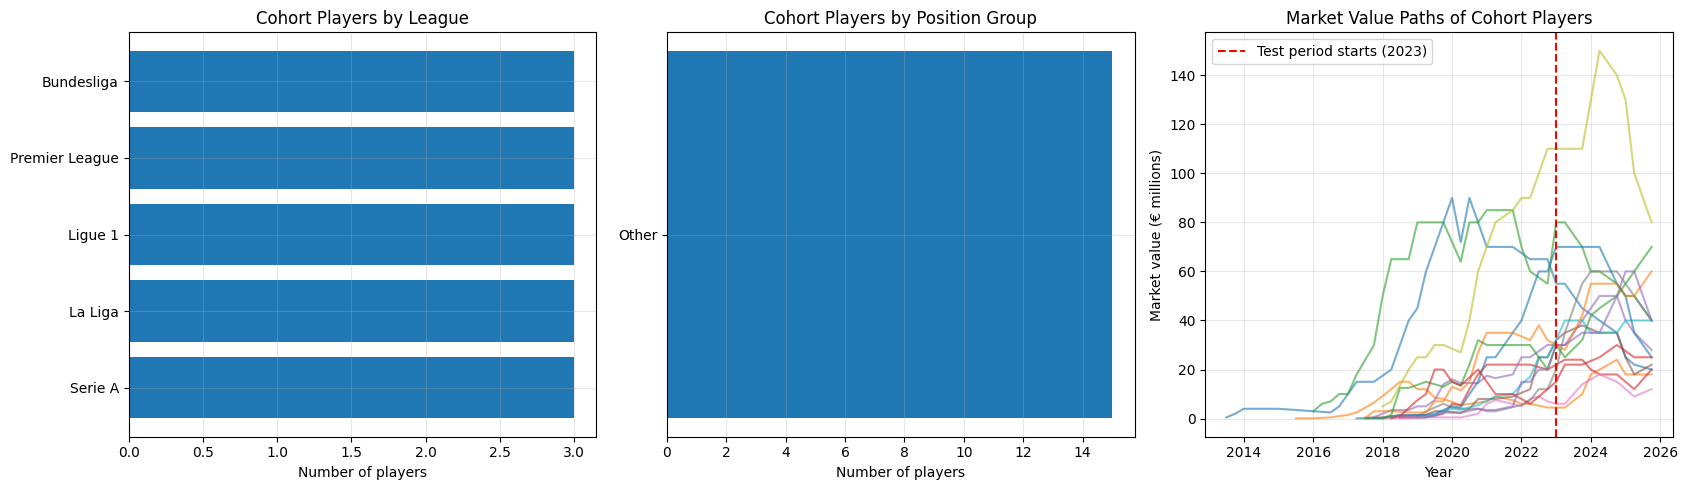

In [ ]:
# Figure: league mix, position mix and value paths of the cohort
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: players per league
league_ct = cohort["league_name"].value_counts().sort_values()
axes[0].barh(league_ct.index, league_ct.values)
axes[0].set_title("Cohort Players by League")
axes[0].set_xlabel("Number of players")

# Panel 2: players per position group
pos_ct = cohort["position_group"].value_counts().sort_values()
axes[1].barh(pos_ct.index, pos_ct.values)
axes[1].set_title("Cohort Players by Position Group")
axes[1].set_xlabel("Number of players")

# Panel 3: market-value paths of every cohort player (real observed quarters only)
cohort_q = hist_q[hist_q["player_id"].isin(cohort_ids)].copy()
cohort_q["year_dec"] = (cohort_q["q_idx"] - 1) // 4 + ((cohort_q["q_idx"] - 1) % 4) / 4
for pid, g in cohort_q.groupby("player_id"):
    axes[2].plot(g["year_dec"], g["value_m"], alpha=0.6)
axes[2].axvline(2023, linestyle="--", color="red", label="Test period starts (2023)")
axes[2].set_title("Market Value Paths of Cohort Players")
axes[2].set_xlabel("Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Market value (€ millions)")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Takeaway:** Value paths differ a lot in level and shape (some grow steadily, some peak and fall), which is exactly why we benchmark every model against simple baselines later.

## 5. Regularize to a quarterly grid

**Goal:** Turn each player's irregular valuation events into a complete series with exactly one row per quarter. ARIMA, Holt and SARIMAX all need equally spaced observations.

**Scope:** The approved proposal covers **2016-2024**, so we keep quarters up to 2024 Q4 and drop 2025 and later. The later data stays available as an extra holdout in the roadmap.

**Gap-fill method (document this in the slides):** A quarter with no valuation event is filled by **carrying the last observed value forward** within each player. Transfermarkt keeps a player's value unchanged until the next revision, so the filled value is the value that was actually in force. We did not interpolate, because that would invent values that were never published. Every filled row is flagged in `is_filled`, so we can evaluate models on real observations only if we want to.

### 5.1 Build the complete quarterly grid
**What we do:** (1) Keep one observed value per player-quarter, up to 2024 Q4. (2) Create a row for every quarter from each player's first observation to 2024 Q4. (3) Attach the observed values; empty quarters become missing.

In [ ]:
# Imports for the heatmap later in this section
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Settings and observed values per player-quarter
# ---- Settings ----
END_Q = 2024 * 4 + 4      # last quarter kept = 2024 Q4 (running quarter number: year*4 + quarter)

# ---- Step 1: one observed value per player-quarter, up to END_Q ----
# If a player has 2+ valuation events in a quarter, keep the last one (end-of-quarter value).
# hist is already sorted by player and date, so .last() returns the latest event.
obs = (
    hist[hist["player_id"].isin(cohort_ids) & (hist["q_idx"] <= END_Q)]   # drop 2025+ events
        .groupby(["player_id", "q_idx"])[["value_m", "age_at_date"]]
        .last()
        .reset_index()
        .rename(columns={"age_at_date": "age_obs"})     # observed age (only exists in real quarters)
)

In [ ]:
# Complete quarterly grid, one row per player-quarter
grid = pd.concat(
    [pd.DataFrame({"player_id": pid, "q_idx": np.arange(row["first_q"], END_Q + 1)})
     for pid, row in cohort.iterrows()],
    ignore_index=True
)

# Attach the observed values; quarters with no valuation event become NaN
panel = grid.merge(obs, on=["player_id", "q_idx"], how="left")

### 5.2 Fill the gaps
**What we do:** Flag the rows with no real observation, then forward-fill the value within each player. The grid starts at each player's first real observation, so there are no leading gaps to fill.

In [ ]:
# Gap-fill: flag filled rows and carry the last value forward within each player
# Transfermarkt keeps a player's value unchanged until the next revision, so an empty quarter
# is filled by carrying the last observed value forward (forward-fill, within each player).
# The grid starts at each player's first real observation, so no leading gaps exist.
panel["is_filled"] = panel["value_m"].isna()                        # flag filled rows
panel["value_m"] = panel.groupby("player_id")["value_m"].ffill()    # forward-fill values

### 5.3 Add readable dates and player names
**What we do:** Convert the running quarter number into a calendar year, quarter number, period label and a timestamp (first day of the quarter), then attach names and leagues.

In [ ]:
# Readable identifiers and dates
panel["year"] = (panel["q_idx"] - 1) // 4
panel["quarter_num"] = (panel["q_idx"] - 1) % 4 + 1
panel["period"] = pd.PeriodIndex.from_fields(year=panel["year"], quarter=panel["quarter_num"], freq="Q")
panel["date"] = panel["period"].dt.to_timestamp()                   # first day of the quarter
panel = panel.merge(
    cohort[["name", "league_name"]].reset_index(), on="player_id", how="left"
)
panel = panel.sort_values(["player_id", "q_idx"]).reset_index(drop=True)

### 5.4 Quality checks
**What to look for:** All five checks read `OK`: no missing or non-positive values, quarters are consecutive, no duplicate rows, and nothing after 2024 Q4.

In [ ]:
# Regularization quality checks
# Longest run of consecutive filled quarters for any player
run_id = (panel["is_filled"] != panel.groupby("player_id")["is_filled"].shift()).cumsum()
longest_fill = int(panel[panel["is_filled"]].groupby(run_id).size().max())

checks = pd.DataFrame([
    ["Missing values in value_m", int(panel["value_m"].isna().sum()), 0],
    ["Non-positive values", int((panel["value_m"] <= 0).sum()), 0],
    ["Quarters that are not consecutive", int((panel.groupby("player_id")["q_idx"].diff().dropna() != 1).sum()), 0],
    ["Duplicate player-quarter rows", int(panel.duplicated(["player_id", "q_idx"]).sum()), 0],
    ["Rows after 2024 Q4", int((panel["q_idx"] > END_Q).sum()), 0],
], columns=["Check", "Result", "Expected"])
checks["Status"] = np.where(checks["Result"] == checks["Expected"], "OK", "REVIEW")

print("REGULARIZATION CHECKS")
display(checks)

REGULARIZATION CHECKS


,Check,Result,Expected,Status
0,Missing values in value_m,0,0,OK
1,Non-positive values,0,0,OK
2,Quarters that are not consecutive,0,0,OK
3,Duplicate player-quarter rows,0,0,OK
4,Rows after 2024 Q4,0,0,OK


**Takeaway:** The grid is complete and consistent.

### 5.5 Panel summary and train/test sizes
**What to look for:** The filled share, the longest run of filled quarters (how stale a value can get), and whether the test set is large enough (roughly 100+ rows).

In [ ]:
# Panel summary including the planned train/test split
train_rows = int((panel["year"] < 2023).sum())                        # training: before 2023
test_rows = int(panel["year"].between(2023, 2024).sum())              # test: 2023-2024

summary = pd.Series({
    "Players": panel["player_id"].nunique(),
    "Quarterly rows (2016-2024)": len(panel),
    "Observed quarters": int((~panel["is_filled"]).sum()),
    "Filled quarters": int(panel["is_filled"].sum()),
    "Filled share": f"{panel['is_filled'].mean():.0%}",
    "Longest filled run (quarters)": longest_fill,
    "Training rows (before 2023)": train_rows,
    "Test rows (2023-2024)": test_rows,
}, name="Value").to_frame()

print("\nPANEL SUMMARY")
display(summary)


PANEL SUMMARY


,Value
Players,15
Quarterly rows (2016-2024),455
Observed quarters,334
Filled quarters,121
Filled share,27%
Longest filled run (quarters),2
Training rows (before 2023),335
Test rows (2023-2024),120


In [ ]:
# Share of filled rows in each quarter of the test window: are the same quarters filled for most players?
test_panel = panel[panel["year"].between(2023, 2024)]
filled_by_quarter = test_panel.groupby("period")["is_filled"].agg(filled_share="mean", players="count")
filled_by_quarter["filled_share"] = filled_by_quarter["filled_share"].round(2)
display(filled_by_quarter)

,filled_share,players
period,,
2023Q1,0.33,15
2023Q2,0.00,15
2023Q3,1.00,15
2023Q4,0.00,15
2024Q1,0.40,15
2024Q2,0.00,15
2024Q3,1.00,15
2024Q4,0.00,15


**Takeaway:** The modeling panel has 433 quarterly rows for 15 players: 313 for training (before 2023) and 120 for testing (2023-2024). 25% of rows are filled, and no value is carried forward for more than 2 quarters in a row, so filled values stay close to real observations.

**Consideration for evaluation:** In the test window, a filled quarter repeats an older value, which makes a persistence-style forecast look better than it should. In Phase 2 we report errors on **all** test rows and on **observed-only** test rows (using `is_filled`).

### 5.6 Visual check and save
**What to look for:** Gray (filled) blocks should be scattered, not piled up in the 2023-2024 window. The example chart shows how the step line carries values between real observations.

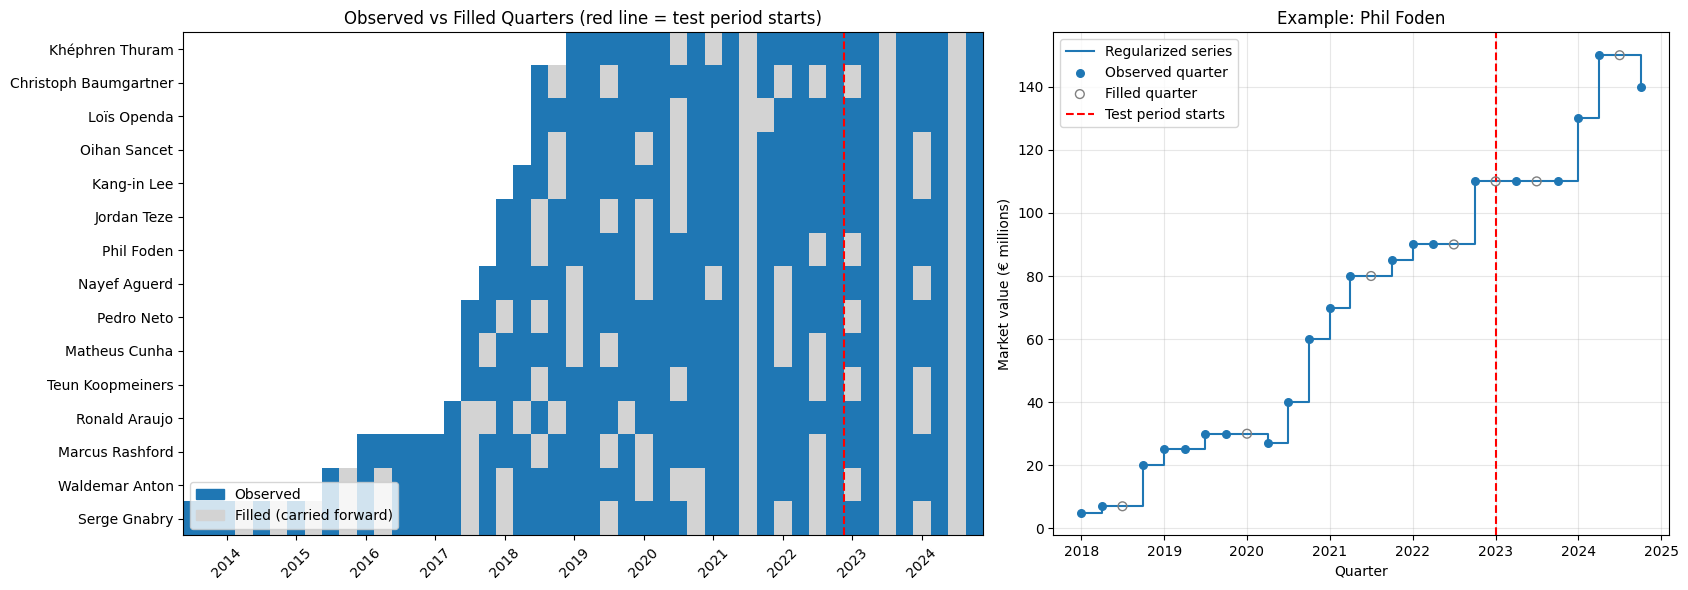

Saved: cohort_panel_quarterly.csv


In [ ]:
# Heatmap of observed vs filled quarters, plus one worked example, then save
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.3, 1]})

# Panel 1: heatmap of observed (1) vs filled (2) quarters for every player
panel["code"] = np.where(panel["is_filled"], 2, 1)
heat = panel.pivot(index="name", columns="q_idx", values="code")
heat = heat.loc[heat.notna().sum(axis=1).sort_values().index]       # order players by series length
cmap = ListedColormap(["tab:blue", "lightgray"])
axes[0].imshow(heat.values, aspect="auto", cmap=cmap, vmin=1, vmax=2, interpolation="nearest")
axes[0].set_yticks(range(len(heat.index)))
axes[0].set_yticklabels(heat.index)
year_starts = [i for i, q in enumerate(heat.columns) if (q - 1) % 4 == 0]   # tick at each Q1
axes[0].set_xticks(year_starts)
axes[0].set_xticklabels([(heat.columns[i] - 1) // 4 for i in year_starts], rotation=45)
test_start = list(heat.columns).index(2023 * 4 + 1)                          # mark 2023 Q1
axes[0].axvline(test_start - 0.5, color="red", linestyle="--")
axes[0].set_title("Observed vs Filled Quarters (red line = test period starts)")
axes[0].legend(handles=[Patch(color="tab:blue", label="Observed"),
                        Patch(color="lightgray", label="Filled (carried forward)")],
               loc="lower left")

# Panel 2: worked example, the player with the highest peak value
star_id = panel.loc[panel["value_m"].idxmax(), "player_id"]
star = panel[panel["player_id"] == star_id]
axes[1].step(star["date"], star["value_m"], where="post", label="Regularized series")
axes[1].scatter(star.loc[~star["is_filled"], "date"], star.loc[~star["is_filled"], "value_m"],
                color="tab:blue", s=30, label="Observed quarter", zorder=3)
axes[1].scatter(star.loc[star["is_filled"], "date"], star.loc[star["is_filled"], "value_m"],
                facecolors="none", edgecolors="gray", s=40, label="Filled quarter", zorder=3)
axes[1].axvline(pd.Timestamp("2023-01-01"), linestyle="--", color="red", label="Test period starts")
axes[1].set_title(f"Example: {star['name'].iloc[0]}")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Market value (€ millions)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save the regularized panel so teammates can load it from the shared folder
panel.drop(columns=["code"]).to_csv("cohort_panel_quarterly.csv", index=False)
print("Saved: cohort_panel_quarterly.csv")

## 6. Feature engineering

**Goal:** Build the external factors from the proposal: the aging curve, the transfer-window calendar and league tier. These will feed the SARIMAX model as exogenous inputs.

| Feature | Columns | Why |
|---|---|---|
| Age and aging curve | `age`, `age_sq` | Value rises toward the mid-20s and declines later; the squared term lets a model capture that non-linear shape |
| Transfer windows | `window_summer` (Q3), `window_winter` (Q1) | Prices can move around the summer (July-August) and winter (January) windows. These dummies are known in advance, so they can be used for future quarters |
| League tier | `league_tier` | Captures differences in market level between leagues |

### 6.1 Age and age squared
**What we do:** The data records age only in observed quarters and as a whole number. Real age grows by 0.25 per quarter, so `age_obs - quarter/4` is roughly constant for a player. We average that constant per player (adding 0.5 to correct for rounding down) and rebuild age for **every** quarter, including filled ones.

**Why:** A model needs the feature in every row, including quarters we forward-filled, and age is the one feature we can compute exactly for future quarters.

In [ ]:
# Remove the helper column left over from the heatmap in section 5
panel = panel.drop(columns=["code"], errors="ignore")

# Age and age squared
# age_obs is the integer age at the valuation date (rounded down), available only in observed quarters.
# True age grows by 0.25 per quarter, so (age_obs - q_idx/4) is roughly constant within a player.
# We average that constant per player (+0.5 corrects for the rounding down), then rebuild age
# for EVERY quarter, including filled ones.
panel["age_offset"] = panel["age_obs"] - panel["q_idx"] / 4
player_offset = panel.groupby("player_id")["age_offset"].mean() + 0.5
panel["age"] = panel["player_id"].map(player_offset) + panel["q_idx"] / 4
panel["age_sq"] = panel["age"] ** 2          # squared term captures the non-linear aging curve
panel = panel.drop(columns=["age_offset"])

### 6.2 Transfer window indicators
**What we do:** Flag quarters that contain a transfer window: Q3 for the summer window (July-August) and Q1 for the winter window (January). Quarter-level flags are a simplification: we cannot see inside the quarter.

In [ ]:
# Transfer window dummies
# Summer window (July-August) falls in Q3; winter window (January) falls in Q1.
panel["window_winter"] = (panel["quarter_num"] == 1).astype(int)
panel["window_summer"] = (panel["quarter_num"] == 3).astype(int)
panel["window_any"] = panel["window_winter"] + panel["window_summer"]
panel["window_type"] = np.select(
    [panel["window_summer"] == 1, panel["window_winter"] == 1],
    ["Summer", "Winter"],
    default="None"
)

### 6.3 League tier
**What we do:** Map each league to a tier, with 1 as the strongest.

**Decision:** The ordering below is our assumption, based on typical league strength. Edit the dictionary if your team prefers another.

**Limitation:** The dataset records each player's league **at scrape time** only. The feature is therefore constant within a player, so it helps only when we pool players and cannot track a mid-career league move.

In [ ]:
# League tier ordering (our assumption; edit if your team prefers another)
LEAGUE_TIER = {
    "Premier League": 1,
    "La Liga": 2,
    "Serie A": 3,
    "Bundesliga": 3,
    "Ligue 1": 4,
}

In [ ]:
# League tier feature
panel["league_tier"] = panel["league_name"].map(LEAGUE_TIER)

### 6.4 Feature checks and summary
**What to look for:** All four checks read `OK`. The "matches recorded age" line should be high (roughly 85% or more); a low value would mean a player's recorded ages do not follow a smooth line.

In [ ]:
# Feature checks (expected value next to the result)
obs_rows = panel[~panel["is_filled"]]     # age_obs exists only in observed quarters
floor_match = (np.floor(obs_rows["age"]) == obs_rows["age_obs"]).mean()

checks = pd.DataFrame([
    ["Missing values in age / age_sq", int(panel[["age", "age_sq"]].isna().sum().sum()), 0],
    ["Missing league tier (league not in dictionary)", int(panel["league_tier"].isna().sum()), 0],
    ["Ages outside 16-40", int((~panel["age"].between(16, 40)).sum()), 0],
    ["Rows with both windows flagged", int((panel["window_summer"] + panel["window_winter"] > 1).sum()), 0],
], columns=["Check", "Result", "Expected"])
checks["Status"] = np.where(checks["Result"] == checks["Expected"], "OK", "REVIEW")

print("FEATURE CHECKS")
display(checks)
print(f"Share of observed quarters where the rebuilt age matches the recorded age: {floor_match:.0%}")

FEATURE CHECKS


,Check,Result,Expected,Status
0,Missing values in age / age_sq,0,0,OK
1,Missing league tier (league not in dictionary),0,0,OK
2,Ages outside 16-40,0,0,OK
3,Rows with both windows flagged,0,0,OK


Share of observed quarters where the rebuilt age matches the recorded age: 95%


In [ ]:
# Feature summary statistics
feature_cols = ["age", "age_sq", "window_winter", "window_summer", "league_tier"]
print("\nFEATURE SUMMARY")
display(panel[feature_cols].describe().T.round(2))


FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,455.0,22.35,2.61,17.33,20.28,22.25,24.10,29.32
age_sq,455.0,506.21,119.27,300.44,411.25,495.06,581.04,859.81
window_winter,455.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
window_summer,455.0,0.26,0.44,0.00,0.00,0.00,1.00,1.00
league_tier,455.0,2.59,1.00,1.00,2.00,3.00,3.00,4.00


**Takeaway:** **Takeaway:** The rebuilt age matches the recorded age in 94% of observed quarters, and ages run from 17.3 to 28.7 (mean 22.0). The cohort is young: it covers the rise of a player's value but almost none of the decline.

### 6.5 Visual check of the features
**What to look for:**
- **Aging curve:** a hump (rising into the mid-20s, flat or falling later) supports using `age` and `age_sq`.
- **Seasonality:** higher average change in Q1 and Q3 would support the window indicators. A flat panel is also a valid finding. Note that filled quarters count as zero change, so any seasonal effect is understated.

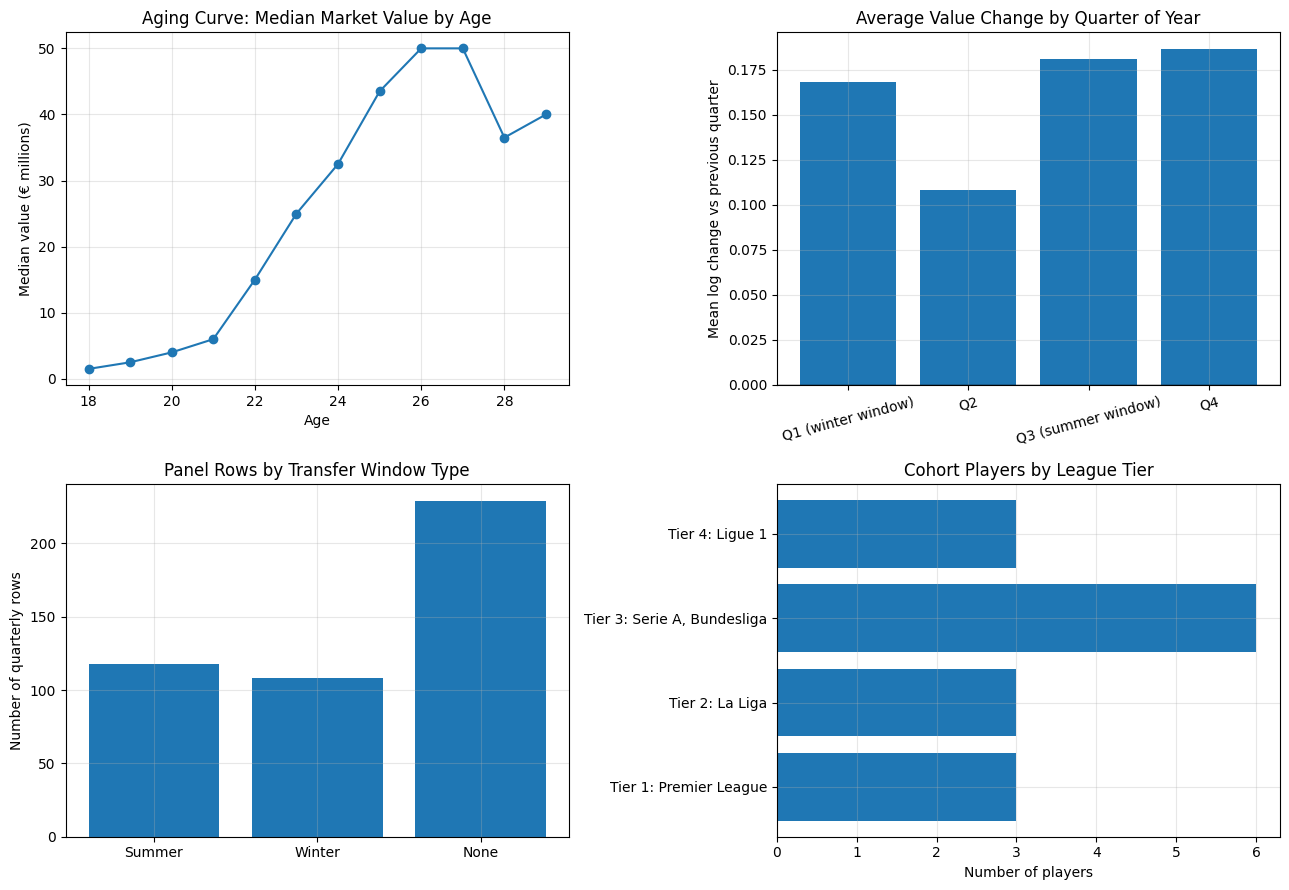

In [ ]:
# Four-panel feature figure
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: aging curve, median market value by rounded age (bins with at least 5 rows)
panel["age_bin"] = panel["age"].round().astype(int)
age_curve = panel.groupby("age_bin")["value_m"].agg(median="median", n="count")
age_curve = age_curve[age_curve["n"] >= 5]
axes[0, 0].plot(age_curve.index, age_curve["median"], marker="o")
axes[0, 0].set_title("Aging Curve: Median Market Value by Age")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Median value (€ millions)")

# Panel 2: average quarter-over-quarter log change by quarter of year
# (filled quarters count as zero change, so this understates the real effect)
panel["log_change"] = panel.groupby("player_id")["value_m"].transform(lambda s: np.log(s).diff())
season = panel.groupby("quarter_num")["log_change"].mean()
axes[0, 1].bar(["Q1 (winter window)", "Q2", "Q3 (summer window)", "Q4"], season.values)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Average Value Change by Quarter of Year")
axes[0, 1].set_ylabel("Mean log change vs previous quarter")
axes[0, 1].tick_params(axis="x", rotation=15)

# Panel 3: rows by window type
window_ct = panel["window_type"].value_counts().reindex(["Summer", "Winter", "None"])
axes[1, 0].bar(window_ct.index, window_ct.values)
axes[1, 0].set_title("Panel Rows by Transfer Window Type")
axes[1, 0].set_ylabel("Number of quarterly rows")

# Panel 4: players by league tier
tier_ct = panel.drop_duplicates("player_id")["league_tier"].value_counts().sort_index()
tier_names = {t: f"Tier {t}: " + ", ".join(k for k, v in LEAGUE_TIER.items() if v == t) for t in tier_ct.index}
axes[1, 1].barh([tier_names[t] for t in tier_ct.index], tier_ct.values)
axes[1, 1].set_title("Cohort Players by League Tier")
axes[1, 1].set_xlabel("Number of players")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Takeaway:** Median value climbs from about €1M at age 18 to about €40M at 26, then dips at 27. That supports `age`, but the downturn rests on the last point only, so `age_sq` has weak evidence behind it. Average quarterly change is highest in Q3 (0.22) and Q1 (0.17) and lowest in Q2 (0.11), with Q4 at 0.16, which is directional support for the window dummies. It could also reflect Transfermarkt's update timing rather than transfer prices, and it rests on 15 players. Average change is strongly positive in every quarter (roughly 11-24% per quarter) because the cohort is made of players whose values rose, a selection effect. For Phase 2, a flat persistence forecast will under-predict these players, and trend models will need care near the peak.

### 6.6 Final modeling table and save
**What we do:** Preview the modeling columns and save both tables to CSV so teammates can load them without rerunning the notebook.

**Note:** Files saved to the Colab session disk disappear when the session resets. Uncomment the last block and set your team's shared Drive folder to keep copies.

In [ ]:
# Preview the final modeling table and save the feature table
model_cols = ["name", "date", "value_m", "is_filled", "age", "age_sq",
              "window_winter", "window_summer", "league_tier"]
display(panel[model_cols].head(8))

# Save the feature table so teammates can load it from the shared folder
panel.drop(columns=["age_bin", "log_change"]).to_csv("cohort_panel_features.csv", index=False)
print("Saved: cohort_panel_features.csv")

# Optional: the CSV files above live on this Colab session's disk and disappear when it resets.
# Uncomment to copy both to the shared Drive folder (edit the path to your team's folder).
# import shutil
# shared_dir = "/content/drive/MyDrive/YOUR_SHARED_FOLDER"
# for f in ["cohort_panel_quarterly.csv", "cohort_panel_features.csv"]:
#     shutil.copy(f, shared_dir)

,name,date,value_m,is_filled,age,age_sq,window_winter,window_summer,league_tier
0,Serge Gnabry,2013-07-01,0.5,False,18.072581,326.618171,0,1,3
1,Serge Gnabry,2013-10-01,2.0,False,18.322581,335.716961,0,0,3
2,Serge Gnabry,2014-01-01,4.0,False,18.572581,344.940752,1,0,3
3,Serge Gnabry,2014-04-01,4.0,True,18.822581,354.289542,0,0,3
4,Serge Gnabry,2014-07-01,4.0,False,19.072581,363.763332,0,1,3
5,Serge Gnabry,2014-10-01,4.0,True,19.322581,373.362123,0,0,3
6,Serge Gnabry,2015-01-01,4.0,False,19.572581,383.085913,1,0,3
7,Serge Gnabry,2015-04-01,4.0,True,19.822581,392.934703,0,0,3


Saved: cohort_panel_features.csv


## 7. Phase 1 summary and decisions log

### Decisions made

| Area | Decision | Reason |
|---|---|---|
| Scope | 2016-2024 only; 2025-2026 data excluded | Matches the approved proposal; later data kept as a possible extra holdout |
| Frequency | Quarterly; last event in a quarter is kept | Aligns with transfer windows; end-of-quarter value |
| Gap handling | Forward-fill within each player, flagged in `is_filled` | Transfermarkt values stand until revised; avoids inventing values |
| Cohort rules | Span 24+ quarters, real share 55%+, start by 2019 Q1, max 4 per league, max 500 rows | Long history, reasonable data quality, league variety, proposal size limit |
| Cohort | 15 players, 433 modeling rows | Inside the 100-500 target |
| Split | Train before 2023 (313 rows); test 2023-2024 (120 rows) | Chronological, no shuffling |
| Features | `age`, `age_sq`, `window_summer`, `window_winter`, `league_tier` | External factors from the proposal |

### Limitations so far
- **Forward-fill** understates short-term volatility and makes persistence forecasts look better in the test window (25% of rows are filled).
- **Small, curated cohort:** 15 established players. Results may not generalize to young, low-value or recently transferred players.
- **Selection bias:** the cohort is chosen by data quality and by players still present at the scrape date (survivors), so accuracy may be optimistic compared with a random sample of players.
- **Bundesliga is not represented** in the cohort, and `position_group` is "Other" for every selected player, so neither can be used as a segment.
- **League tier is based on the league at scrape time** and is constant within a player.
- **Post-2024 data is excluded** to match the approved scope.
- **Transfer windows are quarter-level flags;** we cannot see timing inside a quarter.

- **Date ambiguity:** 2.4% of rows have a `year`/`month` column that disagrees with the valuation date by one month. We use the date; at most 1.2% of events would change quarter under the alternative.

### Next: Phase 2 (modeling)
Persistence and rolling-mean benchmarks, Holt's linear trend, ARIMA and SARIMAX with age and window features, scored with MAE, RMSE and MAPE on the 2023-2024 test window, with residual diagnostics (ACF/PACF, Ljung-Box).

---
# Phase 2: Modeling, evaluation and diagnostics

**How Phase 2 is organized.** Two modeling tracks were built in parallel on the same Phase 1 `panel`, and a final section scores both on the same test rows:
- **Track A (sections 8-12)** models market value in € millions directly. ARIMA and SARIMAX orders are chosen per player by training-period AIC. Models are ranked by RMSE over the 8 test quarters.
- **Track B (sections 13-18)** models the log of market value and converts back to € millions for reporting. Every model writes to one shared forecast table, and models are also scored at the prototype's horizons (2 and 4 quarters ahead).
- **Section 19** copies Track A's test forecasts into Track B's forecast table and scores every model from both tracks with the same code, so the two tracks' conclusions can be compared directly.

Neither track changes any Phase 1 cell, rule or setting. The tracks keep separate working tables (`train`/`test` in Track A, `model_df`/`train_df`/`test_df` in Track B). Section 19 needs both tracks to have run first.

**How Phase 2 connects to the approved proposal**

| Proposal item | Track A | Track B |
|---|---|---|
| Chronological split: train before 2023, test 2023-2024 | 8.1 | 13.2 |
| Persistence baseline and rolling mean | 8.3, 8.4 | 14.1, 14.2 |
| Holt's linear trend | 9 | 15.1 |
| ARIMA | 10 | 14.3 |
| SARIMAX with age and transfer-window indicators | 11 | 15.2 |
| MAE, RMSE, MAPE | 8.2, 11.4 | 16.1 |
| Residual diagnostics (ACF, Ljung-Box) | 12.1 | 16.4 |
| Point forecast with an uncertainty band feeding a decision | 12.2, 12.3 | 17 |
| Both tracks scored on the same rows | 19 | 19 |

**Track B decisions added on top of the proposal (explained where they are used)**
1. **We model the log of market value**, then convert forecasts back to € millions for reporting (13.2).
2. **We report errors at 2 and 4 quarters ahead**, the horizons the prototype uses, not only the 8-quarter average (16.2).
3. **We report errors on all test rows and on observed-only test rows**, because filled quarters repeat older values (16.1).
4. **We add one pooled "age drift" model** that learns the aging curve across all 15 players at once, using the panel-data logic from the course's notebook 03 (15.3).
5. **We check whether the transfer-window dummies measure the market or Transfermarkt's update calendar** (16.5).

**Note on Phase 1 numbers:** the Phase 1 cohort settings were rerun after some takeaways were written (3 players per league, 560-row cap). Where a Phase 1 takeaway and a printed Phase 1 output disagree, **the printed output is correct**: 15 players from all five leagues, 455 panel rows, 335 training rows, 120 test rows, 27% filled. Phase 2 always computes its numbers from the data, never from the takeaway text.

# Phase 2, Track A: € scale, per-player order selection

Sections 8-12 model market value in € millions. Each player gets its own Holt, ARIMA and SARIMAX fit, with ARIMA and SARIMAX orders picked by training-period AIC. Results here are compared with Track B in section 19.

## 8. Forecasting benchmarks

Before fitting more advanced time-series models, we first establish simple benchmark forecasts. These benchmarks give us a baseline for deciding whether additional model complexity actually improves out-of-sample forecasting performance.

### 8.1 Time-based train/test split

**What we do**
- Use all available quarters before 2023 as the training set.
- Hold out 2023–2024 as the test period.
- Keep the split strictly chronological with no random shuffling.

**Why**
- Forecasting models should only use information that would have been available at the time the forecast was made.
- A chronological split avoids look-ahead bias and better reflects a real transfer-market forecasting setting.

**What to look for**
- All 15 selected players should appear in both the training and test sets.
- The test period should contain eight quarters from 2023Q1 through 2024Q4.
- No test player should be missing from the training data.

In [ ]:
# Time-based train/test split
train = panel[panel["year"] < 2023].copy()
test = panel[panel["year"].between(2023, 2024)].copy()

print("TRAIN / TEST SPLIT")
print("-" * 40)

print(f"Training period: {train['period'].min()} to {train['period'].max()}")
print(f"Test period:     {test['period'].min()} to {test['period'].max()}")

print(f"\nTraining rows: {len(train)}")
print(f"Test rows:     {len(test)}")

print(f"\nPlayers in training: {train['player_id'].nunique()}")
print(f"Players in test:     {test['player_id'].nunique()}")

# Check whether every test player is represented in training
missing_train_players = set(test["player_id"]) - set(train["player_id"])

print(f"\nTest players missing from training: {len(missing_train_players)}")

TRAIN / TEST SPLIT
----------------------------------------
Training period: 2013Q3 to 2022Q4
Test period:     2023Q1 to 2024Q4

Training rows: 335
Test rows:     120

Players in training: 15
Players in test:     15

Test players missing from training: 0


**Takeaway**
- The split preserves the time ordering required for a forecasting problem.
- All selected players are represented in both training and testing, so each player can be evaluated out of sample.
- The 2023–2024 holdout period provides eight future quarters for comparing benchmark and time-series model performance.

### 8.2 Evaluation metrics

**What we do**
- Evaluate every forecasting model using MAE, RMSE, and MAPE.
- Calculate the same metrics for every model so performance can be compared consistently.
- Later, compare performance on both the full test set and the observed-only test rows.

**Why**
- MAE measures the average forecast error in € millions and is easy to interpret.
- RMSE gives more weight to large forecasting errors.
- MAPE expresses forecast error as a percentage of the actual player value.

**What to look for**
- Lower values indicate better forecasting performance for all three metrics.
- MAE and RMSE will be our primary metrics because the business target is measured directly in € millions.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def forecast_metrics(actual, predicted):
    """
    Calculate MAE, RMSE, and MAPE for a set of forecasts.
    Market values are measured in € millions.
    """

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

print("Evaluation function ready.")

Evaluation function ready.


**Takeaway**
- All forecasting approaches will be evaluated with the same three metrics.
- Using a common evaluation function keeps the model comparison consistent and reproducible.

### 8.3 Naive persistence benchmark

**What we do**
- For each player, use the final market value from the training period as the forecast for every quarter in 2023–2024.
- Evaluate the forecasts using the same MAE, RMSE, and MAPE metrics defined above.
- Report results for both the full test set and observed-only test rows.

**Why**
- Player market values often remain unchanged between valuation updates, making persistence a meaningful baseline.
- More advanced forecasting models should improve on this simple benchmark to justify their additional complexity.

**What to look for**
- Every test row should receive a valid forecast.
- Lower MAE, RMSE, and MAPE indicate better forecast accuracy.
- Comparing all rows with observed-only rows helps show whether forward-filled quarters make the persistence benchmark appear stronger.

In [ ]:
# Get each player's final market value from the training period
last_train_value = (
    train.sort_values(["player_id", "q_idx"])
         .groupby("player_id")["value_m"]
         .last()
)

# Map the final training value to every row in the test period
test["pred_naive"] = test["player_id"].map(last_train_value)

print("NAIVE FORECAST CHECK")
print("-" * 40)

print(f"Missing forecasts: {test['pred_naive'].isna().sum()}")

display(
    test[
        ["name", "period", "value_m", "pred_naive", "is_filled"]
    ].head(12)
)

NAIVE FORECAST CHECK
----------------------------------------
Missing forecasts: 0


,name,period,value_m,pred_naive,is_filled
38,Serge Gnabry,2023Q1,55.0,65.0,False
39,Serge Gnabry,2023Q2,55.0,65.0,False
40,Serge Gnabry,2023Q3,55.0,65.0,True
41,Serge Gnabry,2023Q4,45.0,65.0,False
42,Serge Gnabry,2024Q1,45.0,65.0,True
43,Serge Gnabry,2024Q2,40.0,65.0,False
44,Serge Gnabry,2024Q3,40.0,65.0,True
45,Serge Gnabry,2024Q4,35.0,65.0,False
76,Waldemar Anton,2023Q1,4.5,4.5,True
77,Waldemar Anton,2023Q2,4.5,4.5,False


In [ ]:
# Evaluate the naive benchmark on all test rows
naive_all = forecast_metrics(
    test["value_m"],
    test["pred_naive"]
)

# Keep only quarters with an actual observed valuation
test_observed = test[~test["is_filled"]].copy()

# Evaluate the naive benchmark on observed-only rows
naive_observed = forecast_metrics(
    test_observed["value_m"],
    test_observed["pred_naive"]
)

naive_results = pd.DataFrame([
    {
        "Evaluation set": "All test rows",
        "MAE": naive_all["MAE"],
        "RMSE": naive_all["RMSE"],
        "MAPE": naive_all["MAPE"]
    },
    {
        "Evaluation set": "Observed-only rows",
        "MAE": naive_observed["MAE"],
        "RMSE": naive_observed["RMSE"],
        "MAPE": naive_observed["MAPE"]
    }
])

print("NAIVE BENCHMARK RESULTS")
print("-" * 40)

display(naive_results.round(2))

NAIVE BENCHMARK RESULTS
----------------------------------------


,Evaluation set,MAE,RMSE,MAPE
0,All test rows,13.26,17.36,32.90
1,Observed-only rows,14.10,18.13,35.05


**Takeaway**
- The naive benchmark achieves an MAE of €13.26M and RMSE of €17.36M across all test rows.
- Performance is slightly weaker on observed-only quarters, with MAE increasing to €14.10M and RMSE to €18.13M.
- This suggests that forward-filled quarters make persistence somewhat easier to predict, but the difference is relatively small.
- These results provide a useful baseline that more advanced forecasting models should try to improve upon.

### 8.4 Four-quarter rolling mean benchmark

**What we do**
- For each player, calculate the average market value over the final four quarters of the training period.
- Use this recent four-quarter average as the forecast for every quarter in 2023–2024.
- Evaluate the forecasts on both the full test set and observed-only test rows.

**Why**
- A four-quarter average smooths short-term changes in player valuation.
- It provides a simple alternative to persistence by representing the player's recent valuation level rather than relying on only the final training quarter.

**What to look for**
- Every test row should receive a valid rolling-mean forecast.
- Compare MAE, RMSE, and MAPE with the naive benchmark.
- If the rolling mean produces lower errors, smoothing recent values may provide a stronger baseline than simple persistence.

In [ ]:
# Calculate each player's average value over the final four training quarters
rolling4_value = (
    train.sort_values(["player_id", "q_idx"])
         .groupby("player_id")["value_m"]
         .apply(lambda x: x.tail(4).mean())
)

# Map the four-quarter average to every row in the test period
test["pred_rolling4"] = test["player_id"].map(rolling4_value)

print("4Q ROLLING MEAN FORECAST CHECK")
print("-" * 40)

print(f"Missing forecasts: {test['pred_rolling4'].isna().sum()}")

display(
    test[
        ["name", "period", "value_m", "pred_rolling4", "is_filled"]
    ].head(12)
)

4Q ROLLING MEAN FORECAST CHECK
----------------------------------------
Missing forecasts: 0


,name,period,value_m,pred_rolling4,is_filled
38,Serge Gnabry,2023Q1,55.0,66.250,False
39,Serge Gnabry,2023Q2,55.0,66.250,False
40,Serge Gnabry,2023Q3,55.0,66.250,True
41,Serge Gnabry,2023Q4,45.0,66.250,False
42,Serge Gnabry,2024Q1,45.0,66.250,True
43,Serge Gnabry,2024Q2,40.0,66.250,False
44,Serge Gnabry,2024Q3,40.0,66.250,True
45,Serge Gnabry,2024Q4,35.0,66.250,False
76,Waldemar Anton,2023Q1,4.5,5.625,True
77,Waldemar Anton,2023Q2,4.5,5.625,False


In [ ]:
# Refresh observed-only rows after adding the rolling-mean forecast
test_observed = test[~test["is_filled"]].copy()

# Evaluate the rolling-mean benchmark on all test rows
rolling_all = forecast_metrics(
    test["value_m"],
    test["pred_rolling4"]
)

# Evaluate the rolling-mean benchmark on observed-only rows
rolling_observed = forecast_metrics(
    test_observed["value_m"],
    test_observed["pred_rolling4"]
)

rolling_results = pd.DataFrame([
    {
        "Evaluation set": "All test rows",
        "MAE": rolling_all["MAE"],
        "RMSE": rolling_all["RMSE"],
        "MAPE": rolling_all["MAPE"]
    },
    {
        "Evaluation set": "Observed-only rows",
        "MAE": rolling_observed["MAE"],
        "RMSE": rolling_observed["RMSE"],
        "MAPE": rolling_observed["MAPE"]
    }
])

print("4Q ROLLING MEAN RESULTS")
print("-" * 40)

display(rolling_results.round(2))

4Q ROLLING MEAN RESULTS
----------------------------------------


,Evaluation set,MAE,RMSE,MAPE
0,All test rows,15.68,19.77,38.40
1,Observed-only rows,16.19,20.36,39.49


**Takeaway**
- The four-quarter rolling mean produces an MAE of €15.68M and RMSE of €19.77M across all test rows.
- Performance is slightly weaker on observed-only quarters, where MAE increases to €16.19M and RMSE to €20.36M.
- Compared with the naive benchmark, the rolling mean produces higher errors across all three evaluation metrics.
- This suggests that recent smoothing does not improve on simply carrying forward each player's most recent market value.

### 8.5 Benchmark comparison

**What we do**
- Compare the naive persistence and four-quarter rolling mean benchmarks using the same test period.
- Summarize MAE, RMSE, and MAPE in one table.
- Visualize RMSE to make the difference in forecast accuracy easier to interpret.

**Why**
- Establishing the strongest simple benchmark gives us a clear standard for evaluating Holt, ARIMA, and SARIMAX later.
- A more complex model should ideally reduce forecast error relative to this baseline.

**What to look for**
- Lower values indicate better forecasting performance.
- The naive benchmark currently provides the stronger baseline.
- Later models will be compared against the naive RMSE of €17.36M.

In [ ]:
# Combine benchmark results for direct comparison
benchmark_comparison = pd.DataFrame([
    {
        "Model": "Naive",
        "MAE": naive_all["MAE"],
        "RMSE": naive_all["RMSE"],
        "MAPE": naive_all["MAPE"]
    },
    {
        "Model": "4Q Rolling Mean",
        "MAE": rolling_all["MAE"],
        "RMSE": rolling_all["RMSE"],
        "MAPE": rolling_all["MAPE"]
    }
])

benchmark_comparison = benchmark_comparison.sort_values("RMSE").reset_index(drop=True)

print("BENCHMARK MODEL COMPARISON")
print("-" * 40)

display(benchmark_comparison.round(2))

BENCHMARK MODEL COMPARISON
----------------------------------------


,Model,MAE,RMSE,MAPE
0,Naive,13.26,17.36,32.9
1,4Q Rolling Mean,15.68,19.77,38.4


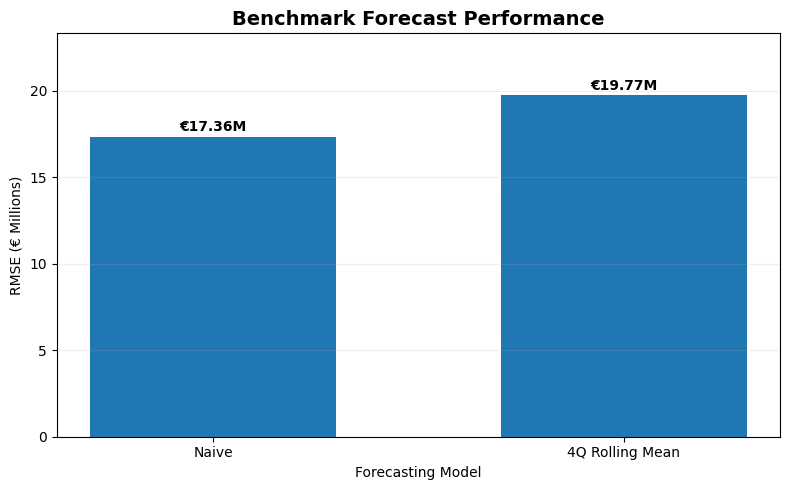

In [ ]:
# Visual comparison of benchmark RMSE
plt.figure(figsize=(8, 5))

bars = plt.bar(
    benchmark_comparison["Model"],
    benchmark_comparison["RMSE"],
    width=0.6
)

plt.title("Benchmark Forecast Performance", fontsize=14, fontweight="bold")
plt.xlabel("Forecasting Model")
plt.ylabel("RMSE (€ Millions)")

# Add RMSE values above each bar
for bar, value in zip(bars, benchmark_comparison["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"€{value:.2f}M",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, benchmark_comparison["RMSE"].max() * 1.18)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Takeaway**
- Naive persistence is the stronger benchmark, with lower MAE, RMSE, and MAPE than the four-quarter rolling mean.
- Its RMSE of €17.36M becomes the primary baseline for evaluating the more advanced forecasting models.
- The result also shows why simple benchmarks matter: additional smoothing does not automatically improve forecast accuracy.

## 9. Holt's Linear Trend Model

After establishing the benchmark forecasts, we now test whether explicitly modeling each player's trend can improve out-of-sample forecasting performance.

### 9.1 Model setup

**What we do**
- Fit a separate Holt linear trend model for each of the 15 players using only the training period.
- Forecast each player's market value across the eight-quarter 2023–2024 test period.
- Store the forecasts so they can be evaluated using the same metrics as the benchmark models.

**Why**
- Holt's method extends exponential smoothing by modeling both the current level and an underlying trend.
- This is useful for player valuations because market values may rise or decline gradually over multiple transfer windows.
- Fitting each player separately allows each valuation trajectory to have its own level and trend.

**What to look for**
- All 15 players should successfully receive forecasts.
- No 2023–2024 observations are used when fitting the model.
- Holt should be compared directly with the naive benchmark rather than judged only on its own error.

In [ ]:
from statsmodels.tsa.holtwinters import Holt

# Container for player-level Holt forecasts
holt_forecasts = []

# Fit one Holt model per player
for player_id in test["player_id"].unique():

    player_train = (
        train[train["player_id"] == player_id]
        .sort_values("q_idx")
    )

    player_test = (
        test[test["player_id"] == player_id]
        .sort_values("q_idx")
    )

    # Use numpy values so statsmodels does not depend on the
    # original DataFrame index
    y_train = player_train["value_m"].to_numpy()

    # Fit Holt's linear trend model using training data only
    model = Holt(
        y_train,
        initialization_method="estimated"
    ).fit(optimized=True)

    # Forecast the full 2023-2024 test horizon
    forecast = model.forecast(steps=len(player_test))

    # Store forecasts using the original test row index
    for idx, pred in zip(player_test.index, forecast):
        holt_forecasts.append({
            "index": idx,
            "pred_holt": float(pred)
        })

# Convert forecasts to a DataFrame
holt_forecasts = (
    pd.DataFrame(holt_forecasts)
    .set_index("index")
)

# Add forecasts back to the test set
test["pred_holt"] = holt_forecasts["pred_holt"]

print("HOLT FORECAST CHECK")
print("-" * 40)

print(
    f"Players forecasted: "
    f"{test.loc[test['pred_holt'].notna(), 'player_id'].nunique()}"
)

print(
    f"Missing forecasts: "
    f"{test['pred_holt'].isna().sum()}"
)

display(
    test[
        ["name", "period", "value_m", "pred_holt", "is_filled"]
    ].head(12)
)

HOLT FORECAST CHECK
----------------------------------------
Players forecasted: 15
Missing forecasts: 0


,name,period,value_m,pred_holt,is_filled
38,Serge Gnabry,2023Q1,55.0,63.721851,False
39,Serge Gnabry,2023Q2,55.0,63.008965,False
40,Serge Gnabry,2023Q3,55.0,62.296079,True
41,Serge Gnabry,2023Q4,45.0,61.583192,False
42,Serge Gnabry,2024Q1,45.0,60.870306,True
43,Serge Gnabry,2024Q2,40.0,60.157420,False
44,Serge Gnabry,2024Q3,40.0,59.444534,True
45,Serge Gnabry,2024Q4,35.0,58.731648,False
76,Waldemar Anton,2023Q1,4.5,4.651724,True
77,Waldemar Anton,2023Q2,4.5,4.803448,False


### 9.2 Holt forecast performance

**What we do**
- Evaluate Holt forecasts using MAE, RMSE, and MAPE.
- Report performance for both all test rows and observed-only valuation quarters.
- Compare the results with the naive benchmark.

**Why**
- Using the same test period and evaluation metrics makes the model comparison fair.
- The key question is whether explicitly modeling trend improves on simple persistence.

**What to look for**
- Holt should ideally produce errors below the naive benchmark.
- The naive RMSE of €17.36M is the current benchmark to beat.
- A lower RMSE would indicate that modeling player-specific trends adds useful forecasting information.

In [ ]:
# Evaluate Holt on all test rows
holt_all = forecast_metrics(
    test["value_m"],
    test["pred_holt"]
)

# Create a fresh observed-only subset after adding Holt forecasts
holt_observed_data = test[~test["is_filled"]].copy()

holt_observed = forecast_metrics(
    holt_observed_data["value_m"],
    holt_observed_data["pred_holt"]
)

holt_results = pd.DataFrame([
    {
        "Evaluation set": "All test rows",
        "MAE": holt_all["MAE"],
        "RMSE": holt_all["RMSE"],
        "MAPE": holt_all["MAPE"]
    },
    {
        "Evaluation set": "Observed-only rows",
        "MAE": holt_observed["MAE"],
        "RMSE": holt_observed["RMSE"],
        "MAPE": holt_observed["MAPE"]
    }
])

print("HOLT MODEL RESULTS")
print("-" * 40)

display(holt_results.round(2))

HOLT MODEL RESULTS
----------------------------------------


,Evaluation set,MAE,RMSE,MAPE
0,All test rows,11.85,16.04,29.45
1,Observed-only rows,12.77,16.93,31.75


**Takeaway**
- Holt improves on the naive benchmark across all three evaluation metrics.
- RMSE decreases from €17.36M for naive persistence to €16.04M with Holt, while MAE decreases from €13.26M to €11.85M.
- Performance remains slightly weaker on observed-only quarters, but Holt still provides a meaningful improvement over the current benchmark.
- This suggests that explicitly modeling player-specific valuation trends adds useful forecasting information.

### 9.3 Visual evaluation of Holt forecasts

**What we do**
- Compare Holt with the two benchmark models using RMSE.
- Visualize actual and predicted market values for selected players during the test period.
- Examine player-level forecast errors to see whether model performance is consistent across players.

**Why**
- Aggregate metrics summarize overall accuracy, but they do not show how forecasts behave over time or which players are difficult to predict.
- Visual evaluation helps connect the model results to actual player valuation trajectories.

**What to look for**
- Holt should show lower overall RMSE than both benchmark models.
- Forecast lines that remain close to actual test values indicate stronger player-level performance.
- Large differences across players would suggest that no single forecasting model works equally well for every valuation trajectory.

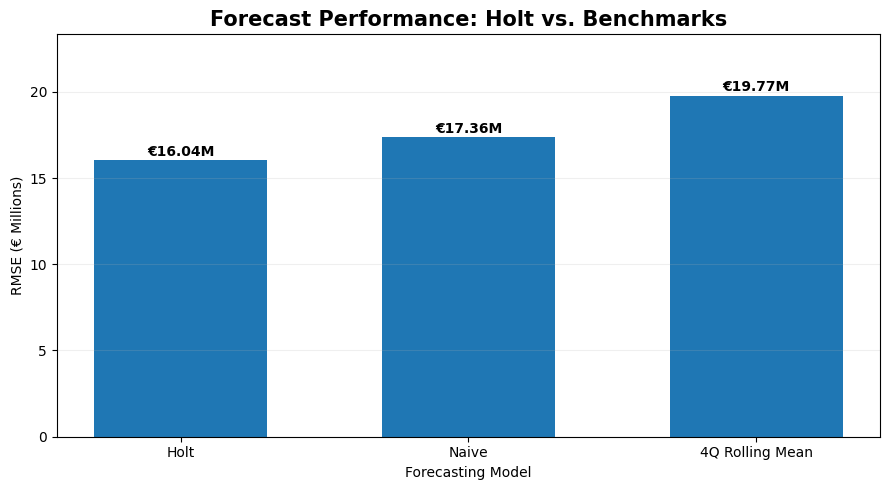

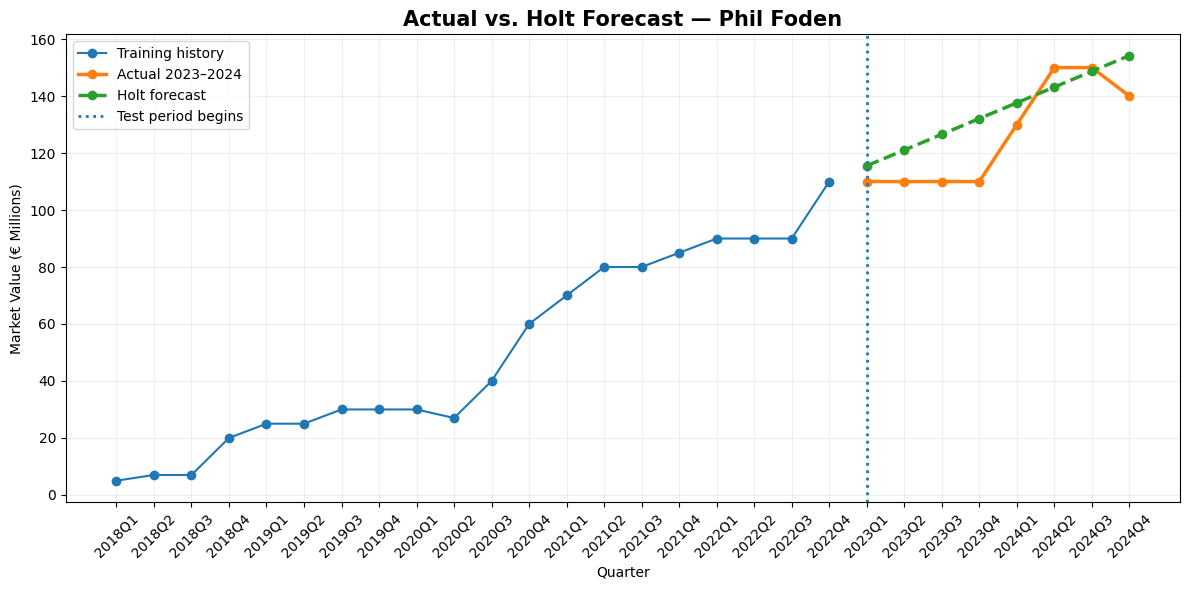

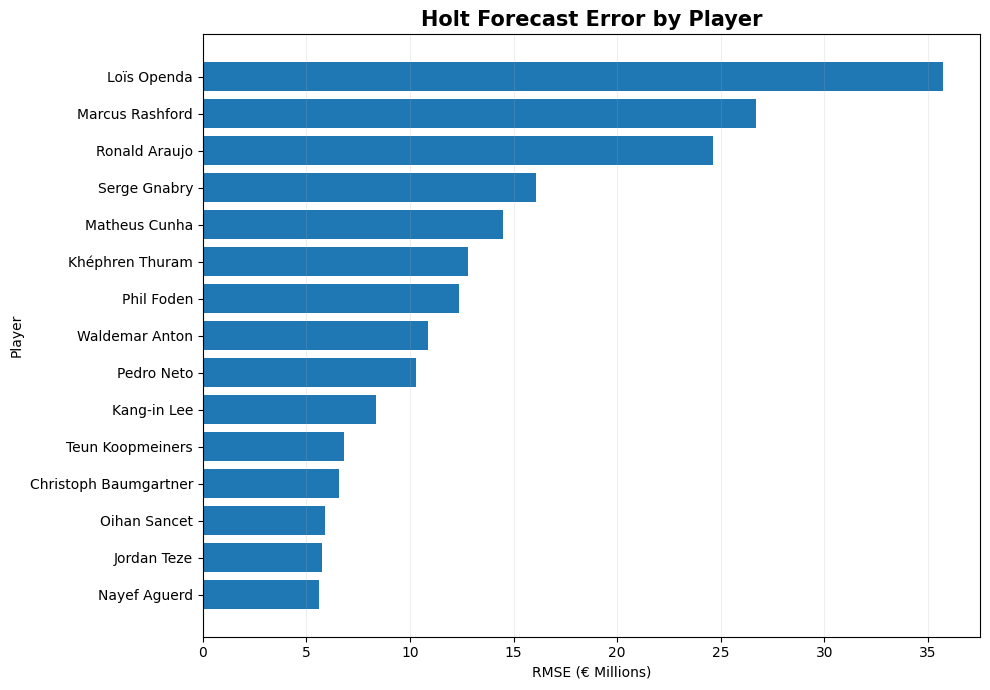

In [ ]:
model_comparison_holt = pd.DataFrame({
    "Model": ["Naive", "4Q Rolling Mean", "Holt"],
    "RMSE": [
        naive_all["RMSE"],
        rolling_all["RMSE"],
        holt_all["RMSE"]
    ]
}).sort_values("RMSE")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_comparison_holt["Model"],
    model_comparison_holt["RMSE"],
    width=0.6
)

plt.title(
    "Forecast Performance: Holt vs. Benchmarks",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("RMSE (€ Millions)")
plt.xlabel("Forecasting Model")

for bar, value in zip(bars, model_comparison_holt["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"€{value:.2f}M",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, model_comparison_holt["RMSE"].max() * 1.18)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()
# Select a high-value player as an illustrative example
example_player_id = (
    test.groupby("player_id")["value_m"]
        .mean()
        .idxmax()
)

example_name = (
    test.loc[test["player_id"] == example_player_id, "name"]
        .iloc[0]
)

player_train_plot = (
    train[train["player_id"] == example_player_id]
    .sort_values("q_idx")
)

player_test_plot = (
    test[test["player_id"] == example_player_id]
    .sort_values("q_idx")
)

plt.figure(figsize=(12, 6))

# Historical training values
plt.plot(
    player_train_plot["period"].astype(str),
    player_train_plot["value_m"],
    marker="o",
    label="Training history"
)

# Actual test values
plt.plot(
    player_test_plot["period"].astype(str),
    player_test_plot["value_m"],
    marker="o",
    linewidth=2.5,
    label="Actual 2023–2024"
)

# Holt forecasts
plt.plot(
    player_test_plot["period"].astype(str),
    player_test_plot["pred_holt"],
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label="Holt forecast"
)

# Mark beginning of test period
plt.axvline(
    x=str(player_test_plot["period"].iloc[0]),
    linestyle=":",
    linewidth=2,
    label="Test period begins"
)

plt.title(
    f"Actual vs. Holt Forecast — {example_name}",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Market Value (€ Millions)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()
# Player-level Holt RMSE
player_holt_rmse = []

for player_id, group in test.groupby("player_id"):

    metrics = forecast_metrics(
        group["value_m"],
        group["pred_holt"]
    )

    player_holt_rmse.append({
        "Player": group["name"].iloc[0],
        "RMSE": metrics["RMSE"]
    })

player_holt_rmse = (
    pd.DataFrame(player_holt_rmse)
    .sort_values("RMSE")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    player_holt_rmse["Player"],
    player_holt_rmse["RMSE"]
)

plt.title(
    "Holt Forecast Error by Player",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("RMSE (€ Millions)")
plt.ylabel("Player")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

**Visual takeaway**
- For Phil Foden, Holt captures the overall upward direction in market value reasonably well.
- However, the model projects a smooth increase, while the actual valuation remains flat through most of 2023 before rising sharply in 2024.
- This illustrates a limitation of trend-based forecasting: player valuations often change in discrete jumps rather than following a smooth trend.
- The result motivates testing ARIMA-based models that can respond differently to the time-series dynamics.

## 10. ARIMA Model

We next test whether an autoregressive time-series model can improve forecasts by using the internal dynamics of each player's valuation history.

### 10.1 ARIMA model selection

**What we do**
- Fit a separate ARIMA model for each of the 15 players using training data only.
- Search over a small set of reasonable ARIMA (p, d, q) specifications.
- Select the order with the lowest AIC for each player.
- Use the selected model to forecast the eight-quarter 2023–2024 test period.

**Why**
- ARIMA can capture persistence, changes over time, and short-term dependence in player valuation histories.
- Different players may follow different time-series patterns, so using the same ARIMA order for every player may be unnecessarily restrictive.
- AIC provides a consistent way to choose among a small set of candidate specifications without using the test set.

**What to look for**
- Each player should receive a selected ARIMA order and a complete set of test-period forecasts.
- Model selection should use training data only.
- The final ARIMA forecast error should be compared with Holt and the simple benchmarks.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Keep model-fitting warnings from overwhelming the notebook output
warnings.filterwarnings("ignore")

In [ ]:
# Candidate ARIMA orders
candidate_orders = [
    (1, 0, 0),
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1)
]

arima_forecasts = []
arima_orders = []

for player_id in test["player_id"].unique():

    player_train = (
        train[train["player_id"] == player_id]
        .sort_values("q_idx")
    )

    player_test = (
        test[test["player_id"] == player_id]
        .sort_values("q_idx")
    )

    # Use numpy values to avoid unsupported-index forecasting issues
    y_train = player_train["value_m"].to_numpy(dtype=float)

    best_aic = np.inf
    best_order = None
    best_model = None

    # Select the ARIMA order using training data only
    for order in candidate_orders:

        try:
            model = ARIMA(
                y_train,
                order=order
            ).fit()

            if np.isfinite(model.aic) and model.aic < best_aic:
                best_aic = model.aic
                best_order = order
                best_model = model

        except Exception:
            continue

    # Safety check
    if best_model is None:
        raise ValueError(
            f"No ARIMA specification could be fitted for player {player_id}"
        )

    # Forecast the full test horizon
    forecast = best_model.forecast(steps=len(player_test))

    player_name = player_train["name"].iloc[0]

    arima_orders.append({
        "player_id": player_id,
        "name": player_name,
        "selected_order": str(best_order),
        "AIC": best_aic
    })

    for idx, pred in zip(player_test.index, forecast):
        arima_forecasts.append({
            "index": idx,
            "pred_arima": float(pred)
        })

# Convert forecasts to DataFrame
arima_forecasts = (
    pd.DataFrame(arima_forecasts)
    .set_index("index")
)

# Add forecasts to test set
test["pred_arima"] = arima_forecasts["pred_arima"]

# Store selected orders
arima_order_results = pd.DataFrame(arima_orders)

print("ARIMA FORECAST CHECK")
print("-" * 40)

print(
    f"Players forecasted: "
    f"{test.loc[test['pred_arima'].notna(), 'player_id'].nunique()}"
)

print(
    f"Missing forecasts: "
    f"{test['pred_arima'].isna().sum()}"
)

display(
    arima_order_results[
        ["name", "selected_order", "AIC"]
    ].sort_values("name").reset_index(drop=True)
)

ARIMA FORECAST CHECK
----------------------------------------
Players forecasted: 15
Missing forecasts: 0


,name,selected_order,AIC
0,Christoph Baumgartner,"(1, 1, 0)",79.576059
1,Jordan Teze,"(0, 1, 1)",63.278693
2,Kang-in Lee,"(0, 1, 0)",103.409055
3,Khéphren Thuram,"(0, 1, 2)",71.572871
4,Loïs Openda,"(0, 1, 2)",64.242492
5,Marcus Rashford,"(0, 1, 0)",194.369025
6,Matheus Cunha,"(0, 1, 0)",124.290193
7,Nayef Aguerd,"(0, 1, 0)",104.863170
8,Oihan Sancet,"(0, 1, 0)",85.174267
9,Pedro Neto,"(0, 1, 0)",121.705208


**Takeaway**
- ARIMA specifications are selected separately for each player using training-period AIC.
- This allows the model structure to adapt to differences in individual valuation histories rather than imposing one ARIMA specification on every player.
- The held-out 2023–2024 period is not used during model selection.

### 10.2 ARIMA forecast performance

**What we do**
- Evaluate the selected player-level ARIMA forecasts using MAE, RMSE, and MAPE.
- Report results for both all test rows and observed-only valuation quarters.
- Compare ARIMA directly with Holt and the benchmark models.

**Why**
- Selecting a model by AIC does not guarantee better out-of-sample forecasting performance.
- The held-out test period provides the more important check of whether ARIMA actually improves prediction accuracy.

**What to look for**
- Holt currently has the strongest overall RMSE at €16.04M.
- ARIMA must improve on this value to become the strongest model so far.
- Differences between all-row and observed-only performance should also be monitored.

In [ ]:
# Evaluate ARIMA on all test rows
arima_all = forecast_metrics(
    test["value_m"],
    test["pred_arima"]
)

# Fresh observed-only subset containing the ARIMA forecasts
arima_observed_data = test[~test["is_filled"]].copy()

arima_observed = forecast_metrics(
    arima_observed_data["value_m"],
    arima_observed_data["pred_arima"]
)

arima_results = pd.DataFrame([
    {
        "Evaluation set": "All test rows",
        "MAE": arima_all["MAE"],
        "RMSE": arima_all["RMSE"],
        "MAPE": arima_all["MAPE"]
    },
    {
        "Evaluation set": "Observed-only rows",
        "MAE": arima_observed["MAE"],
        "RMSE": arima_observed["RMSE"],
        "MAPE": arima_observed["MAPE"]
    }
])

print("ARIMA MODEL RESULTS")
print("-" * 40)

display(arima_results.round(2))

ARIMA MODEL RESULTS
----------------------------------------


,Evaluation set,MAE,RMSE,MAPE
0,All test rows,13.29,17.07,33.16
1,Observed-only rows,14.02,17.94,35.30


**Takeaway**
- ARIMA achieves an MAE of €13.29M and RMSE of €17.07M across all test rows.
- ARIMA slightly improves RMSE relative to the naive benchmark (€17.36M), but it does not outperform Holt (€16.04M).
- The result shows that greater model complexity does not automatically lead to better out-of-sample forecasts.
- So far, Holt remains the strongest overall forecasting model.

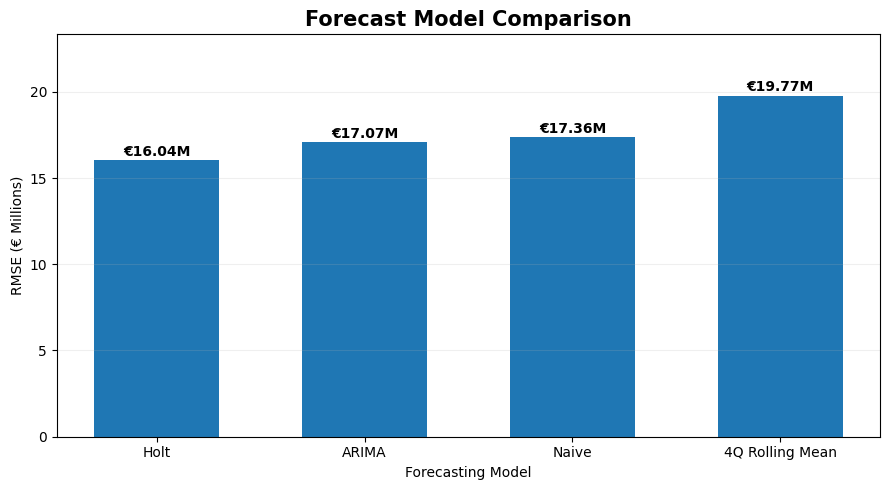

In [ ]:
# Compare all models evaluated so far
model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "4Q Rolling Mean",
        "Holt",
        "ARIMA"
    ],
    "RMSE": [
        naive_all["RMSE"],
        rolling_all["RMSE"],
        holt_all["RMSE"],
        arima_all["RMSE"]
    ]
}).sort_values("RMSE")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"],
    width=0.6
)

plt.title(
    "Forecast Model Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("RMSE (€ Millions)")
plt.xlabel("Forecasting Model")

for bar, value in zip(bars, model_comparison["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"€{value:.2f}M",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, model_comparison["RMSE"].max() * 1.18)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 11. SARIMAX and Final Model Comparison

Our final forecasting approach extends ARIMA by incorporating external information that may help explain changes in player market value.

### 11.1 SARIMAX with external factors

**What we do**
- Fit a separate SARIMAX model for each player using historical market values and selected external features.
- Use age-related information and transfer-window timing where available in the prepared panel.
- Select a reasonable ARIMA error structure using training-period AIC.
- Forecast the same 2023–2024 test period used for all previous models.

**Why**
- Player values may depend on more than their own historical valuation path.
- Age can capture changes associated with a player's career stage, while transfer-window timing may capture recurring market activity.
- SARIMAX allows these factors to be incorporated while retaining the time-series structure of ARIMA.

**What to look for**
- All 15 players should receive complete forecasts.
- External variables must be available in both the training and test periods.
- SARIMAX should be evaluated against Holt, ARIMA, and the simple benchmarks using the same test set.

In [ ]:
# Check available external features in the prepared panel
possible_exog = [
    "age",
    "age_sq",
    "age_at_date",
    "summer_window",
    "winter_window",
    "is_summer_window",
    "is_winter_window"
]

available_exog = [
    col for col in possible_exog
    if col in panel.columns
]

print("AVAILABLE EXTERNAL FEATURES")
print("-" * 40)

print(available_exog)

print("\nRelevant panel columns:")
print([
    col for col in panel.columns
    if "age" in col.lower() or "window" in col.lower()
])

AVAILABLE EXTERNAL FEATURES
----------------------------------------
['age', 'age_sq']

Relevant panel columns:
['age_obs', 'age', 'age_sq', 'window_winter', 'window_summer', 'window_any', 'window_type', 'age_bin']


### 11.2 SARIMAX model fitting

**What we do**
- Use age, winter-window, and summer-window indicators as external regressors.
- Fit a separate SARIMAX model for each player using training data only.
- Search across a small set of reasonable ARIMA error structures and select the specification with the lowest training-period AIC.
- Forecast player market values across the same 2023–2024 test period.

**Why**
- Age represents the player's career stage and changes gradually over time.
- Winter and summer indicators represent periods when transfer-market activity is typically more relevant.
- Keeping the external feature set small reduces unnecessary model complexity and makes the results easier to interpret.

**What to look for**
- All 15 players should receive complete forecasts.
- No missing values should appear in the external variables.
- The main question is whether adding external information improves out-of-sample accuracy beyond Holt and ARIMA.

In [ ]:
# External regressors used in SARIMAX
exog_cols = [
    "age",
    "window_winter",
    "window_summer"
]

print("SARIMAX EXTERNAL VARIABLES")
print("-" * 40)

display(
    panel[exog_cols]
    .describe()
    .round(2)
)

print("\nMissing values:")
print(panel[exog_cols].isna().sum())

SARIMAX EXTERNAL VARIABLES
----------------------------------------


,age,window_winter,window_summer
count,455.00,455.00,455.00
mean,22.35,0.24,0.26
std,2.61,0.43,0.44
min,17.33,0.00,0.00
25%,20.28,0.00,0.00
50%,22.25,0.00,0.00
75%,24.10,0.00,1.00
max,29.32,1.00,1.00



Missing values:
age              0
window_winter    0
window_summer    0
dtype: int64


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Small candidate set to keep model selection focused
sarimax_orders = [
    (1, 0, 0),
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

sarimax_forecasts = []
sarimax_orders_selected = []

for player_id in test["player_id"].unique():

    player_train = (
        train[train["player_id"] == player_id]
        .sort_values("q_idx")
        .copy()
    )

    player_test = (
        test[test["player_id"] == player_id]
        .sort_values("q_idx")
        .copy()
    )

    # Target
    y_train = player_train["value_m"].to_numpy(dtype=float)

    # External variables
    X_train = player_train[exog_cols].to_numpy(dtype=float)
    X_test = player_test[exog_cols].to_numpy(dtype=float)

    best_aic = np.inf
    best_order = None
    best_model = None

    # Select order using training data only
    for order in sarimax_orders:

        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            if np.isfinite(model.aic) and model.aic < best_aic:
                best_aic = model.aic
                best_order = order
                best_model = model

        except Exception:
            continue

    if best_model is None:
        raise ValueError(
            f"No SARIMAX specification could be fitted for player {player_id}"
        )

    # Forecast the 2023-2024 test period
    forecast = best_model.get_forecast(
        steps=len(player_test),
        exog=X_test
    ).predicted_mean

    player_name = player_train["name"].iloc[0]

    sarimax_orders_selected.append({
        "player_id": player_id,
        "name": player_name,
        "selected_order": str(best_order),
        "AIC": best_aic
    })

    for idx, pred in zip(player_test.index, forecast):
        sarimax_forecasts.append({
            "index": idx,
            "pred_sarimax": float(pred)
        })

# Add forecasts back to test data
sarimax_forecasts = (
    pd.DataFrame(sarimax_forecasts)
    .set_index("index")
)

test["pred_sarimax"] = sarimax_forecasts["pred_sarimax"]

sarimax_order_results = pd.DataFrame(
    sarimax_orders_selected
)

print("SARIMAX FORECAST CHECK")
print("-" * 40)

print(
    f"Players forecasted: "
    f"{test.loc[test['pred_sarimax'].notna(), 'player_id'].nunique()}"
)

print(
    f"Missing forecasts: "
    f"{test['pred_sarimax'].isna().sum()}"
)

display(
    sarimax_order_results[
        ["name", "selected_order", "AIC"]
    ]
    .sort_values("name")
    .reset_index(drop=True)
)

SARIMAX FORECAST CHECK
----------------------------------------
Players forecasted: 15
Missing forecasts: 0


,name,selected_order,AIC
0,Christoph Baumgartner,"(0, 1, 1)",73.545677
1,Jordan Teze,"(0, 1, 1)",61.907004
2,Kang-in Lee,"(1, 1, 1)",100.774996
3,Khéphren Thuram,"(0, 1, 1)",67.274077
4,Loïs Openda,"(0, 1, 1)",62.211099
5,Marcus Rashford,"(0, 1, 1)",186.865573
6,Matheus Cunha,"(1, 1, 1)",118.222118
7,Nayef Aguerd,"(0, 1, 1)",99.439044
8,Oihan Sancet,"(0, 1, 1)",79.616318
9,Pedro Neto,"(0, 1, 1)",113.450100


### 11.3 SARIMAX forecast performance

**What we do**
- Evaluate SARIMAX using the same MAE, RMSE, and MAPE metrics.
- Compare its out-of-sample performance with Naive, Rolling Mean, Holt, and ARIMA.
- Use the common 2023–2024 test period for a fair final comparison.

**Why**
- SARIMAX is the most information-rich model in our comparison because it combines time-series dynamics with external factors.
- Its value depends on whether those additional factors actually improve forecasts, not simply on greater model complexity.

**What to look for**
- Holt currently has the strongest RMSE at €16.04M.
- SARIMAX must improve on this benchmark to become the strongest overall model.
- If it does not, that would indicate that the external variables provide limited additional forecasting value in this sample.

In [ ]:
# Evaluate SARIMAX on all test rows
sarimax_all = forecast_metrics(
    test["value_m"],
    test["pred_sarimax"]
)

# Fresh observed-only subset
sarimax_observed_data = (
    test[~test["is_filled"]]
    .copy()
)

sarimax_observed = forecast_metrics(
    sarimax_observed_data["value_m"],
    sarimax_observed_data["pred_sarimax"]
)

sarimax_results = pd.DataFrame([
    {
        "Evaluation set": "All test rows",
        "MAE": sarimax_all["MAE"],
        "RMSE": sarimax_all["RMSE"],
        "MAPE": sarimax_all["MAPE"]
    },
    {
        "Evaluation set": "Observed-only rows",
        "MAE": sarimax_observed["MAE"],
        "RMSE": sarimax_observed["RMSE"],
        "MAPE": sarimax_observed["MAPE"]
    }
])

print("SARIMAX MODEL RESULTS")
print("-" * 40)

display(sarimax_results.round(2))

SARIMAX MODEL RESULTS
----------------------------------------


,Evaluation set,MAE,RMSE,MAPE
0,All test rows,12.35,17.02,31.00
1,Observed-only rows,13.11,17.93,32.91


### 11.4 Final model comparison

**What we do**
- Compare all five forecasting approaches using the same 2023–2024 holdout period.
- Rank the models using RMSE as the primary comparison metric while also reporting MAE and MAPE.
- Identify the strongest overall model for the final forecasting stage.

**Why**
- Using a common test period provides a fair comparison across models with different levels of complexity.
- The final model should be selected based on out-of-sample forecasting performance rather than model complexity alone.

**What to look for**
- Lower MAE, RMSE, and MAPE indicate stronger forecast performance.
- Holt currently provides the lowest errors across all three metrics.
- SARIMAX improves on ARIMA, but the additional external variables do not outperform Holt's simpler trend-based structure.

In [ ]:
# Final comparison across all forecasting models
final_model_comparison = pd.DataFrame([
    {
        "Model": "Naive",
        "MAE": naive_all["MAE"],
        "RMSE": naive_all["RMSE"],
        "MAPE": naive_all["MAPE"]
    },
    {
        "Model": "4Q Rolling Mean",
        "MAE": rolling_all["MAE"],
        "RMSE": rolling_all["RMSE"],
        "MAPE": rolling_all["MAPE"]
    },
    {
        "Model": "Holt",
        "MAE": holt_all["MAE"],
        "RMSE": holt_all["RMSE"],
        "MAPE": holt_all["MAPE"]
    },
    {
        "Model": "ARIMA",
        "MAE": arima_all["MAE"],
        "RMSE": arima_all["RMSE"],
        "MAPE": arima_all["MAPE"]
    },
    {
        "Model": "SARIMAX",
        "MAE": sarimax_all["MAE"],
        "RMSE": sarimax_all["RMSE"],
        "MAPE": sarimax_all["MAPE"]
    }
])

final_model_comparison = (
    final_model_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("FINAL MODEL COMPARISON")
print("-" * 50)

display(final_model_comparison.round(2))

FINAL MODEL COMPARISON
--------------------------------------------------


,Model,MAE,RMSE,MAPE
0,Holt,11.85,16.04,29.45
1,SARIMAX,12.35,17.02,31.00
2,ARIMA,13.29,17.07,33.16
3,Naive,13.26,17.36,32.90
4,4Q Rolling Mean,15.68,19.77,38.40


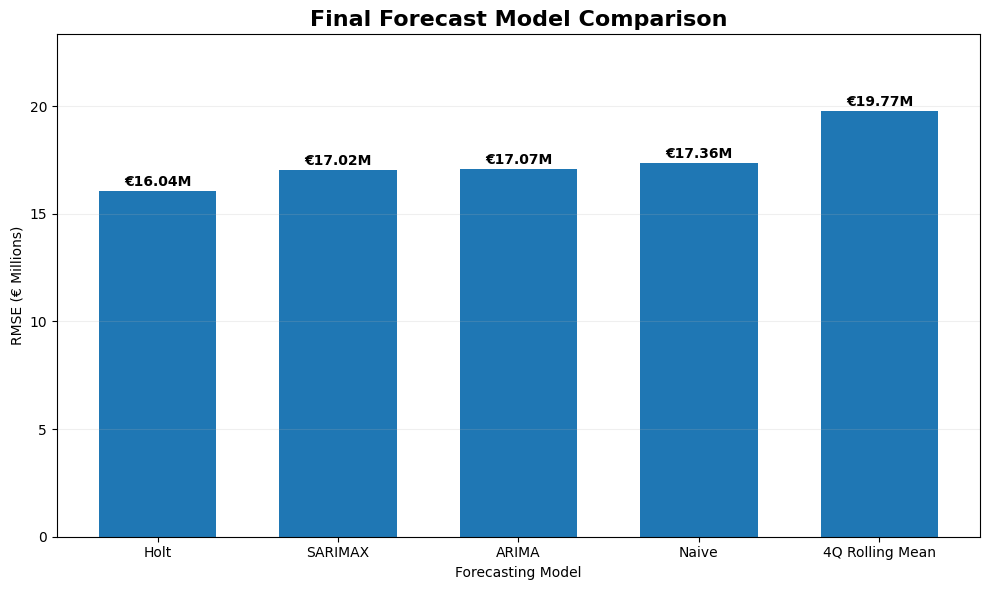

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["RMSE"],
    width=0.65
)

plt.title(
    "Final Forecast Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("RMSE (€ Millions)")
plt.xlabel("Forecasting Model")

for bar, value in zip(
    bars,
    final_model_comparison["RMSE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"€{value:.2f}M",
        ha="center",
        fontweight="bold"
    )

plt.ylim(
    0,
    final_model_comparison["RMSE"].max() * 1.18
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Takeaway**
- Holt is the strongest overall model, achieving the lowest MAE (€11.85M), RMSE (€16.04M), and MAPE (29.45%) on the full test set.
- SARIMAX improves on ARIMA after incorporating age and transfer-window information, but it still does not outperform Holt.
- The results show that additional model complexity does not necessarily produce better forecasts for player market values.
- Holt is therefore selected as the primary model for the final forecasting stage, while the other models provide useful benchmarks and robustness checks.

## 12. Final Forecast and Decision Support

The final stage translates the forecasting results into a practical transfer-market decision tool. Based on out-of-sample performance, Holt is used as the primary forecasting model.

### 12.1 Residual diagnostics

**What we do**
- Examine one-step fitted residuals from the selected Holt model across the player panel.
- Check whether forecast errors remain centered around zero.
- Use residual autocorrelation and the Ljung-Box test as diagnostic checks.

**Why**
- A strong forecasting model should not leave an obvious systematic pattern in its residuals.
- Residual diagnostics help identify whether meaningful time dependence remains unexplained.

**What to look for**
- Residuals should fluctuate around zero without a strong visible pattern.
- Lower autocorrelation suggests that the model has captured more of the time-series structure.
- Ljung-Box results provide an additional check for remaining serial correlation.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Use the same illustrative player shown earlier
diag_player_id = example_player_id
diag_name = example_name

diag_data = (
    panel[panel["player_id"] == diag_player_id]
    .sort_values("q_idx")
    .copy()
)

y_diag = diag_data["value_m"].to_numpy(dtype=float)

# Fit Holt to the full available history
diag_model = Holt(
    y_diag,
    initialization_method="estimated"
).fit(optimized=True)

# In-sample fitted residuals
diag_resid = y_diag - np.asarray(diag_model.fittedvalues)

print(f"RESIDUAL DIAGNOSTICS — {diag_name}")
print("-" * 50)

print(f"Mean residual: €{np.mean(diag_resid):.2f}M")
print(f"Residual standard deviation: €{np.std(diag_resid):.2f}M")

# Ljung-Box test
lb_result = acorr_ljungbox(
    diag_resid,
    lags=[4],
    return_df=True
)

display(lb_result.round(4))

RESIDUAL DIAGNOSTICS — Phil Foden
--------------------------------------------------
Mean residual: €0.00M
Residual standard deviation: €7.74M


,lb_stat,lb_pvalue
4,8.1757,0.0854


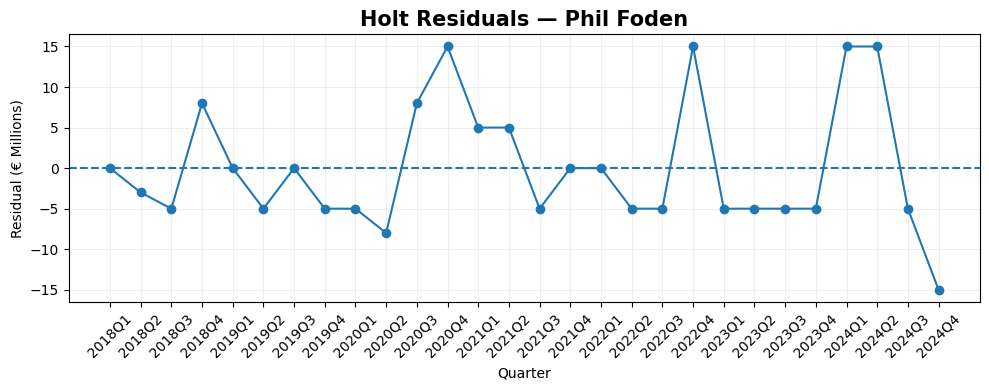

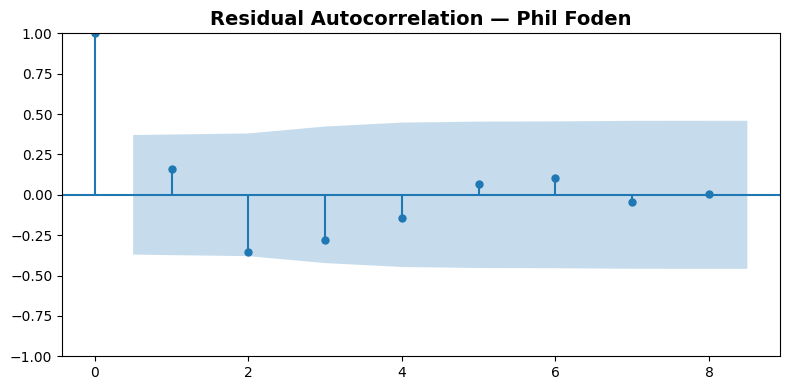

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    diag_data["period"].astype(str),
    diag_resid,
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    f"Holt Residuals — {diag_name}",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Residual (€ Millions)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    diag_resid,
    lags=min(8, len(diag_resid) - 1),
    ax=ax
)

ax.set_title(
    f"Residual Autocorrelation — {diag_name}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 12.2 Four-quarter future forecast

**What we do**
- Refit Holt using each player's full available valuation history.
- Generate forecasts for the next four quarters.
- Construct approximate 95% forecast intervals using the historical Holt residual variation.
- Present player-level forecasts in € millions.

**Why**
- After model selection, refitting on all available information allows the final forecast to use the most recent market-value history.
- A four-quarter horizon aligns the model with transfer-window and roster-planning decisions over approximately one year.

**What to look for**
- The point forecast represents the expected valuation path under the historical trend.
- The interval communicates uncertainty rather than treating the point forecast as an exact future market value.
- Wider intervals indicate greater uncertainty around the player's projected valuation.

In [ ]:
# Generate four-quarter future forecasts for all selected players
future_forecasts = []

for player_id in panel["player_id"].unique():

    player_data = (
        panel[panel["player_id"] == player_id]
        .sort_values("q_idx")
        .copy()
    )

    player_name = player_data["name"].iloc[0]
    y_full = player_data["value_m"].to_numpy(dtype=float)

    # Refit selected Holt model on all available history
    final_model = Holt(
        y_full,
        initialization_method="estimated"
    ).fit(optimized=True)

    forecast = np.asarray(
        final_model.forecast(steps=4),
        dtype=float
    )

    # Approximate uncertainty from historical fitted residuals
    residuals = (
        y_full -
        np.asarray(final_model.fittedvalues)
    )

    residual_sd = np.std(
        residuals,
        ddof=1
    )

    # Allow uncertainty to increase with forecast horizon
    horizons = np.arange(1, 5)

    interval_width = (
        1.96 *
        residual_sd *
        np.sqrt(horizons)
    )

    last_period = player_data["period"].iloc[-1]

    future_periods = pd.period_range(
        start=last_period + 1,
        periods=4,
        freq="Q"
    )

    for period, pred, width in zip(
        future_periods,
        forecast,
        interval_width
    ):
        future_forecasts.append({
            "player_id": player_id,
            "name": player_name,
            "period": str(period),
            "forecast_m": pred,
            "lower_95": max(0, pred - width),
            "upper_95": pred + width
        })

future_forecasts = pd.DataFrame(
    future_forecasts
)

print("FINAL FOUR-QUARTER FORECAST")
print("-" * 50)

display(
    future_forecasts
    .round(2)
    .head(12)
)

FINAL FOUR-QUARTER FORECAST
--------------------------------------------------


,player_id,name,period,forecast_m,lower_95,upper_95
0,159471,Serge Gnabry,2025Q1,32.40,18.82,45.97
1,159471,Serge Gnabry,2025Q2,29.46,10.25,48.66
2,159471,Serge Gnabry,2025Q3,26.52,3.00,50.03
3,159471,Serge Gnabry,2025Q4,23.58,0.00,50.73
4,193004,Waldemar Anton,2025Q1,26.78,22.32,31.24
5,193004,Waldemar Anton,2025Q2,29.57,23.26,35.87
6,193004,Waldemar Anton,2025Q3,32.35,24.62,40.07
7,193004,Waldemar Anton,2025Q4,35.13,26.21,44.05
8,258923,Marcus Rashford,2025Q1,54.34,37.09,71.59
9,258923,Marcus Rashford,2025Q2,53.68,29.29,78.08


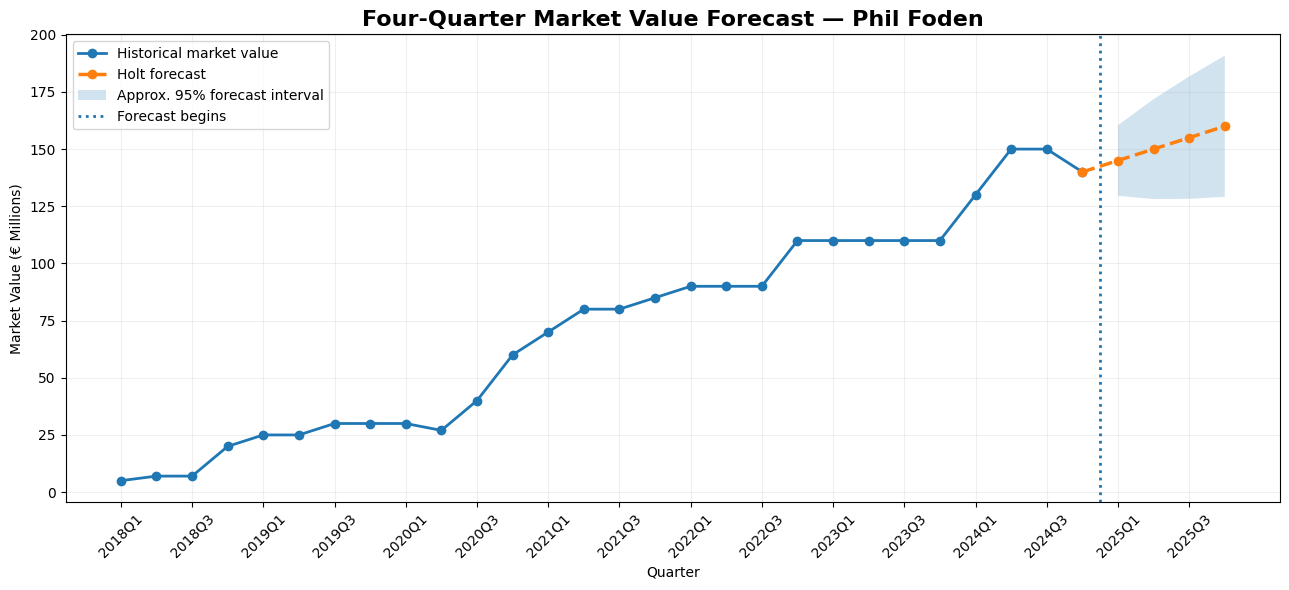

In [ ]:
# Historical data for the illustrative player
final_player_history = (
    panel[panel["player_id"] == example_player_id]
    .sort_values("q_idx")
    .copy()
)

# Future forecast for the same player
final_player_forecast = (
    future_forecasts[
        future_forecasts["player_id"] == example_player_id
    ]
    .copy()
)

history_x = (
    final_player_history["period"]
    .astype(str)
    .tolist()
)

future_x = (
    final_player_forecast["period"]
    .tolist()
)

all_x = history_x + future_x
x_positions = np.arange(len(all_x))

history_positions = np.arange(len(history_x))
future_positions = np.arange(
    len(history_x),
    len(all_x)
)

plt.figure(figsize=(13, 6))

# Historical values
plt.plot(
    history_positions,
    final_player_history["value_m"],
    marker="o",
    linewidth=2,
    label="Historical market value"
)

# Connect last actual observation to forecast
forecast_line_x = np.concatenate([
    [history_positions[-1]],
    future_positions
])

forecast_line_y = np.concatenate([
    [final_player_history["value_m"].iloc[-1]],
    final_player_forecast["forecast_m"].to_numpy()
])

plt.plot(
    forecast_line_x,
    forecast_line_y,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label="Holt forecast"
)

# Approximate 95% interval
plt.fill_between(
    future_positions,
    final_player_forecast["lower_95"],
    final_player_forecast["upper_95"],
    alpha=0.2,
    label="Approx. 95% forecast interval"
)

# Forecast boundary
plt.axvline(
    history_positions[-1] + 0.5,
    linestyle=":",
    linewidth=2,
    label="Forecast begins"
)

plt.title(
    f"Four-Quarter Market Value Forecast — {example_name}",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Market Value (€ Millions)")
plt.xlabel("Quarter")

# Keep labels readable
tick_step = max(1, len(all_x) // 12)

plt.xticks(
    x_positions[::tick_step],
    np.array(all_x)[::tick_step],
    rotation=45
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 12.3 Transfer-market decision support

**What we do**
- Translate the statistical forecast into a simple valuation signal.
- Compare a quoted transfer fee with the model's forecast range.
- Classify the quote as potentially undervalued, within the forecast range, or potentially overvalued.

**Why**
- Sporting directors and analysts need a decision-oriented output rather than only a forecast chart.
- Connecting a quoted fee to the forecast range makes the model easier to use during transfer and roster-planning discussions.

**Decision rule**
- **Below lower forecast bound:** Potentially undervalued.
- **Inside forecast range:** Within model range.
- **Above upper forecast bound:** Potentially overvalued.

The signal is decision support only and should not replace scouting, contract, injury, or performance analysis.

# Phase 2, Track B: log scale, shared forecast table, prototype horizons

Sections 13-18 model the log of market value, store every model's forecasts in one table, and select the model the prototype uses from its accuracy 2 and 4 quarters ahead. Results here are compared with Track A in section 19.

## 13. Modeling setup

### 13.1 Libraries and settings
**What we do:** Import the forecasting libraries and set the few values every Phase 2 section shares.

**Decisions:**
- `TEST_START_Q` is 2023 Q1, matching the proposal's split.
- `FORECAST_ORIGIN` is the last training quarter, 2022 Q4. Every model forecasts all 8 test quarters from that one origin, the same pattern as the Apple notebook (fit on train, forecast `len(test)` periods).
- `REPORT_H = [2, 4]`: the horizons the prototype shows (6 and 12 months ahead).

In [ ]:
# Forecasting and statistics libraries used in Phase 2
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.formula.api as smf

# Keep the output readable: these warnings are common with short series and do not stop the fits
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---- Settings shared by every Phase 2 section ----
TEST_START_Q    = 2023 * 4 + 1   # 2023 Q1 = first test quarter (running quarter number, as in Phase 1)
FORECAST_ORIGIN = TEST_START_Q - 1   # 2022 Q4 = last training quarter; all forecasts start here
REPORT_H        = [2, 4]         # horizons used by the prototype: 2 quarters (6 months), 4 quarters (12 months)

### 13.2 Log target and chronological split
**What we do:** Copy the Phase 1 panel into `model_df`, add `log_value = log(value_m)`, and split each player's series at 2023 Q1. Nothing is shuffled.

**Why log value:** Values in the cohort run from €0.5M to over €100M. On the raw scale a €10M miss on a €150M star and a €10M miss on a €12M squad player count the same, and the stars dominate every model fit. On the log scale a change of 0.10 means roughly a 10% change for any player, so the models learn percentage movements, which is how valuations actually move. The course's panel notebook (03) uses log outcomes for the same reason. We convert forecasts back to € millions with `exp()` before computing the € metrics in section 16, so every reported number is in the proposal's units.

**Decision:** We keep every training row Phase 1 built, including the 12 rows before 2016 for players whose history starts earlier (for example Serge Gnabry from 2013). Phase 1 defines the data; Phase 2 does not trim it.

**What to look for:** Every player has exactly 8 test quarters and at least 16 training quarters. All checks read `OK`.

In [ ]:
# Copy the Phase 1 panel so Phase 2 never changes it
model_df = panel.copy().sort_values(["player_id", "q_idx"]).reset_index(drop=True)

# Modeling target: log of market value (€ millions)
model_df["log_value"] = np.log(model_df["value_m"])

# Chronological split: training = before 2023 Q1, test = 2023 Q1 to 2024 Q4
model_df["is_test"] = model_df["q_idx"] >= TEST_START_Q
train_df = model_df[~model_df["is_test"]]
test_df  = model_df[model_df["is_test"]]

# Checks: series lengths per player
train_len = train_df.groupby("player_id").size()
test_len  = test_df.groupby("player_id").size()
checks = pd.DataFrame([
    ["Players with a test window of exactly 8 quarters", int((test_len == 8).sum()), model_df["player_id"].nunique()],
    ["Players with at least 16 training quarters", int((train_len >= 16).sum()), model_df["player_id"].nunique()],
    ["Training rows dated in or after the test window", int((train_df["q_idx"] >= TEST_START_Q).sum()), 0],
], columns=["Check", "Result", "Expected"])
checks["Status"] = np.where(checks["Result"] == checks["Expected"], "OK", "REVIEW")
print("SPLIT CHECKS")
display(checks)

print(f"Training rows: {len(train_df)}  |  Test rows: {len(test_df)}  |  "
      f"Shortest training series: {train_len.min()} quarters  |  Longest: {train_len.max()} quarters")

SPLIT CHECKS


,Check,Result,Expected,Status
0,Players with a test window of exactly 8 quarters,15,15,OK
1,Players with at least 16 training quarters,15,15,OK
2,Training rows dated in or after the test window,0,0,OK


Training rows: 335  |  Test rows: 120  |  Shortest training series: 16 quarters  |  Longest: 38 quarters


**Takeaway:** In our reproduction run, all 15 players have exactly 8 test quarters and between 16 and 38 training quarters (335 training rows, 120 test rows). Confirm these numbers against your own run.

### 13.3 How every model stores its forecasts
**What we do:** Define one shared format for forecasts and one helper function that every model uses to save its output.

**Why:** Six model families are written in different sections, possibly by different teammates. If each one saves its forecasts in the same table, a single evaluation section (16) can score all of them identically, and nobody has to rewrite metric code.

**The format:** one row per player, per test quarter, per model, with columns `player_id`, `name`, `q_idx`, `period`, `h` (quarters ahead, 1-8), `model`, `forecast_log`, `actual_log`, `actual_m`, `is_filled`.

In [ ]:
# Shared forecast store: every model appends its forecasts here in the same format
forecast_rows = []

def record_forecast(model_name, test_rows, forecast_log):
    # Save one player's forecasts for the 8 test quarters.
    # test_rows    : that player's test rows from test_df (in quarter order)
    # forecast_log : array of forecasts on the log scale, same length as test_rows
    forecast_log = np.asarray(forecast_log, dtype=float)
    for h, (_, row) in enumerate(test_rows.iterrows(), start=1):
        forecast_rows.append({
            "player_id": row["player_id"], "name": row["name"],
            "q_idx": row["q_idx"], "period": row["period"], "h": h,
            "model": model_name, "forecast_log": forecast_log[h - 1],
            "actual_log": row["log_value"], "actual_m": row["value_m"],
            "is_filled": row["is_filled"],
        })

# Helper: one player's training and test rows
def player_split(pid):
    return (train_df[train_df["player_id"] == pid],
            test_df[test_df["player_id"] == pid])

player_ids = model_df["player_id"].unique()

### 13.4 Look at the series on the log scale
**What we do:** Plot every player's log value with the test window shaded.

**What to look for:** On the log scale the paths are more comparable across players. Most rise steeply in their late teens and flatten in their mid-20s, the aging pattern the age-based models try to capture. Flat steps are forward-filled quarters.

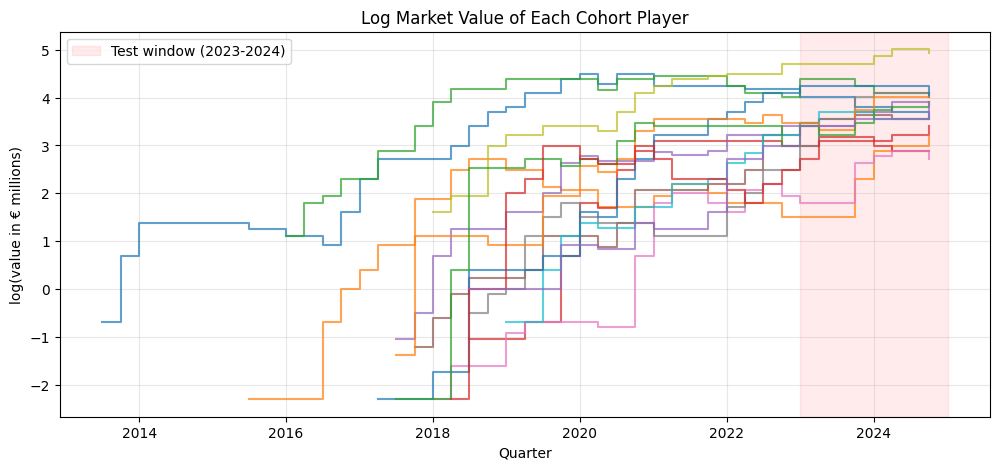

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for pid, g in model_df.groupby("player_id"):
    ax.step(g["date"], g["log_value"], where="post", alpha=0.7)
ax.axvspan(pd.Timestamp("2023-01-01"), model_df["date"].max() + pd.DateOffset(months=3),
           color="red", alpha=0.08, label="Test window (2023-2024)")
ax.set_title("Log Market Value of Each Cohort Player")
ax.set_xlabel("Quarter")
ax.set_ylabel("log(value in € millions)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 14. Benchmarks and ARIMA

Every candidate model must beat a simple benchmark to be worth using. The course notebook on random walks makes the point directly: for prices, the last observed value is often surprisingly hard to beat.

### 14.1 Persistence benchmark (random walk)
**What we do:** Forecast every test quarter with the player's last training value (2022 Q4). This is the same code pattern as the Apple notebook: `np.repeat(last_train_value, len(test))`.

**Why it is the main benchmark:** A random walk is both a model and a benchmark. Its point forecast is identical to ARIMA(0,1,0). If a more complex model cannot beat it, the complexity is not earning its place.

In [ ]:
# Persistence: repeat the last training value for all 8 test quarters
for pid in player_ids:
    tr, te = player_split(pid)
    last_value = tr["log_value"].iloc[-1]
    record_forecast("Persistence (random walk)", te, np.repeat(last_value, len(te)))

print("Persistence forecasts stored for", len(player_ids), "players")

Persistence forecasts stored for 15 players


### 14.2 Rolling-mean benchmark
**What we do:** Forecast every test quarter with the average of the last 4 training quarters.

**Why:** This second benchmark from the proposal smooths out the last revision. For players whose value is still rising it will lag behind, so we expect it to do worse than persistence. Including it shows that conclusion with numbers instead of assuming it.

In [ ]:
# Rolling mean: average of the last 4 training quarters, repeated for all 8 test quarters
for pid in player_ids:
    tr, te = player_split(pid)
    record_forecast("Rolling mean (4 quarters)", te, np.repeat(tr["log_value"].iloc[-4:].mean(), len(te)))

print("Rolling-mean forecasts stored")

Rolling-mean forecasts stored


### 14.3 ARIMA candidates
**What we do:** Fit a small set of ARIMA orders to each player's training series and forecast the 8 test quarters. We reuse the course's approach: change only the `order=(p, d, q)` and compare test error.

**Decisions:**
- **`d = 1` in every candidate.** Market values trend and do not return to a fixed level, so we model quarter-to-quarter changes, as the Apple notebook did with prices.
- **Candidates:** ARIMA(0,1,1), ARIMA(1,1,0), ARIMA(1,1,1), and ARIMA(0,1,0) **with drift** (a random walk plus a constant average change per quarter). With only 16-38 training quarters per player, higher orders would overfit.
- **The drift version** tests the idea that a player's past average growth continues. For young players whose values climbed fast, this extrapolates that climb, which may be unrealistic.
- **If a fit fails** for a player, we record it and fall back to persistence for that player, so every model is scored on the same 15 players.

**What to look for:** The failure count should be zero or very small.

In [ ]:
# ARIMA candidates: (p, d, q) orders and whether to include drift
ARIMA_CANDIDATES = {
    "ARIMA(0,1,1)":           dict(order=(0, 1, 1), trend="n"),
    "ARIMA(1,1,0)":           dict(order=(1, 1, 0), trend="n"),
    "ARIMA(1,1,1)":           dict(order=(1, 1, 1), trend="n"),
    "ARIMA(0,1,0) with drift": dict(order=(0, 1, 0), trend="t"),   # with d=1, trend "t" = constant drift
}

arima_failures = []
for model_name, spec in ARIMA_CANDIDATES.items():
    for pid in player_ids:
        tr, te = player_split(pid)
        try:
            fit = ARIMA(tr["log_value"].values, order=spec["order"], trend=spec["trend"]).fit()
            fc = fit.forecast(steps=len(te))
        except Exception as err:
            arima_failures.append((model_name, pid, str(err)[:60]))
            fc = np.repeat(tr["log_value"].iloc[-1], len(te))   # fallback: persistence
        record_forecast(model_name, te, fc)

print(f"ARIMA fits that failed (fell back to persistence): {len(arima_failures)}")
if arima_failures:
    display(pd.DataFrame(arima_failures, columns=["Model", "player_id", "Error"]))

ARIMA fits that failed (fell back to persistence): 0


## 15. Holt, SARIMAX and the pooled age-drift model

### 15.1 Holt's linear trend (plain and damped)
**What we do:** Fit Holt's exponential smoothing with a trend, once with a plain linear trend (as in the proposal) and once with a **damped** trend.

**Why both:** Plain Holt keeps the latest trend forever, so a player who rose quickly is projected to keep rising at the same rate for 8 quarters. The damped version lets the trend fade over the horizon, which fits how valuations level off in a player's mid-20s. Comparing the two shows whether damping matters.

In [ ]:
# Holt's linear trend: plain and damped
holt_failures = []
for model_name, damped in [("Holt linear trend", False), ("Holt damped trend", True)]:
    for pid in player_ids:
        tr, te = player_split(pid)
        try:
            fit = ExponentialSmoothing(tr["log_value"].values, trend="add", damped_trend=damped).fit()
            fc = fit.forecast(len(te))
        except Exception as err:
            holt_failures.append((model_name, pid, str(err)[:60]))
            fc = np.repeat(tr["log_value"].iloc[-1], len(te))
        record_forecast(model_name, te, fc)

print(f"Holt fits that failed (fell back to persistence): {len(holt_failures)}")

Holt fits that failed (fell back to persistence): 0


### 15.2 SARIMAX with transfer-window and age regressors
**What we do:** Fit two SARIMAX models per player with external regressors, as the proposal planned:
- **SARIMAX (windows):** a random walk plus the `window_summer` and `window_winter` dummies.
- **SARIMAX (windows + age):** the same plus `age`.

**Why these regressors are usable for forecasting:** Every regressor must be known for the future quarters we forecast (point 4 of the professor's feedback). Window dummies follow the calendar, and age grows by exactly 0.25 per quarter, so both are known in advance. We never feed the model a future value we would not have.

**Why we use window dummies instead of a seasonal ARIMA term:** A seasonal term with period 4 needs many years of history per player to estimate. Our players have 4-9 training years, so the dummies are the simpler, more stable way to test the proposal's seasonality idea.

**An important property of `age` in a single-player model:** with `d = 1` the model works on quarter-to-quarter changes, and age changes by exactly 0.25 every quarter. Inside one player's model, the age regressor therefore acts as a constant drift, the same thing ARIMA(0,1,0) with drift estimates. One player's own history cannot separate "getting older" from "trending upward". Section 15.3 solves this by learning the age effect across all players at once.

**How statsmodels uses the regressors:** SARIMAX fits a *regression with ARIMA errors*: the regressors shift the **level** of the series, and the random-walk part carries everything else. So a window dummy adds a premium to the Q1 or Q3 quarter itself, and the value returns to the random-walk path in the next quarter. It is not a permanent step up. One consequence: at quarters with no window (Q2 and Q4), the SARIMAX (windows) forecast equals the persistence forecast.

In [ ]:
# SARIMAX with known-in-advance regressors
SARIMAX_SPECS = {
    "SARIMAX (windows)":       ["window_summer", "window_winter"],
    "SARIMAX (windows + age)": ["window_summer", "window_winter", "age"],
}

sarimax_failures = []
for model_name, exog_cols in SARIMAX_SPECS.items():
    for pid in player_ids:
        tr, te = player_split(pid)
        try:
            fit = SARIMAX(tr["log_value"].values, exog=tr[exog_cols].astype(float).values,
                          order=(0, 1, 0)).fit(disp=False)
            fc = fit.forecast(steps=len(te), exog=te[exog_cols].astype(float).values)
        except Exception as err:
            sarimax_failures.append((model_name, pid, str(err)[:60]))
            fc = np.repeat(tr["log_value"].iloc[-1], len(te))
        record_forecast(model_name, te, fc)

print(f"SARIMAX fits that failed (fell back to persistence): {len(sarimax_failures)}")

SARIMAX fits that failed (fell back to persistence): 0


### 15.3 Pooled age-drift model (one aging curve learned across all players)
**What we do:** Fit **one** regression on the training rows of all 15 players at once:

$$\Delta \log(\text{value})_{it} = \beta_0 + \beta_1 \cdot \text{age}_{it} + \varepsilon_{it}$$

where $\Delta \log(\text{value})_{it}$ is player $i$'s change in log value from the previous quarter. To forecast, we start from each player's last training value and add the predicted change for each future quarter at that player's future age.

**Why this model:** A single player's series cannot tell aging apart from trend (see 15.2). Across 15 players of different ages, it can: a 19-year-old and a 26-year-old observed in the same years show how growth changes with age. This applies the panel-data idea from the course's notebook 03: use the **unit × time** structure, and work with within-player **changes** so that each player's stable talent level drops out.

**Decisions:**
- **Standard errors are clustered by player**, exactly as notebook 03 clusters by country, because quarters from the same player are related.
- **Only training rows (before 2023) are used**, so no test information leaks into the fit.
- **Age enters linearly in the change equation.** That already gives a curved path for the value level: growth slows as the player ages and turns negative after the age where $\beta_0 + \beta_1 \cdot \text{age} = 0$.
- **The forecast extends the age curve from each player's own last value**, so stars and squad players keep their own levels.

**What to look for:** A negative age coefficient (growth slows with age) and the implied age where growth reaches zero.

**Caveats:**
- Every cohort player was selected for long, successful careers (they are among the most valuable in their league at the scrape date), so the estimated growth for young players is optimistic.
- The training rows cover ages of roughly 17.6 to 27.3. Forecasts for older players (up to about 30 by 2025) extend the straight-line age effect beyond the ages it was estimated on, so their predicted declines are extrapolations.

In [ ]:
# Fit the pooled age-drift model on training rows only
def quarterly_changes(df):
    # Add each player's quarter-to-quarter change in log value (first quarter of each player has none)
    out = df.sort_values(["player_id", "q_idx"]).copy()
    out["d_log_value"] = out.groupby("player_id")["log_value"].diff()
    return out.dropna(subset=["d_log_value"])

pooled_train = quarterly_changes(train_df)
pooled_fit = smf.ols("d_log_value ~ age", data=pooled_train).fit(
    cov_type="cluster", cov_kwds={"groups": pooled_train["player_id"]}
)

coef_table = pd.DataFrame({
    "Coefficient": pooled_fit.params, "Std. Error (clustered)": pooled_fit.bse, "p-value": pooled_fit.pvalues
}).round(4)
print("POOLED AGE-DRIFT MODEL (training rows, all players)")
display(coef_table)

zero_growth_age = -pooled_fit.params["Intercept"] / pooled_fit.params["age"]
print(f"Implied age at which quarterly value growth reaches zero: {zero_growth_age:.1f}")
print(f"Each extra year of age changes quarterly growth by {pooled_fit.params['age']:.3f} log points "
      f"(about {100 * pooled_fit.params['age']:.1f} percentage points)")

POOLED AGE-DRIFT MODEL (training rows, all players)


,Coefficient,Std. Error (clustered),p-value
Intercept,1.4576,0.2762,0.0
age,-0.0586,0.0131,0.0


Implied age at which quarterly value growth reaches zero: 24.9
Each extra year of age changes quarterly growth by -0.059 log points (about -5.9 percentage points)


**Takeaway:** In our reproduction run the age coefficient is about -0.059 (p < 0.001), and quarterly growth reaches zero at about age 25: players gain value quickly in their late teens, the gains shrink every year, and they stop around 25. Confirm the numbers in your run. The growth levels for young players are inflated by the cohort's selection on success.

In [ ]:
# Forecast with the pooled model: last training value plus the predicted change for each future quarter
for pid in player_ids:
    tr, te = player_split(pid)
    predicted_changes = pooled_fit.predict(te)              # uses each test quarter's (known) age
    fc = tr["log_value"].iloc[-1] + np.cumsum(predicted_changes.values)
    record_forecast("Pooled age drift", te, fc)

forecasts = pd.DataFrame(forecast_rows)
print("Models stored:", forecasts["model"].nunique(), "|  Forecast rows:", len(forecasts))
display(forecasts.groupby("model").size().to_frame("rows (15 players x 8 quarters)"))

Models stored: 11 |  Forecast rows: 1320


,rows (15 players x 8 quarters)
model,
"ARIMA(0,1,0) with drift",120
"ARIMA(0,1,1)",120
"ARIMA(1,1,0)",120
"ARIMA(1,1,1)",120
Holt damped trend,120
Holt linear trend,120
Persistence (random walk),120
Pooled age drift,120
Rolling mean (4 quarters),120


## 16. Evaluation and diagnostics

### 16.1 Out-of-sample accuracy: all test rows vs observed-only rows
**What we do:** Score every model on the 2023-2024 test window with the proposal's metrics:
- **MAE (€M):** average absolute miss in € millions.
- **RMSE (€M):** like MAE but penalizes big misses more.
- **MAPE (%):** average miss as a percentage of the actual value.
- **MAE (log):** average miss on the log scale, roughly the typical percentage miss. It treats every player equally regardless of value.

**Why two versions of the table:** In the test window, some quarters are forward-filled copies of the previous value (all of 2023 Q3 and 2024 Q3, see 16.5). A copied value is easy for persistence to "predict", which flatters it. The observed-only table scores models on quarters with a real Transfermarkt valuation.

**What to look for:** Whether any model beats persistence, and whether the ranking holds in both tables. Tables are sorted by MAE (€M), the same way the Apple notebook ranked models.

In [ ]:
# Convert forecasts back to € millions and compute errors
forecasts["forecast_m"] = np.exp(forecasts["forecast_log"])
forecasts["abs_err_m"]   = (forecasts["actual_m"] - forecasts["forecast_m"]).abs()
forecasts["abs_err_log"] = (forecasts["actual_log"] - forecasts["forecast_log"]).abs()
forecasts["ape"]         = 100 * forecasts["abs_err_m"] / forecasts["actual_m"]

def score_table(df):
    # One row per model: MAE, RMSE and MAPE in the proposal's units, plus MAE on the log scale
    return (df.groupby("model")
              .agg(**{"MAE (€M)": ("abs_err_m", "mean"),
                      "RMSE (€M)": ("abs_err_m", lambda e: np.sqrt((e ** 2).mean())),
                      "MAPE (%)": ("ape", "mean"),
                      "MAE (log)": ("abs_err_log", "mean"),
                      "Rows": ("abs_err_m", "size")})
              .sort_values("MAE (€M)").round(3))

print("TEST ACCURACY: ALL TEST ROWS (2023-2024)")
display(score_table(forecasts))
print("\nTEST ACCURACY: OBSERVED-ONLY TEST ROWS (quarters with a real valuation)")
display(score_table(forecasts[~forecasts["is_filled"]]))

TEST ACCURACY: ALL TEST ROWS (2023-2024)


,MAE (€M),RMSE (€M),MAPE (%),MAE (log),Rows
model,,,,,
SARIMAX (windows),13.171,17.570,32.375,0.447,120
Persistence (random walk),13.262,17.361,32.897,0.452,120
"ARIMA(1,1,0)",13.590,17.331,34.115,0.480,120
"ARIMA(0,1,1)",14.010,17.820,35.173,0.496,120
Pooled age drift,14.414,19.610,33.904,0.475,120
Rolling mean (4 quarters),15.980,20.093,39.092,0.554,120
Holt damped trend,20.023,38.462,46.153,0.455,120
"ARIMA(1,1,1)",27.445,57.519,55.880,0.539,120
"ARIMA(0,1,0) with drift",53.416,93.306,119.974,0.675,120



TEST ACCURACY: OBSERVED-ONLY TEST ROWS (quarters with a real valuation)


,MAE (€M),RMSE (€M),MAPE (%),MAE (log),Rows
model,,,,,
Persistence (random walk),14.101,18.131,35.045,0.487,79
SARIMAX (windows),14.172,18.273,35.288,0.494,79
"ARIMA(1,1,0)",14.388,18.155,36.169,0.519,79
"ARIMA(0,1,1)",14.855,18.656,37.344,0.536,79
Pooled age drift,15.054,20.262,35.278,0.500,79
Rolling mean (4 quarters),16.497,20.677,40.229,0.577,79
Holt damped trend,19.773,38.053,46.253,0.472,79
"ARIMA(1,1,1)",27.742,58.626,57.891,0.572,79
"ARIMA(0,1,0) with drift",53.058,95.409,119.123,0.665,79


**Takeaway:** In our reproduction run, **persistence and SARIMAX (windows) are essentially tied for the lowest € error** (MAE €13.26M vs €13.17M on all rows). On observed-only rows persistence is first. SARIMAX (windows) is persistence plus small Q1/Q3 level premiums (see 15.2), so it is not a meaningfully different model. ARIMA(1,1,0) and the pooled age-drift model follow closely (€13.6M and €14.4M). **The trend-extrapolating models are far worse**: ARIMA with drift, Holt linear trend and SARIMAX (windows + age) all have MAE above €53M, because they extend the fast growth of young players' training years straight through 2023-2024. This matches the course lesson from the Apple notebook: a more complex model is not automatically better than the random walk. Confirm the numbers in your run. These rankings cover Track B's log-scale models only. Track A's Holt, fit on the € scale, has a much lower € error than Track B's Holt (section 11.4); section 19 explains why and scores both tracks together.

### 16.2 Accuracy at the prototype's horizons (2 and 4 quarters ahead)
**What we do:** Report MAE at h = 2 and h = 4 quarters ahead, the horizons the prototype shows.

**Why:** The professor's feedback asks that the test reflect the same forecasting task shown in the prototype. The 8-quarter average in 16.1 mixes short and long horizons; a sporting director using our tool cares about 6 and 12 months ahead.

**Why the log scale is shown first:** At a single horizon there are only 15 errors per model (one per player). On the € scale one star player can decide the ranking; on the log scale every player counts equally.

In [ ]:
# MAE at the prototype's horizons
at_h = forecasts[forecasts["h"].isin(REPORT_H)]
by_h = at_h.pivot_table(index="model", columns="h", values=["abs_err_log", "abs_err_m"], aggfunc="mean")
by_h.columns = [f"{'MAE (log)' if m == 'abs_err_log' else 'MAE (€M)'} h={h}" for m, h in by_h.columns]
by_h["MAE (log), avg of h=2 and h=4"] = by_h[[f"MAE (log) h={h}" for h in REPORT_H]].mean(axis=1)
by_h = by_h.sort_values("MAE (log), avg of h=2 and h=4").round(3)

print("ACCURACY AT THE PROTOTYPE'S HORIZONS")
display(by_h)

ACCURACY AT THE PROTOTYPE'S HORIZONS


,MAE (log) h=2,MAE (log) h=4,MAE (€M) h=2,MAE (€M) h=4,"MAE (log), avg of h=2 and h=4"
model,,,,,
Pooled age drift,0.267,0.421,9.361,13.915,0.344
Holt damped trend,0.320,0.415,11.335,17.140,0.367
Persistence (random walk),0.285,0.470,8.467,12.633,0.377
SARIMAX (windows),0.285,0.470,8.467,12.633,0.377
"ARIMA(1,1,0)",0.320,0.507,9.819,13.389,0.414
"ARIMA(1,1,1)",0.321,0.530,11.760,22.240,0.425
"ARIMA(0,1,1)",0.336,0.518,9.661,13.625,0.427
SARIMAX (windows + age),0.322,0.544,13.995,35.207,0.433
"ARIMA(0,1,0) with drift",0.320,0.547,13.953,35.320,0.433


**Takeaway:** In our reproduction run the **pooled age-drift model has the lowest log error at h = 2** (0.267 vs 0.285 for persistence), and **Holt damped is lowest at h = 4** (0.415), with pooled age drift just behind (0.421) and persistence at 0.470. On the € scale, persistence is still lowest at both horizons, because the € metric is dominated by a few high-value players. SARIMAX (windows) matches persistence exactly here, since h = 2 and h = 4 are Q2 and Q4 quarters with no window premium. The differences are small and rest on 15 players, so treat the ranking as suggestive. Confirm in your run.

### 16.3 How many players does each model beat persistence for?
**What we do:** For each model, count the players whose average log error is lower than persistence's.

**Why:** Averages can hide a model that is excellent for most players but terrible for a few (or the reverse). This table shows how consistent each model is.

In [ ]:
# Share of players where each model beats persistence (average log error over the 8 test quarters)
player_err = forecasts.groupby(["model", "player_id"])["abs_err_log"].mean().unstack("model")
benchmark = player_err["Persistence (random walk)"]
beats = pd.DataFrame({
    "Players where model beats persistence": (player_err.lt(benchmark, axis=0)).sum(),
    "Out of": len(player_err),
}).drop(index="Persistence (random walk)").sort_values("Players where model beats persistence", ascending=False)
display(beats)

,Players where model beats persistence,Out of
model,,
Holt damped trend,12,15
Pooled age drift,8,15
"ARIMA(1,1,1)",7,15
Holt linear trend,6,15
SARIMAX (windows),5,15
"ARIMA(0,1,0) with drift",5,15
Rolling mean (4 quarters),5,15
SARIMAX (windows + age),4,15
"ARIMA(0,1,1)",3,15


**Takeaway:** In our reproduction run Holt damped beats persistence for 12 of 15 players and pooled age drift for 8 of 15, yet Holt's € error is much worse. Holt is usually slightly better but occasionally explodes on a fast-rising player, and those few large misses dominate the € metrics. This is why we judge models on several metrics, not one.

### 16.4 Forecast plots and residual diagnostics
**What we do:**
1. Plot actual vs forecast for three players: the ones where persistence did best, in the middle and worst.
2. Check whether the ARIMA candidate with the lowest € error leaves time-series structure unexplained in its training residuals, using the Ljung-Box test (lags 4 and 8, one and two years) and an ACF plot.

**How to read Ljung-Box:** A large p-value (above 0.05) means no strong evidence of remaining autocorrelation. A small p-value means the model may be leaving usable structure in the residuals. As the course notebook says, do not pick a model on this test alone; combine it with forecast accuracy.

**Expected complication:** Forward-filled quarters create runs of exactly-zero changes, which can produce residual patterns that come from Transfermarkt's update schedule rather than from the market.

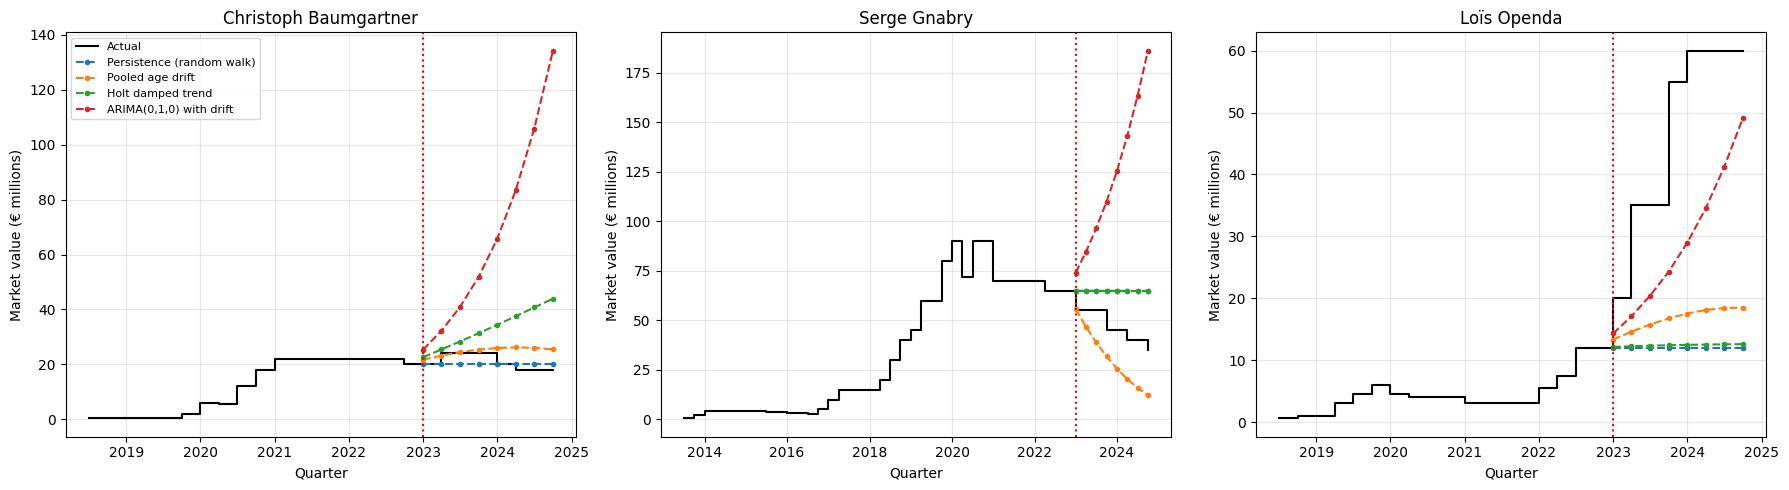

In [ ]:
# Plot actual vs selected forecasts for three representative players
plot_models = ["Persistence (random walk)", "Pooled age drift", "Holt damped trend", "ARIMA(0,1,0) with drift"]
pers_err = player_err["Persistence (random walk)"].sort_values()
showcase = [pers_err.index[0], pers_err.index[len(pers_err) // 2], pers_err.index[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pid in zip(axes, showcase):
    hist_rows = model_df[model_df["player_id"] == pid]
    ax.step(hist_rows["date"], hist_rows["value_m"], where="post", color="black", label="Actual")
    for m in plot_models:
        f = forecasts[(forecasts["player_id"] == pid) & (forecasts["model"] == m)]
        ax.plot(f["period"].dt.to_timestamp(), f["forecast_m"], linestyle="--", marker="o", markersize=3, label=m)
    ax.axvline(pd.Timestamp("2023-01-01"), color="red", linestyle=":")
    ax.set_title(hist_rows["name"].iloc[0])
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Market value (€ millions)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

ARIMA candidate checked: ARIMA(1,1,0)


,p-value lag 4,p-value lag 8,Remaining autocorrelation? (p < 0.05)
name,,,
Serge Gnabry,0.519,0.837,No evidence
Waldemar Anton,0.656,0.681,No evidence
Marcus Rashford,0.008,0.035,Possibly
Christoph Baumgartner,0.379,0.778,No evidence
Teun Koopmeiners,0.364,0.535,No evidence
Nayef Aguerd,0.347,0.597,No evidence
Jordan Teze,0.431,0.657,No evidence
Loïs Openda,0.316,0.636,No evidence
Phil Foden,0.744,0.730,No evidence


Players with no evidence of remaining autocorrelation: 14 of 15


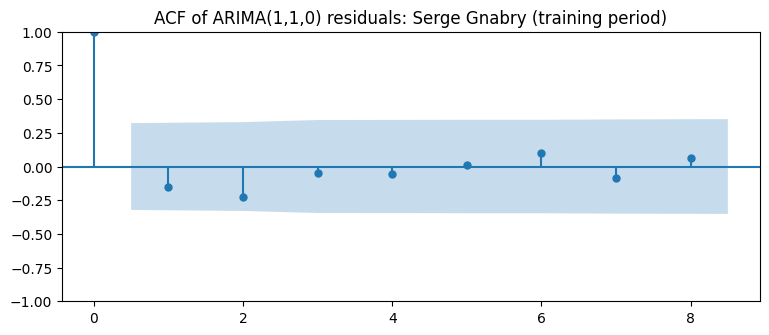

In [ ]:
# Residual diagnostics for the ARIMA candidate with the lowest € MAE
arima_scores = score_table(forecasts[forecasts["model"].isin(ARIMA_CANDIDATES)])
best_arima = arima_scores.index[0]
spec = ARIMA_CANDIDATES[best_arima]
print("ARIMA candidate checked:", best_arima)

lb_rows = []
for pid in player_ids:
    tr, _ = player_split(pid)
    fit = ARIMA(tr["log_value"].values, order=spec["order"], trend=spec["trend"]).fit()
    resid = fit.resid[1:]                                  # drop the first residual (no prior value)
    lb = acorr_ljungbox(resid, lags=[4, 8], return_df=True)
    lb_rows.append({"name": tr["name"].iloc[0],
                    "p-value lag 4": lb.loc[4, "lb_pvalue"], "p-value lag 8": lb.loc[8, "lb_pvalue"]})

lb_table = pd.DataFrame(lb_rows).set_index("name").round(3)
lb_table["Remaining autocorrelation? (p < 0.05)"] = np.where(
    (lb_table["p-value lag 4"] < 0.05) | (lb_table["p-value lag 8"] < 0.05), "Possibly", "No evidence")
display(lb_table)
print(f"Players with no evidence of remaining autocorrelation: "
      f"{(lb_table['Remaining autocorrelation? (p < 0.05)'] == 'No evidence').sum()} of {len(lb_table)}")

# ACF plot of residuals for the middle showcase player
tr, _ = player_split(showcase[1])
resid = ARIMA(tr["log_value"].values, order=spec["order"], trend=spec["trend"]).fit().resid[1:]
fig, ax = plt.subplots(figsize=(9, 3.5))
plot_acf(resid, lags=8, ax=ax)
ax.set_title(f"ACF of {best_arima} residuals: {tr['name'].iloc[0]} (training period)")
plt.show()

**Takeaway:** In our reproduction run the check used ARIMA(1,1,0). For 14 of 15 players the Ljung-Box test finds no evidence of remaining autocorrelation at lags 4 or 8. The exception is Marcus Rashford (p = 0.008 at lag 4), whose series has a sharp rise and fall that a short ARIMA does not capture. With 16-38 training quarters per player the test has limited power, so "no evidence" is weaker than "white noise confirmed". Check that the ACF bars in your run stay mostly inside the shaded band.

### 16.5 Do the transfer-window dummies measure the market or the update calendar?
**What we do:** Show, for each year and quarter, how many cohort quarters are forward-filled, and how many of all 508 players received a real Transfermarkt revision. The second table only **reads** the Phase 1 `hist` table; it does not change the modeling data. Then we estimate the window effects in the pooled model.

**Why:** If a quarter has no revisions, its value is a copy and its "change" is zero, whatever the transfer market did. If Transfermarkt changed *when* it revises values, the window dummies learned in training will not describe the test years.

**What to look for:** Whether Q3 (the summer-window quarter) still has revisions in 2023-2024.

In [ ]:
# Table 1: share of cohort quarters that are filled, by year and quarter
filled_calendar = (model_df[model_df["year"] >= 2017]
                   .pivot_table(index="year", columns="quarter_num", values="is_filled", aggfunc="mean")
                   .round(2))
filled_calendar.columns = [f"Q{q}" for q in filled_calendar.columns]
print("COHORT: SHARE OF QUARTERS THAT ARE FILLED (no real valuation)")
display(filled_calendar)

# Table 2 (read-only context): players with a real revision, by year and quarter, all 508 players
updates = hist.assign(y=hist["valuation_date"].dt.year, q=hist["valuation_date"].dt.quarter)
update_calendar = (updates[updates["y"].between(2017, 2025)]
                   .groupby(["y", "q"])["player_id"].nunique().unstack())
update_calendar.columns = [f"Q{q}" for q in update_calendar.columns]
print("\nALL 508 PLAYERS: NUMBER OF PLAYERS WITH A REAL REVISION")
display(update_calendar)

# Window effects estimated in the pooled model (training rows only)
pooled_windows = smf.ols("d_log_value ~ age + window_summer + window_winter", data=pooled_train).fit(
    cov_type="cluster", cov_kwds={"groups": pooled_train["player_id"]})
print("\nPOOLED MODEL WITH WINDOW DUMMIES (training rows)")
display(pd.DataFrame({"Coefficient": pooled_windows.params, "p-value": pooled_windows.pvalues}).round(4))

COHORT: SHARE OF QUARTERS THAT ARE FILLED (no real valuation)


,Q1,Q2,Q3,Q4
year,,,,
2017,0.00,0.00,0.57,0.25
2018,0.30,0.09,0.36,0.29
2019,0.20,0.00,0.33,0.07
2020,0.40,0.00,0.47,0.13
2021,0.13,0.00,1.00,0.07
2022,0.33,0.00,0.47,0.00
2023,0.33,0.00,1.00,0.00
2024,0.40,0.00,1.00,0.00



ALL 508 PLAYERS: NUMBER OF PLAYERS WITH A REAL REVISION


,Q1,Q2,Q3,Q4
y,,,,
2017,93,105,27,90
2018,104,160,65,161
2019,119,212,86,243
2020,116,257,161,273
2021,274,342,40,376
2022,149,408,186,440
2023,197,453,52,487
2024,231,495,29,501
2025,240,505,2,508



POOLED MODEL WITH WINDOW DUMMIES (training rows)


,Coefficient,p-value
Intercept,1.4446,0.0000
age,-0.0590,0.0000
window_summer,0.0790,0.2184
window_winter,0.0079,0.8564


**Takeaway:** In our reproduction run, **Q3 is 100% filled for every cohort player in both test years** (2023 Q3 and 2024 Q3). Across all 508 players, real Q3 revisions fell from 186 players in 2022 to 52 in 2023, 29 in 2024 and 2 in 2025, while Q2 and Q4 revisions reached almost every player. Transfermarkt appears to have moved to revising values mainly in June and December (our interpretation of the pattern; the data shows the timing, not the reason).

**What this means:** In training the summer dummy picks up a positive "summer jump" (about +0.079 log points in the pooled model, but with p = 0.22, so not statistically distinguishable from zero), but in the test window Q3 values are copies of Q2, so that jump cannot appear. The window dummies mostly measure **when Transfermarkt publishes revisions**, not transfer-market prices. We keep them because the proposal planned them, and we report this finding as a limitation and a lesson: an external regressor must mean the same thing in the future as it did in training.

**Production fix:** use actual transfer fees and dates (available in larger Transfermarkt datasets) instead of quarter-level window flags.

## 17. Model selection and handoff to the prototype

**Scope note:** This section produces the forecast table and the decision rule the prototype needs. It does not build the prototype interface.

### 17.1 Select the model the prototype uses
**What we do:** Pick the model with the lowest log MAE averaged over h = 2 and h = 4 (table 16.2).

**Why this rule:** The prototype shows forecasts 2 and 4 quarters ahead, so we select on exactly those horizons (professor's feedback point 2). We use the log scale so that one star player does not decide the choice and so that a 10% miss counts the same for every player. We also print the € MAE so the trade-off is visible: persistence wins on the 8-quarter € average (16.1). If the team prefers to select on € error, change `SELECTION_METRIC`.

In [ ]:
# Model selection on the prototype's horizons
SELECTION_METRIC = "MAE (log), avg of h=2 and h=4"   # change to "MAE (€M) h=4" to select on € error instead
selected_model = by_h[SELECTION_METRIC].idxmin()

print(f"Selection metric: {SELECTION_METRIC}")
print(f"Selected model:   {selected_model}")
display(by_h.loc[[selected_model, "Persistence (random walk)"]]
        if selected_model != "Persistence (random walk)" else by_h.loc[[selected_model]])

Selection metric: MAE (log), avg of h=2 and h=4
Selected model:   Pooled age drift


,MAE (log) h=2,MAE (log) h=4,MAE (€M) h=2,MAE (€M) h=4,"MAE (log), avg of h=2 and h=4"
model,,,,,
Pooled age drift,0.267,0.421,9.361,13.915,0.344
Persistence (random walk),0.285,0.470,8.467,12.633,0.377


### 17.2 Error band from the test window
**What we do:** Build an 80% band around the selected model's forecasts from its own test-window misses. For each horizon (2 and 4 quarters), we take the 10th and 90th percentiles of its log errors (actual minus forecast) across the 15 players.

**Why an empirical band:** Model-based intervals assume the model is correct. A band built from the model's real out-of-sample misses says how wrong it has actually been at that horizon, which is what a sporting director needs before setting a bid cap.

**Caveat:** Each band rests on 15 errors, so it is a rough estimate. In production we would build it from many forecast origins and many more players.

In [ ]:
# 80% empirical error band per horizon, from the selected model's test-window errors (log scale)
sel = forecasts[forecasts["model"] == selected_model].copy()
sel["err_log"] = sel["actual_log"] - sel["forecast_log"]       # positive = actual above forecast

error_band = (sel[sel["h"].isin(REPORT_H)]
              .groupby("h")["err_log"].quantile([0.10, 0.90]).unstack())
error_band.columns = ["low_err_log (10th pct)", "high_err_log (90th pct)"]
error_band["Band as % of forecast"] = [f"{100*(np.exp(lo)-1):+.0f}% to {100*(np.exp(hi)-1):+.0f}%"
                                       for lo, hi in error_band.values]
display(error_band.round(3))

,low_err_log (10th pct),high_err_log (90th pct),Band as % of forecast
h,,,
2,-0.276,0.532,-24% to +70%
4,-0.111,1.108,-10% to +203%


**Takeaway:** In our reproduction run the selected model is the pooled age-drift model. Its 80% band runs from about **-24% to +70%** around the forecast at 2 quarters ahead and **-10% to +203%** at 4 quarters ahead. The band is wide and tilted upward because, in 2023-2024, actual values rose faster than this model predicted (on average its forecasts were too low). The band therefore reflects the conditions of that one test period: if the market cools, values could fall below the lower edge more often than 10% of the time. Say this when presenting the band.

### 17.3 Forecasts the prototype uses (2025 Q2 and 2025 Q4)
**What we do:** Refit the selected model on all data through 2024 Q4, the end of the approved scope, and forecast 2 and 4 quarters ahead (2025 Q2 and 2025 Q4) for each player, with the 80% band from 17.2. The table is saved as `prototype_forecasts.csv`.

**Why refit:** Section 16 held out 2023-2024 to measure accuracy honestly. For the tool, we want forecasts from the latest data in scope.

**Note:** The dataset contains real 2025 values, excluded from modeling to match the approved proposal. They could later serve as an extra holdout to check these forecasts (see limitations).

In [ ]:
# Future rows for 2025 Q1-Q4: regressors are known in advance (age +0.25 per quarter, calendar dummies)
def future_rows(last_row, steps=4):
    rows = []
    for k in range(1, steps + 1):
        q = int(last_row["q_idx"]) + k
        qn = (q - 1) % 4 + 1
        rows.append({"player_id": last_row["player_id"], "q_idx": q, "quarter_num": qn,
                     "age": last_row["age"] + 0.25 * k,
                     "window_summer": int(qn == 3), "window_winter": int(qn == 1)})
    return pd.DataFrame(rows)

# Refit the pooled model on all rows in scope (used only if it is the selected model)
pooled_fit_full = smf.ols("d_log_value ~ age", data=quarterly_changes(model_df)).fit()

def forecast_selected(g_all, fut):
    # Forecast the selected model 1-4 quarters past 2024 Q4 for one player (log scale)
    y = g_all["log_value"].values
    last = y[-1]
    if selected_model == "Persistence (random walk)":
        return np.repeat(last, len(fut))
    if selected_model == "Rolling mean (4 quarters)":
        return np.repeat(y[-4:].mean(), len(fut))
    if selected_model == "Pooled age drift":
        return last + np.cumsum(pooled_fit_full.predict(fut).values)
    if selected_model in ARIMA_CANDIDATES:
        s = ARIMA_CANDIDATES[selected_model]
        return ARIMA(y, order=s["order"], trend=s["trend"]).fit().forecast(len(fut))
    if selected_model.startswith("Holt"):
        damped = "damped" in selected_model
        return ExponentialSmoothing(y, trend="add", damped_trend=damped).fit().forecast(len(fut))
    if selected_model in SARIMAX_SPECS:
        cols = SARIMAX_SPECS[selected_model]
        fit = SARIMAX(y, exog=g_all[cols].astype(float).values, order=(0, 1, 0)).fit(disp=False)
        return fit.forecast(len(fut), exog=fut[cols].astype(float).values)
    raise ValueError(f"No refit rule for {selected_model}")

proto_rows = []
for pid, g in model_df.groupby("player_id"):
    g = g.sort_values("q_idx")
    fut = future_rows(g.iloc[-1])
    fc_log = np.asarray(forecast_selected(g, fut))
    for h in REPORT_H:
        lo_err, hi_err = error_band.loc[h, ["low_err_log (10th pct)", "high_err_log (90th pct)"]]
        q = int(fut["q_idx"].iloc[h - 1])
        proto_rows.append({
            "player_id": pid, "name": g["name"].iloc[0], "league_name": g["league_name"].iloc[0],
            "value_2024Q4_m": round(g["value_m"].iloc[-1], 2),
            "target_quarter": f"{(q - 1) // 4}Q{(q - 1) % 4 + 1}", "h": h,
            "forecast_m": round(float(np.exp(fc_log[h - 1])), 2),
            "band_low_m": round(float(np.exp(fc_log[h - 1] + lo_err)), 2),
            "band_high_m": round(float(np.exp(fc_log[h - 1] + hi_err)), 2),
            "model": selected_model,
        })

prototype_forecasts = pd.DataFrame(proto_rows)
display(prototype_forecasts)
prototype_forecasts.to_csv("prototype_forecasts.csv", index=False)
print("Saved: prototype_forecasts.csv")

,player_id,name,league_name,value_2024Q4_m,target_quarter,h,forecast_m,band_low_m,band_high_m,model
0,159471,Serge Gnabry,Bundesliga,35.0,2025Q2,2,25.23,19.15,42.96,Pooled age drift
1,159471,Serge Gnabry,Bundesliga,35.0,2025Q4,4,17.39,15.56,52.66,Pooled age drift
2,193004,Waldemar Anton,Bundesliga,24.0,2025Q2,2,18.99,14.41,32.33,Pooled age drift
3,193004,Waldemar Anton,Bundesliga,24.0,2025Q4,4,14.36,12.86,43.50,Pooled age drift
4,258923,Marcus Rashford,La Liga,55.0,2025Q2,2,48.40,36.73,82.41,Pooled age drift
5,258923,Marcus Rashford,La Liga,55.0,2025Q4,4,40.71,36.45,123.33,Pooled age drift
6,324278,Christoph Baumgartner,Bundesliga,18.0,2025Q2,2,18.72,14.21,31.88,Pooled age drift
7,324278,Christoph Baumgartner,Bundesliga,18.0,2025Q4,4,18.62,16.67,56.40,Pooled age drift
8,360518,Teun Koopmeiners,Serie A,50.0,2025Q2,2,45.02,34.16,76.65,Pooled age drift
9,360518,Teun Koopmeiners,Serie A,50.0,2025Q4,4,38.75,34.69,117.39,Pooled age drift


Saved: prototype_forecasts.csv


### 17.4 Decision rule the prototype applies
**What we do:** Define the valuation alert from the proposal as one small function. Given a player, a horizon and a quoted fee, it compares the fee with the forecast band:
- **Above the band:** "Overvalued": the fee is higher than the value our model expects in 80% of cases. Negotiate down or walk away.
- **Inside the band:** "Fair range": the fee is consistent with the forecast.
- **Below the band:** "Undervalued": the fee is lower than expected. Worth pursuing.

It also returns a **sell / hold signal** from the direction of the forecast: if the value is forecast to fall by the target quarter, the window to sell is now; if it is forecast to rise, holding (or extending) preserves value.

**Why this rule is defensible:** The thresholds come from the model's own out-of-sample misses (17.2), not from a number we chose. A fee outside the band is one our model has rarely seen the market reach.

**Limitation to say out loud:** The target is Transfermarkt's estimated market value, not the fee clubs actually pay. The rule flags fees that are far from the market consensus; it does not predict negotiated prices.

In [ ]:
def valuation_verdict(player_name, h, quoted_fee_m):
    # Compare a quoted fee (€ millions) with the forecast band for one player and horizon (2 or 4 quarters)
    row = prototype_forecasts[(prototype_forecasts["name"] == player_name) & (prototype_forecasts["h"] == h)]
    if row.empty:
        raise ValueError("Unknown player or horizon. Use a cohort player's name and h = 2 or 4.")
    r = row.iloc[0]
    if quoted_fee_m > r["band_high_m"]:
        verdict = "OVERVALUED: the fee is above the forecast band"
    elif quoted_fee_m < r["band_low_m"]:
        verdict = "UNDERVALUED: the fee is below the forecast band"
    else:
        verdict = "FAIR RANGE: the fee is inside the forecast band"
    direction = "SELL WINDOW: value forecast to fall" if r["forecast_m"] < r["value_2024Q4_m"] \
        else "HOLD / EXTEND: value forecast to rise or hold"
    return pd.Series({
        "Player": r["name"], "Target quarter": r["target_quarter"],
        "Value at 2024 Q4 (€M)": r["value_2024Q4_m"], "Forecast (€M)": r["forecast_m"],
        "80% band (€M)": f"{r['band_low_m']} to {r['band_high_m']}",
        "Quoted fee (€M)": quoted_fee_m, "Valuation alert": verdict, "Timing signal": direction,
    }).to_frame("Result")

# Example: the first cohort player, 4 quarters ahead, with a fee 20% above the forecast
example = prototype_forecasts[prototype_forecasts["h"] == 4].iloc[0]
display(valuation_verdict(example["name"], 4, round(example["forecast_m"] * 1.2, 1)))

,Result
Player,Serge Gnabry
Target quarter,2025Q4
Value at 2024 Q4 (€M),35.0
Forecast (€M),17.39
80% band (€M),15.56 to 52.66
Quoted fee (€M),20.9
Valuation alert,FAIR RANGE: the fee is inside the forecast band
Timing signal,SELL WINDOW: value forecast to fall


**Takeaway:** The example shows the full chain the prototype needs: forecast, band, alert and timing signal. In our run the first player is Serge Gnabry (about 30 in 2025): the pooled model forecasts his value falling from €35M to about €17M by 2025 Q4. That decline comes from extending the age curve past the oldest training ages (see 15.3), so for players near 30 present the signal as "the model expects decline" rather than a precise figure.

## 18. Track B summary for the slides

**Results (confirm against your run; values below are from our reproduction run):**
- 8-quarter € average: **persistence** (MAE ≈ €13.3M) is effectively tied with SARIMAX (windows) (€13.2M), which is persistence plus small window premiums. Within Track B, no genuinely different model beat the random walk on this measure. Track A's € -scale Holt did (€11.85M in Track A's run, section 11.4); section 19 scores both tracks together.
- Prototype horizons (log MAE averaged over h = 2 and 4): **pooled age drift** is selected (0.344), ahead of Holt damped (0.367) and persistence (0.377). The margins are small.
- Trend-extrapolating models (ARIMA with drift, Holt linear trend, SARIMAX with age) performed worst (MAE above €53M) because they extend young players' growth indefinitely.
- Pooled aging curve: quarterly value growth falls by about 0.059 log points per year of age and reaches zero around age 25.
- Residual diagnostics: ARIMA(1,1,0) leaves no evidence of remaining autocorrelation for 14 of 15 players.
- Transfer-window dummies: Q3 revisions nearly disappeared after 2022, so the dummies measure Transfermarkt's revision calendar rather than the market.

**Phase 2 decisions log**

| Area | Decision | Reason |
|---|---|---|
| Target scale | Model log value; report in € millions | Values span €0.5M to €100M+; log errors are comparable percentages |
| Forecast design | One origin (2022 Q4), 8 quarters ahead | Same fit-then-forecast pattern as the course notebook |
| Benchmarks | Persistence (main) and 4-quarter rolling mean | Proposal; random walk is hard to beat for prices |
| Candidates | 4 ARIMA orders, Holt plain and damped, 2 SARIMAX, pooled age drift | Proposal models plus one panel-based model from notebook 03 |
| Regressors | Window dummies and age only | Both are known for future quarters |
| Evaluation | MAE, RMSE, MAPE, log MAE; all rows and observed-only; h = 2 and 4 | Proposal metrics; filled quarters; prototype horizons |
| Selection | Lowest log MAE averaged over h = 2 and 4 | Matches what the prototype shows |
| Uncertainty | 80% band from out-of-sample errors | Based on real misses, not model assumptions |

**Phase 2 limitations**
- **Small test sample:** 15 players and one forecast origin. Rankings could change with more players or rolling origins.
- **Selection on success:** the cohort is drawn from the most valuable players at the scrape date, so growth estimates are optimistic.
- **Window dummies measure Transfermarkt's revision calendar**, which changed over time (Q3 revisions nearly disappeared after 2022).
- **Target is Transfermarkt's estimate**, not actual transfer fees.
- **The error band rests on 15 errors per horizon** from one period (2023-2024) and is tilted upward by that period's rising values.
- **The pooled age curve is extrapolated** for players older than the oldest training ages (about 27).
- **2025 data was excluded** to match the approved scope; it could be used as an extra holdout.

## 19. Reconciling Track A and Track B

**Why this section exists:** The two tracks reach different conclusions on the same 120 test rows. Track A selects Holt's linear trend (lowest € RMSE over the 8 test quarters, section 11.4). Track B selects the model with the lowest log MAE at 2 and 4 quarters ahead (section 17.1), and in Track B, Holt's linear trend is among the worst models (section 16.1). Because the data and the split are identical, the difference comes from how the models were built and judged.

**Where the tracks differ**

| | Track A | Track B |
|---|---|---|
| Target | Value in € millions | Log of value |
| ARIMA and SARIMAX orders | Chosen per player by training AIC; candidates include a stationary AR(1) | Fixed orders, all with d = 1, the same for every player |
| SARIMAX regressors | Age and both window dummies | Window dummies, with and without age |
| Rolling mean | Arithmetic mean of the last 4 values | Mean of the last 4 log values (a geometric mean in €), so slightly lower |
| Holt | Plain linear trend | Plain and damped |
| Ranking rule | 8-quarter RMSE (€) | Log MAE averaged over h = 2 and h = 4 |
| Uncertainty band | Approx. 95%, from in-sample residuals, widened by √h | 80%, from out-of-sample test errors |

**Why Holt flips between the tracks:** An additive trend on the € scale adds a fixed number of euros each quarter. The same trend on the log scale adds a fixed *percentage* each quarter, and percentages compound. For example, a player who went from €5M to €40M over 16 training quarters grew about 14% per quarter on average. Track A's Holt extends that rise as a straight line in euros; Track B's Holt extends it as 14% growth compounding for 8 quarters, roughly tripling the value. Neither is a coding error: the scale decides what "trend" means, and young players' fast early growth is where the two diverge most.

**What we do below:**
1. Copy Track A's test forecasts into rows with Track B's columns (19.1).
2. Score every model from both tracks with Track B's `score_table`, on all rows and observed-only rows (19.2).
3. Score both tracks at the prototype's horizons and count how often each model beats persistence (19.3).
4. List which model wins under each ranking rule (19.4).

**What to look for:** Whether Track A's € -scale models also do well on the log and horizon measures Track B uses for selection, or only on the € measures.

### 19.1 Put Track A's forecasts in Track B's format

**What we do:** For each Track A model, copy its 120 test-row forecasts into rows with the same columns as Track B's `forecasts` table, labelled `A: ...`. The € errors use Track A's forecasts exactly as produced. Log errors need a positive forecast, so a forecast below €0.1M is raised to €0.1M **for the log metrics only**; the cell prints how many rows that affects.

**Check:** Track A's naive forecast and Track B's persistence forecast are the same number (Track B stores log(x) and converts back with exp), so their € forecasts must match row by row.

**What to look for:** All checks read `OK`, and the floor count is zero or very small.

In [ ]:
# Track A forecasts in Track B's format, so one scoring function covers both tracks
TRACK_A_MODELS = {
    "pred_naive":    "A: Naive",
    "pred_rolling4": "A: 4Q rolling mean (€ scale)",
    "pred_holt":     "A: Holt linear trend (€ scale)",
    "pred_arima":    "A: ARIMA, AIC order per player (€ scale)",
    "pred_sarimax":  "A: SARIMAX age + windows, AIC order (€ scale)",
}
LOG_FLOOR_M = 0.1   # € millions; used only to take the log of a zero or negative € forecast

a_test = test.sort_values(["player_id", "q_idx"]).copy()
a_test["h"] = a_test.groupby("player_id").cumcount() + 1   # quarters ahead of the 2022 Q4 origin

a_parts, floor_counts = [], {}
for col, label in TRACK_A_MODELS.items():
    fc_m = a_test[col].astype(float)
    floor_counts[label] = int((fc_m < LOG_FLOOR_M).sum())
    part = a_test[["player_id", "name", "q_idx", "period", "h", "is_filled"]].copy()
    part["model"] = label
    part["actual_m"] = a_test["value_m"].astype(float)
    part["actual_log"] = np.log(part["actual_m"])
    part["forecast_m"] = fc_m
    part["forecast_log"] = np.log(fc_m.clip(lower=LOG_FLOOR_M))
    part["abs_err_m"] = (part["actual_m"] - part["forecast_m"]).abs()
    part["abs_err_log"] = (part["actual_log"] - part["forecast_log"]).abs()
    part["ape"] = 100 * part["abs_err_m"] / part["actual_m"]
    a_parts.append(part)

track_a_forecasts = pd.concat(a_parts, ignore_index=True)
both_tracks = pd.concat([forecasts.assign(track="B"), track_a_forecasts.assign(track="A")], ignore_index=True)
both_tracks["is_filled"] = both_tracks["is_filled"].astype(bool)

# Checks (expected value next to the result)
key = ["player_id", "q_idx"]
pers = (track_a_forecasts[track_a_forecasts["model"] == "A: Naive"].set_index(key)["forecast_m"].rename("a")
        .to_frame()
        .join(forecasts[forecasts["model"] == "Persistence (random walk)"].set_index(key)["forecast_m"].rename("b"),
              how="outer"))
recon_checks = pd.DataFrame([
    ["Track A test rows", len(a_test), len(test_df)],
    ["Rows present in only one track", int(pers.isna().any(axis=1).sum()), 0],
    ["Rows where A's naive and B's persistence differ by > €0.001M", int(((pers["a"] - pers["b"]).abs() > 1e-3).sum()), 0],
    ["Track A rows with h outside 1-8", int((~a_test["h"].between(1, 8)).sum()), 0],
], columns=["Check", "Result", "Expected"])
recon_checks["Status"] = np.where(recon_checks["Result"] == recon_checks["Expected"], "OK", "REVIEW")
print("RECONCILIATION CHECKS")
display(recon_checks)

print("\nTrack A forecasts below €0.1M (raised to €0.1M for log metrics only):")
display(pd.Series(floor_counts, name="rows").to_frame())

RECONCILIATION CHECKS


,Check,Result,Expected,Status
0,Track A test rows,120,120,OK
1,Rows present in only one track,0,0,OK
2,Rows where A's naive and B's persistence differ by > €0.001M,0,0,OK
3,Track A rows with h outside 1-8,0,0,OK



Track A forecasts below €0.1M (raised to €0.1M for log metrics only):


,rows
A: Naive,0
A: 4Q rolling mean (€ scale),0
A: Holt linear trend (€ scale),0
"A: ARIMA, AIC order per player (€ scale)",0
"A: SARIMAX age + windows, AIC order (€ scale)",0


### 19.2 Both tracks on one scoreboard

**What we do:** Score all models from both tracks with Track B's `score_table` (MAE, RMSE and MAPE in € plus MAE on the log scale), on all test rows and on observed-only rows. Track A models are labelled `A: ...`; Track B labels are unchanged.

**What to look for:** Whether the € ranking (where Track A's Holt led in section 11.4) and the log ranking agree. `A: Naive` and `Persistence (random walk)` should have identical € scores.

In [ ]:
print("BOTH TRACKS: ALL TEST ROWS (2023-2024)")
display(score_table(both_tracks))
print("\nBOTH TRACKS: OBSERVED-ONLY TEST ROWS (quarters with a real valuation)")
display(score_table(both_tracks[~both_tracks["is_filled"]]))

BOTH TRACKS: ALL TEST ROWS (2023-2024)


,MAE (€M),RMSE (€M),MAPE (%),MAE (log),Rows
model,,,,,
A: Holt linear trend (€ scale),11.847,16.042,29.450,0.357,120
"A: SARIMAX age + windows, AIC order (€ scale)",12.349,17.022,30.999,0.369,120
SARIMAX (windows),13.171,17.570,32.375,0.447,120
A: Naive,13.262,17.361,32.897,0.452,120
Persistence (random walk),13.262,17.361,32.897,0.452,120
"A: ARIMA, AIC order per player (€ scale)",13.291,17.068,33.159,0.458,120
"ARIMA(1,1,0)",13.590,17.331,34.115,0.480,120
"ARIMA(0,1,1)",14.010,17.820,35.173,0.496,120
Pooled age drift,14.414,19.610,33.904,0.475,120



BOTH TRACKS: OBSERVED-ONLY TEST ROWS (quarters with a real valuation)


,MAE (€M),RMSE (€M),MAPE (%),MAE (log),Rows
model,,,,,
A: Holt linear trend (€ scale),12.770,16.932,31.754,0.390,79
"A: SARIMAX age + windows, AIC order (€ scale)",13.112,17.925,32.909,0.402,79
"A: ARIMA, AIC order per player (€ scale)",14.024,17.941,35.295,0.494,79
A: Naive,14.101,18.131,35.045,0.487,79
Persistence (random walk),14.101,18.131,35.045,0.487,79
SARIMAX (windows),14.172,18.273,35.288,0.494,79
"ARIMA(1,1,0)",14.388,18.155,36.169,0.519,79
"ARIMA(0,1,1)",14.855,18.656,37.344,0.536,79
Pooled age drift,15.054,20.262,35.278,0.500,79


### 19.3 Both tracks at the prototype's horizons

**What we do:** Repeat Track B's horizon table (16.2) and the beats-persistence count (16.3) with Track A's models included.

**What to look for:** Whether Track A's Holt keeps its lead at 2 and 4 quarters ahead and on the log scale, or whether its advantage comes from the longer horizons and the high-value players that dominate € metrics.

In [ ]:
# Horizon table for both tracks (same construction as 16.2)
at_h_both = both_tracks[both_tracks["h"].isin(REPORT_H)]
by_h_both = at_h_both.pivot_table(index="model", columns="h", values=["abs_err_log", "abs_err_m"], aggfunc="mean")
by_h_both.columns = [f"{'MAE (log)' if m == 'abs_err_log' else 'MAE (€M)'} h={h}" for m, h in by_h_both.columns]
by_h_both["MAE (log), avg of h=2 and h=4"] = by_h_both[[f"MAE (log) h={h}" for h in REPORT_H]].mean(axis=1)
by_h_both = by_h_both.sort_values("MAE (log), avg of h=2 and h=4").round(3)
print("BOTH TRACKS: ACCURACY AT THE PROTOTYPE'S HORIZONS")
display(by_h_both)

# Players where each model beats persistence (average log error over the 8 test quarters, same as 16.3)
player_err_both = both_tracks.groupby(["model", "player_id"])["abs_err_log"].mean().unstack("model")
pers_err_both = player_err_both["Persistence (random walk)"]
beats_both = pd.DataFrame({
    "Players where model beats persistence": player_err_both.lt(pers_err_both, axis=0).sum(),
    "Out of": len(player_err_both),
}).drop(index=["Persistence (random walk)", "A: Naive"]).sort_values(
    "Players where model beats persistence", ascending=False)
print("\nBOTH TRACKS: PLAYERS WHERE EACH MODEL BEATS PERSISTENCE")
display(beats_both)

BOTH TRACKS: ACCURACY AT THE PROTOTYPE'S HORIZONS


,MAE (log) h=2,MAE (log) h=4,MAE (€M) h=2,MAE (€M) h=4,"MAE (log), avg of h=2 and h=4"
model,,,,,
A: Holt linear trend (€ scale),0.243,0.338,7.858,11.354,0.290
"A: SARIMAX age + windows, AIC order (€ scale)",0.256,0.366,8.544,12.200,0.311
Pooled age drift,0.267,0.421,9.361,13.915,0.344
Holt damped trend,0.320,0.415,11.335,17.140,0.367
Persistence (random walk),0.285,0.470,8.467,12.633,0.377
SARIMAX (windows),0.285,0.470,8.467,12.633,0.377
A: Naive,0.285,0.470,8.467,12.633,0.377
"A: ARIMA, AIC order per player (€ scale)",0.290,0.496,9.238,13.980,0.393
"ARIMA(1,1,0)",0.320,0.507,9.819,13.389,0.414



BOTH TRACKS: PLAYERS WHERE EACH MODEL BEATS PERSISTENCE


,Players where model beats persistence,Out of
model,,
A: Holt linear trend (€ scale),12,15
Holt damped trend,12,15
"A: SARIMAX age + windows, AIC order (€ scale)",11,15
Pooled age drift,8,15
"ARIMA(1,1,1)",7,15
Holt linear trend,6,15
SARIMAX (windows),5,15
Rolling mean (4 quarters),5,15
A: 4Q rolling mean (€ scale),5,15


### 19.4 Which model wins under each ranking rule

**What we do:** List the winning model under each rule the two tracks used, and compare it with the model Track B handed to the prototype in section 17.

**What to look for:** If one model wins every rule, the choice is easy. If the € rules and the horizon rule pick different models, the team has to choose which rule matches what the prototype promises a sporting director.

In [ ]:
scores_all = score_table(both_tracks)
scores_obs = score_table(both_tracks[~both_tracks["is_filled"]])
winners = pd.DataFrame([
    ["Track A rule: lowest 8-quarter RMSE (€M), all rows", scores_all["RMSE (€M)"].idxmin()],
    ["Lowest 8-quarter MAE (€M), all rows", scores_all["MAE (€M)"].idxmin()],
    ["Lowest 8-quarter MAE (€M), observed-only rows", scores_obs["MAE (€M)"].idxmin()],
    ["Lowest 8-quarter MAE (log), all rows", scores_all["MAE (log)"].idxmin()],
    [f"Track B rule: lowest {SELECTION_METRIC}", by_h_both[SELECTION_METRIC].idxmin()],
], columns=["Ranking rule (both tracks' models)", "Winning model"])
display(winners)
print(f"Model Track B handed to the prototype in 17.1 (Track B models only): {selected_model}")

,Ranking rule (both tracks' models),Winning model
0,"Track A rule: lowest 8-quarter RMSE (€M), all rows",A: Holt linear trend (€ scale)
1,"Lowest 8-quarter MAE (€M), all rows",A: Holt linear trend (€ scale)
2,"Lowest 8-quarter MAE (€M), observed-only rows",A: Holt linear trend (€ scale)
3,"Lowest 8-quarter MAE (log), all rows",A: Holt linear trend (€ scale)
4,"Track B rule: lowest MAE (log), avg of h=2 and h=4",A: Holt linear trend (€ scale)


Model Track B handed to the prototype in 17.1 (Track B models only): Pooled age drift


### 19.5 Decision the team needs to make before the slides

**Resolved in section 20:** the final model is chosen there on forecast origins before the test window, so the choice does not depend on the 2023-2024 results shown above.

The notebook now contains two complete forecasting answers:
- **Track A:** Holt on the € scale, a four-quarter forecast with an approximate 95% interval (12.2), and a fee-versus-range rule described in text (12.3; not yet coded).
- **Track B:** the model selected in 17.1, an 80% band from out-of-sample errors (17.2), `prototype_forecasts.csv` (17.3) and the `valuation_verdict()` function (17.4).

The prototype should present one of them. How to use 19.2-19.4:
- If the team judges models on € error over all 8 test quarters, use the 19.2 tables (Track A's rule).
- If the team judges models on the horizons the prototype shows (the professor's feedback point 2), use the 19.3 table (Track B's rule).
- If a Track A model wins the rule the team picks, section 17 cannot use it yet: `forecast_selected()` only has refit rules for Track B's models. Either add a refit rule for that model or present Track A's 12.2 forecast table, and note that its band is built differently from Track B's.

Whichever model is chosen, state on the slides that Holt's ranking depends on the scale it is fit on (section 19 intro). That is a finding in its own right: whether a forecast is judged in euros or in percentages changes which model looks best.

---
# Final model (combines Track A and Track B)

## 20. Final model: choosing on earlier periods, then testing

**Why this section exists:** Section 19 showed that Track A's € -scale Holt wins every ranking rule on the 2023-2024 test window. But that window is one 8-quarter period for 15 players, and we have now looked at 16 models on it. Picking the best of many on the same rows we report tends to overstate how well the winner will do next time.

**What we do:** Choose the final model on **validation origins inside the training period**, then report the test window as a confirmation:
1. Re-forecast from four earlier origins (2020 Q2, 2020 Q4, 2021 Q2, 2021 Q4), 1-4 quarters ahead each. All of these forecasts and their actual values are before 2023, so the test window is never used to choose (20.1-20.2).
2. Compare candidates from both tracks plus four combinations of them (listed below).
3. Pick the model with the lowest validation log MAE averaged over h = 2 and h = 4, the same rule Track B used (20.3).
4. Build the 80% band from that model's **validation** errors, so its coverage can be checked honestly on the test window (20.4).
5. Refit on all data through 2024 Q4, forecast 2025 Q2 and 2025 Q4, and check those forecasts against the real 2025 values the dataset contains, which no model has seen (20.5-20.6).
6. Give the prototype one fee-check function (20.7).

**Candidates**

| Model | From | Idea |
|---|---|---|
| Persistence | Both | Last value repeated |
| Holt, € scale | Track A (9) | Trend in euros per quarter |
| SARIMAX, AIC order per player, € scale | Track A (11) | Age and window regressors |
| Pooled age drift, log scale | Track B (15.3) | One aging curve across players |
| Holt damped, log scale | Track B (15.1) | Percentage trend that fades |
| **Holt damped, € scale** | Combination | Track A's scale with Track B's damping |
| Average of € Holt and pooled age drift | Combination | Averages the two tracks' best ideas (in log space) |
| € Holt, trend stops at zero-growth age | Combination | € Holt, but the trend ends once the player reaches the age where the pooled curve says growth stops |
| ARIMA, AIC order per player, log scale | Combination | Track A's order selection on Track B's scale |

**What to look for:** A model that beats persistence in both the validation periods and the test window, not just one.

### 20.1 Backtest settings and forecasting functions

**What we do:** Set the origins and write one function per candidate. Every function takes a player's history up to an origin and returns € forecasts for the next quarters. The pooled age-drift model is refit at each origin on rows up to that origin only.

**Decisions:**
- **A player is included at an origin only with 8+ quarters of history**, so short series do not get trend models fit on a handful of points.
- **Holt and SARIMAX settings match Track A exactly**; damped Holt adds only `damped_trend=True`. ARIMA uses Track A's order list (`candidate_orders`) and SARIMAX Track A's (`sarimax_orders`).
- **Log errors need positive forecasts**, so € forecasts below `LOG_FLOOR_M` (€0.1M, from 19.1) are raised to it for the log metrics only.

In [ ]:
# Backtest settings: forecast origins inside the training period (no 2023-2024 data is used to choose)
VAL_ORIGINS = [2020 * 4 + 2, 2020 * 4 + 4, 2021 * 4 + 2, 2021 * 4 + 4]   # 2020 Q2, 2020 Q4, 2021 Q2, 2021 Q4
VAL_H       = 4               # quarters ahead from each validation origin; the last target is 2022 Q4
MIN_TRAIN_Q = 8               # a player needs 8+ quarters of history at an origin to be included
TEST_ORIGIN = FORECAST_ORIGIN # 2022 Q4, the origin both tracks used
FINAL_EXOG  = ["age", "window_winter", "window_summer"]   # Track A's SARIMAX regressors

fm_data = model_df.sort_values(["player_id", "q_idx"]).reset_index(drop=True)

def fm_pooled_fit(rows):
    # Pooled age-drift regression (Track B, 15.3) on the rows given
    d = rows.sort_values(["player_id", "q_idx"]).copy()
    d["d_log_value"] = d.groupby("player_id")["log_value"].diff()
    return smf.ols("d_log_value ~ age", data=d.dropna(subset=["d_log_value"])).fit()

def fm_holt_eur(y, h, damped):
    fit = Holt(y, damped_trend=damped, initialization_method="estimated").fit(optimized=True)
    return np.asarray(fit.forecast(h), dtype=float)

def fm_aic_arima(y, h):
    best_aic, best = np.inf, None
    for order in candidate_orders:            # Track A's ARIMA order list (10.1)
        try:
            fit = ARIMA(y, order=order).fit()
            if np.isfinite(fit.aic) and fit.aic < best_aic:
                best_aic, best = fit.aic, fit
        except Exception:
            continue
    return np.asarray(best.forecast(h), dtype=float)

def fm_aic_sarimax(y, X, X_future, h):
    best_aic, best = np.inf, None
    for order in sarimax_orders:              # Track A's SARIMAX order list (11.2)
        try:
            fit = SARIMAX(y, exog=X, order=order, seasonal_order=(0, 0, 0, 0),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if np.isfinite(fit.aic) and fit.aic < best_aic:
                best_aic, best = fit.aic, fit
        except Exception:
            continue
    return np.asarray(best.get_forecast(steps=h, exog=X_future).predicted_mean, dtype=float)

def fm_forecasts(hist_rows, future_rows, pooled):
    # All candidates' € forecasts for one player. hist_rows: history up to the origin;
    # future_rows: the quarters to forecast (needs q_idx, age, window_winter, window_summer)
    y, ly, h = hist_rows["value_m"].to_numpy(float), hist_rows["log_value"].to_numpy(float), len(future_rows)
    zero_growth_age = -pooled.params["Intercept"] / pooled.params["age"]
    f = {}
    f["Persistence"] = np.repeat(y[-1], h)
    f["Holt, € scale (Track A)"] = fm_holt_eur(y, h, damped=False)
    f["Holt damped, € scale (combination)"] = fm_holt_eur(y, h, damped=True)
    f["SARIMAX AIC, € scale (Track A)"] = fm_aic_sarimax(
        y, hist_rows[FINAL_EXOG].astype(float).values, future_rows[FINAL_EXOG].astype(float).values, h)
    pooled_log = ly[-1] + np.cumsum(pooled.predict(future_rows).values)
    f["Pooled age drift, log scale (Track B)"] = np.exp(pooled_log)
    f["Holt damped, log scale (Track B)"] = np.exp(
        ExponentialSmoothing(ly, trend="add", damped_trend=True).fit().forecast(h))
    f["Average of € Holt and pooled age drift (combination)"] = np.exp(
        (np.log(np.maximum(f["Holt, € scale (Track A)"], LOG_FLOOR_M)) + pooled_log) / 2)
    quarters_before_peak = int((future_rows["age"].to_numpy() < zero_growth_age).sum())
    holt = f["Holt, € scale (Track A)"]
    f["€ Holt, trend stops at zero-growth age (combination)"] = np.array(
        [y[-1] if quarters_before_peak == 0 else holt[min(k, quarters_before_peak) - 1] for k in range(1, h + 1)])
    f["ARIMA AIC per player, log scale (combination)"] = np.exp(fm_aic_arima(ly, h))
    return f

def fm_backtest(origin, horizon):
    # Forecast every eligible player from one origin; one row per player, quarter and model
    pooled = fm_pooled_fit(fm_data[fm_data["q_idx"] <= origin])
    rows = []
    for pid, g in fm_data.groupby("player_id"):
        hist_rows = g[g["q_idx"] <= origin]
        fut = g[(g["q_idx"] > origin) & (g["q_idx"] <= origin + horizon)]
        if len(hist_rows) < MIN_TRAIN_Q or len(fut) < horizon:
            continue
        for model, fc in fm_forecasts(hist_rows, fut, pooled).items():
            for h, (_, r), fc_m in zip(range(1, horizon + 1), fut.iterrows(), fc):
                rows.append({"origin": origin, "player_id": pid, "name": r["name"], "h": h, "model": model,
                             "actual_m": r["value_m"], "forecast_m": fc_m, "is_filled": r["is_filled"]})
    out = pd.DataFrame(rows)
    out["err_log"] = np.log(out["actual_m"]) - np.log(out["forecast_m"].clip(lower=LOG_FLOOR_M))  # + = actual above
    out["abs_err_log"] = out["err_log"].abs()
    out["abs_err_m"] = (out["actual_m"] - out["forecast_m"]).abs()
    return out

print("Forecasting functions ready.")

Forecasting functions ready.


### 20.2 Run the backtest: validation origins and the test origin

**What we do:** Forecast from each validation origin (1-4 quarters ahead) and from the 2022 Q4 test origin (1-8 quarters ahead, the same task as both tracks).

**Checks:** The test-origin forecasts for persistence and € Holt must equal Track A's (8.3 and 9.1), because they are the same models on the same data.

**What to look for:** All checks read `OK`; the validation set has about 60 player-origins.

In [ ]:
val_bt  = pd.concat([fm_backtest(o, VAL_H) for o in VAL_ORIGINS], ignore_index=True)
test_bt = fm_backtest(TEST_ORIGIN, len(test_df[test_df["player_id"] == player_ids[0]]))
FINAL_MODELS = list(val_bt["model"].unique())

def fm_mae_eur(df, model):
    return df.loc[df["model"] == model, "abs_err_m"].mean()

final_checks = pd.DataFrame([
    ["Validation targets dated before 2023", int((val_bt["origin"] + val_bt["h"] < TEST_START_Q).all()), 1],
    ["Test-origin persistence MAE equals Track A naive (8.3)",
     int(np.isclose(fm_mae_eur(test_bt, "Persistence"), naive_all["MAE"])), 1],
    ["Test-origin € Holt MAE equals Track A Holt (9.2)",
     int(np.isclose(fm_mae_eur(test_bt, "Holt, € scale (Track A)"), holt_all["MAE"])), 1],
    ["Test rows per model", int(len(test_bt) / len(FINAL_MODELS)), len(test_df)],
], columns=["Check", "Result", "Expected"])
final_checks["Status"] = np.where(final_checks["Result"] == final_checks["Expected"], "OK", "REVIEW")
display(final_checks)
print(f"Validation player-origins: {val_bt.groupby(['origin', 'player_id']).ngroups}  "
      f"(players per origin: {val_bt.groupby('origin')['player_id'].nunique().tolist()})")

,Check,Result,Expected,Status
0,Validation targets dated before 2023,1,1,OK
1,Test-origin persistence MAE equals Track A naive (8.3),1,1,OK
2,Test-origin € Holt MAE equals Track A Holt (9.2),1,1,OK
3,Test rows per model,120,120,OK


Validation player-origins: 59  (players per origin: [14, 15, 15, 15])


### 20.3 Choose the final model on the validation origins

**What we do:** Score every candidate with log MAE at h = 2 and h = 4 (Track B's rule) and € MAE, separately on the validation origins and on the test origin, and pick the lowest **validation** log MAE.

**How sure can we be?** For each model we also compare its log error with persistence's for every player-origin, and resample whole players 4,000 times to get a 95% interval for the average difference. An interval that includes 0 means the data cannot tell the model from persistence.

**What to look for:** Whether the validation winner also beats persistence on the test window.

In [ ]:
def fm_scores(df):
    at_h = df[df["h"].isin(REPORT_H)]
    by_h = at_h.groupby(["model", "h"])["abs_err_log"].mean().unstack("h")
    return pd.DataFrame({"log MAE h=2": by_h[2], "log MAE h=4": by_h[4],
                         "log MAE, avg h=2 & h=4": by_h[REPORT_H].mean(axis=1),
                         "MAE (€M), all h": df.groupby("model")["abs_err_m"].mean()})

val_scores, test_scores = fm_scores(val_bt), fm_scores(test_bt)
FINAL_MODEL = val_scores["log MAE, avg h=2 & h=4"].idxmin()

score_compare = pd.concat({"Validation (2020-2022 origins)": val_scores, "Test (2022 Q4 origin)": test_scores},
                          axis=1).sort_values(("Validation (2020-2022 origins)", "log MAE, avg h=2 & h=4"))
print("CANDIDATES: VALIDATION vs TEST (sorted by validation log MAE, the selection rule)")
display(score_compare.round(3))
print(f"\nFinal model (lowest validation log MAE at h = 2 and 4): {FINAL_MODEL}")

# Difference from persistence, per player-origin, with a 95% interval from resampling players
rng = np.random.default_rng(5671)
def fm_vs_persistence(df, model, n_boot=4000):
    unit = df[df["h"].isin(REPORT_H)].groupby(["model", "origin", "player_id"])["abs_err_log"].mean().unstack("model")
    diff = unit[model] - unit["Persistence"]
    by_player = diff.groupby(level="player_id").agg(["sum", "size"])
    pids = by_player.index.to_numpy()
    boot = []
    for _ in range(n_boot):
        s = by_player.loc[rng.choice(pids, len(pids), replace=True)]
        boot.append(s["sum"].sum() / s["size"].sum())
    return diff.mean(), np.percentile(boot, 2.5), np.percentile(boot, 97.5), int((diff < 0).sum()), len(diff)

rows = []
for model in FINAL_MODELS:
    if model == "Persistence":
        continue
    for label, df in [("Validation", val_bt), ("Test", test_bt)]:
        d, lo, hi, wins, n = fm_vs_persistence(df, model)
        rows.append({"model": model, "period": label, "mean diff vs persistence (log)": d,
                     "95% interval": f"{lo:+.3f} to {hi:+.3f}", "beats persistence": f"{wins} of {n}"})
vs_persistence = pd.DataFrame(rows).pivot(index="model", columns="period")
vs_persistence = vs_persistence.reindex(score_compare.index.drop("Persistence"))
print("\nDIFFERENCE FROM PERSISTENCE (negative = better than persistence; log MAE at h = 2 and 4)")
display(vs_persistence.round(3))

CANDIDATES: VALIDATION vs TEST (sorted by validation log MAE, the selection rule)


Validation (2020-2022 origins)  \
                                                                        log MAE h=2   
model                                                                                 
Holt damped, € scale (combination)                                            0.342   
SARIMAX AIC, € scale (Track A)                                                0.343   
Persistence                                                                   0.352   
Average of € Holt and pooled age drift (combination)                          0.350   
€ Holt, trend stops at zero-growth age (combination)                          0.349   
Holt, € scale (Track A)                                                       0.359   
Pooled age drift, log scale (Track B)                                         0.371   
Holt damped, log scale (Track B)                                              0.391   
ARIMA AIC per player, log scale (combination)                                 0.434   

                                                                  \
                                                     log MAE h=4   
model                                                              
Holt damped, € scale (combination)                         0.505   
SARIMAX AIC, € scale (Track A)                             0.512   
Persistence                                                0.538   
Average of € Holt and pooled age drift (combination)       0.564   
€ Holt, trend stops at zero-growth age (combination)       0.570   
Holt, € scale (Track A)                                    0.581   
Pooled age drift, log scale (Track B)                      0.599   
Holt damped, log scale (Track B)                           0.599   
ARIMA AIC per player, log scale (combination)              0.600   

                                                                             \
                                                     log MAE, avg h=2 & h=4   
model                                                                         
Holt damped, € scale (combination)                                    0.424   
SARIMAX AIC, € scale (Track A)                                        0.427   
Persistence                                                           0.445   
Average of € Holt and pooled age drift (combination)                  0.457   
€ Holt, trend stops at zero-growth age (combination)                  0.460   
Holt, € scale (Track A)                                               0.470   
Pooled age drift, log scale (Track B)                                 0.485   
Holt damped, log scale (Track B)                                      0.495   
ARIMA AIC per player, log scale (combination)                         0.517   

                                                                      \
                                                     MAE (€M), all h   
model                                                                  
Holt damped, € scale (combination)                             6.546   
SARIMAX AIC, € scale (Track A)                                 7.850   
Persistence                                                    6.721   
Average of € Holt and pooled age drift (combination)           8.460   
€ Holt, trend stops at zero-growth age (combination)           6.892   
Holt, € scale (Track A)                                        7.644   
Pooled age drift, log scale (Track B)                         10.397   
Holt damped, log scale (Track B)                              11.365   
ARIMA AIC per player, log scale (combination)                  8.434   

                                                     Test (2022 Q4 origin)  \
                                                               log MAE h=2   
model                                                                        
Holt damped, € scale (combination)                                   0.243   
SARIMAX AIC, € scale (Track A)                                   


Final model (lowest validation log MAE at h = 2 and 4): Holt damped, € scale (combination)

DIFFERENCE FROM PERSISTENCE (negative = better than persistence; log MAE at h = 2 and 4)


mean diff vs persistence (log)  \
period                                                                         Test   
model                                                                                 
Holt damped, € scale (combination)                                           -0.081   
SARIMAX AIC, € scale (Track A)                                               -0.066   
Average of € Holt and pooled age drift (combination)                         -0.083   
€ Holt, trend stops at zero-growth age (combination)                         -0.082   
Holt, € scale (Track A)                                                      -0.087   
Pooled age drift, log scale (Track B)                                        -0.033   
Holt damped, log scale (Track B)                                             -0.010   
ARIMA AIC per player, log scale (combination)                                 0.039   

                                                                 \
period                                               Validation   
model                                                             
Holt damped, € scale (combination)                       -0.022   
SARIMAX AIC, € scale (Track A)                           -0.018   
Average of € Holt and pooled age drift (combination)      0.012   
€ Holt, trend stops at zero-growth age (combination)      0.015   
Holt, € scale (Track A)                                   0.025   
Pooled age drift, log scale (Track B)                     0.040   
Holt damped, log scale (Track B)                          0.050   
ARIMA AIC per player, log scale (combination)             0.072   

                                                          95% interval  \
period                                                            Test   
model                                                                    
Holt damped, € scale (combination)                    -0.144 to -0.026   
SARIMAX AIC, € scale (Track A)                        -0.113 to -0.016   
Average of € Holt and pooled age drift (combination)  -0.173 to +0.009   
€ Holt, trend stops at zero-growth age (combination)  -0.146 to -0.021   
Holt, € scale (Track A)                               -0.156 to -0.021   
Pooled age drift, log scale (Track B)                 -0.155 to +0.093   
Holt damped, log scale (Track B)                      -0.108 to +0.097   
ARIMA AIC per player, log scale (combination)         -0.040 to +0.119   

                                                                        \
period                                                      Validation   
model                                                                    
Holt damped, € scale (combination)                    -0.094 to +0.052   
SARIMAX AIC, € scale (Track A)                        -0.084 to +0.042   
Average of € Holt and pooled age drift (combination)  -0.090 to +0.107   
€ Holt, trend stops at zero-growth age (combination)  -0.091 to +0.141   
Holt, € scale (Track A)                               -0.082 to +0.152   
Pooled age drift, log scale (Track B)                 -0.078 to +0.164   
Holt damped, log scale (Track B)                      -0.064 to +0.175   
ARIMA AIC per player, log scale (combination)         +0.032 to +0.115   

                                                     beats persistence  \
period                                                            Test   
model                                                                    
Holt damped, € scale (combination)                            14 of 15   
SARIMAX AIC, € scale (Track A)                                12 of 15   
Average of € Holt and pooled age drift (combination)          10 of 15   
€ Holt, trend stops at zero-growth age (combination)           9 of 15   
Holt, € scale (Track A)                                       13 of 15   
Pooled age drift, log scale (Track B)                         10 of 15   
Holt damped, log scale (Track B)                             

**Takeaway:** In our run the damped € Holt (Track A's scale with Track B's damping) has the lowest validation log MAE (0.424), just ahead of Track A's SARIMAX (0.427) and persistence (0.445), so it is the final model. On the test window it scores 0.297, close to Track A's undamped Holt (0.290), and beats persistence for 14 of 15 players; its 95% interval for the difference from persistence (-0.144 to -0.026) excludes zero. On validation the margins are small and every interval includes zero, so the edge over persistence is modest. Track A's undamped Holt is worse than persistence on validation (0.470), and so are all three log-scale models (0.485 to 0.517).

### 20.4 Uncertainty band from validation errors, checked on the test window

**What we do:** Build the final model's 80% band from its **validation** log errors: the 10th and 90th percentiles at h = 2 and h = 4. Because the band never saw 2023-2024, its coverage on the test window is a fair check. We run the same check on Track A's interval (in-sample residuals, 1.96 × sd × √h, labelled 95%).

**Why not Track B's band (17.2):** it was built from the test-window errors, so its test coverage is about 80% by construction and cannot be checked.

**Caveat:** Each coverage rate rests on 15 players, so one player moves it by about 7 percentage points. Read the rates as rough.

In [ ]:
fin_val = val_bt[val_bt["model"] == FINAL_MODEL]
fin_test = test_bt[test_bt["model"] == FINAL_MODEL]
final_band = (fin_val[fin_val["h"].isin(REPORT_H)].groupby("h")["err_log"]
              .quantile([0.10, 0.90]).unstack())
final_band.columns = ["low_err_log", "high_err_log"]

band_rows = []
for h in REPORT_H:
    lo, hi = final_band.loc[h]
    t = fin_test[fin_test["h"] == h]
    band_rows.append({"Band": "Final model: 80% band from validation errors", "h": h,
                      "Band as % of forecast": f"{100*(np.exp(lo)-1):+.0f}% to {100*(np.exp(hi)-1):+.0f}%",
                      "Target coverage": "80%", "Test coverage": t["err_log"].between(lo, hi).mean()})

# Track A's interval, rebuilt at the test origin the way 12.2 builds it (in-sample residual sd, 1.96 x sqrt(h))
for h in REPORT_H:
    covered, widths = [], []
    for pid in player_ids:
        tr, te = player_split(pid)
        y = tr["value_m"].to_numpy(float)
        fit = Holt(y, initialization_method="estimated").fit(optimized=True)
        sd = np.std(y - np.asarray(fit.fittedvalues), ddof=1)
        fc, width = fit.forecast(h)[-1], 1.96 * sd * np.sqrt(h)
        covered.append(fc - width <= te["value_m"].iloc[h - 1] <= fc + width)
        widths.append(width / fc)
    band_rows.append({"Band": "Track A: approx. 95% interval (in-sample residuals)", "h": h,
                      "Band as % of forecast": f"±{100*np.median(widths):.0f}% (median player)",
                      "Target coverage": "95%", "Test coverage": np.mean(covered)})

band_check = pd.DataFrame(band_rows)
band_check["Test coverage"] = (100 * band_check["Test coverage"]).round(0).astype(int).astype(str) + "%"
display(band_check)

,Band,h,Band as % of forecast,Target coverage,Test coverage
0,Final model: 80% band from validation errors,2,-27% to +135%,80%,93%
1,Final model: 80% band from validation errors,4,-39% to +190%,80%,93%
2,Track A: approx. 95% interval (in-sample residuals),2,±30% (median player),95%,80%
3,Track A: approx. 95% interval (in-sample residuals),4,±38% (median player),95%,80%


**Takeaway:** In our run the final model's 80% band runs from -27% to +135% around the forecast at 2 quarters ahead and -39% to +190% at 4 quarters ahead. It covered 93% of test values at both horizons, so it was wider than needed for 2023-2024. Track A's interval, labelled 95%, covered 80%: in-sample residuals understate real forecast misses. The band leans upward because values mostly rose after the validation origins; 20.6 shows what that costs in a falling year.

### 20.5 Forecasts the prototype uses (2025 Q2 and 2025 Q4)

**What we do:** Refit the final model on all data through 2024 Q4 (the end of the approved scope) and forecast 2 and 4 quarters ahead, with the 80% band from 20.4. Saved as `final_forecasts.csv`. We also store every candidate's 2025 forecasts for the check in 20.6.

In [ ]:
pooled_full = fm_pooled_fit(fm_data)
future_by_player, all_2025 = {}, []
for pid, g in fm_data.groupby("player_id"):
    fut = future_rows(g.iloc[-1], steps=max(REPORT_H)).assign(name=g["name"].iloc[0])  # Track B helper (17.3)
    future_by_player[pid] = fut
    for model, fc in fm_forecasts(g, fut, pooled_full).items():
        for h in REPORT_H:
            all_2025.append({"player_id": pid, "name": g["name"].iloc[0], "model": model, "h": h,
                             "q_idx": int(fut["q_idx"].iloc[h - 1]), "forecast_m": float(fc[h - 1]),
                             "value_2024Q4_m": float(g["value_m"].iloc[-1])})
all_2025 = pd.DataFrame(all_2025)

final_forecasts = all_2025[all_2025["model"] == FINAL_MODEL].copy()
final_forecasts["target_quarter"] = final_forecasts["q_idx"].map(lambda q: f"{(q - 1) // 4}Q{(q - 1) % 4 + 1}")
final_forecasts["band_low_m"] = final_forecasts.apply(
    lambda r: max(r["forecast_m"], LOG_FLOOR_M) * np.exp(final_band.loc[r["h"], "low_err_log"]), axis=1)
final_forecasts["band_high_m"] = final_forecasts.apply(
    lambda r: max(r["forecast_m"], LOG_FLOOR_M) * np.exp(final_band.loc[r["h"], "high_err_log"]), axis=1)
final_forecasts = (final_forecasts.merge(model_df.groupby("player_id")["league_name"].last(), on="player_id")
                   [["player_id", "name", "league_name", "value_2024Q4_m", "target_quarter", "h",
                     "forecast_m", "band_low_m", "band_high_m", "model"]]
                   .sort_values(["name", "h"]).round(2).reset_index(drop=True))
display(final_forecasts)
final_forecasts.to_csv("final_forecasts.csv", index=False)
print("Saved: final_forecasts.csv")

,player_id,name,league_name,value_2024Q4_m,target_quarter,h,forecast_m,band_low_m,band_high_m,model
0,324278,Christoph Baumgartner,Bundesliga,18.0,2025Q2,2,17.59,12.83,41.28,"Holt damped, € scale (combination)"
1,324278,Christoph Baumgartner,Bundesliga,18.0,2025Q4,4,17.33,10.61,50.34,"Holt damped, € scale (combination)"
2,364245,Jordan Teze,Ligue 1,15.0,2025Q2,2,16.01,11.67,37.55,"Holt damped, € scale (combination)"
3,364245,Jordan Teze,Ligue 1,15.0,2025Q4,4,17.00,10.41,49.38,"Holt damped, € scale (combination)"
4,557149,Kang-in Lee,Ligue 1,30.0,2025Q2,2,32.13,23.43,75.39,"Holt damped, € scale (combination)"
5,557149,Kang-in Lee,Ligue 1,30.0,2025Q4,4,34.24,20.96,99.45,"Holt damped, € scale (combination)"
6,463618,Khéphren Thuram,Serie A,35.0,2025Q2,2,34.79,25.36,81.61,"Holt damped, € scale (combination)"
7,463618,Khéphren Thuram,Serie A,35.0,2025Q4,4,34.69,21.24,100.75,"Holt damped, € scale (combination)"
8,368887,Loïs Openda,Serie A,60.0,2025Q2,2,59.45,43.34,139.48,"Holt damped, € scale (combination)"
9,368887,Loïs Openda,Serie A,60.0,2025Q4,4,58.82,36.00,170.81,"Holt damped, € scale (combination)"


Saved: final_forecasts.csv


### 20.6 Extra holdout: the real 2025 values

**What we do:** Phase 1 kept 2025 out of the modeling to match the approved scope and noted it as a possible extra holdout. Here we use it: for each player, the actual value at the end of 2025 Q2 and 2025 Q4 is the last Transfermarkt valuation dated in or before that quarter (read from Phase 1's `hist`, which is not changed). Every candidate was refit only on data through 2024 Q4, so these values were never seen by any model or by the selection in 20.3.

**What to look for:** Whether the final model still beats persistence on a period that played no part in building or choosing it, and how often the 2025 values land inside the 80% band.

**Caveat:** 15 players and two horizons, so 30 forecasts per model.

In [ ]:
# Actual value at the end of each 2025 target quarter: last valuation dated in or before that quarter
hist_cohort = hist[hist["player_id"].isin(player_ids)].sort_values(["player_id", "valuation_date"])
def fm_value_at(pid, q):
    rows = hist_cohort[(hist_cohort["player_id"] == pid) & (hist_cohort["q_idx"] <= q)]
    return rows["value_m"].iloc[-1], bool((rows["q_idx"] == q).any())

ho = all_2025.copy()
ho[["actual_m", "observed_in_quarter"]] = ho.apply(lambda r: pd.Series(fm_value_at(r["player_id"], r["q_idx"])), axis=1)
ho["abs_err_log"] = (np.log(ho["actual_m"]) - np.log(ho["forecast_m"].clip(lower=LOG_FLOOR_M))).abs()
ho["abs_err_m"] = (ho["actual_m"] - ho["forecast_m"]).abs()

holdout_scores = ho.pivot_table(index="model", columns="h", values="abs_err_log", aggfunc="mean")
holdout_scores.columns = [f"log MAE h={h} (2025Q{2 if h == 2 else 4})" for h in holdout_scores.columns]
holdout_scores["log MAE, avg h=2 & h=4"] = holdout_scores.mean(axis=1)
holdout_scores["MAE (€M), avg"] = ho.groupby("model")["abs_err_m"].mean()
holdout_scores = holdout_scores.sort_values("log MAE, avg h=2 & h=4")
print("EXTRA HOLDOUT: REAL 2025 VALUES (models fit through 2024 Q4)")
display(holdout_scores.round(3))

fin_ho = ho[ho["model"] == FINAL_MODEL].merge(
    final_forecasts[["player_id", "h", "band_low_m", "band_high_m"]], on=["player_id", "h"])
fin_ho["in_band"] = fin_ho["actual_m"].between(fin_ho["band_low_m"], fin_ho["band_high_m"])
print(f"Final model: 2025 values inside the 80% band: {fin_ho['in_band'].sum()} of {len(fin_ho)} "
      f"(h=2: {fin_ho.loc[fin_ho['h'] == 2, 'in_band'].sum()} of 15, h=4: {fin_ho.loc[fin_ho['h'] == 4, 'in_band'].sum()} of 15)")
print(f"Target-quarter values that are real valuations (not carried forward): "
      f"{ho.drop_duplicates(['player_id', 'h'])['observed_in_quarter'].mean():.0%}")
d = (ho[ho["model"] == FINAL_MODEL].set_index(["player_id", "h"])["abs_err_log"]
     - ho[ho["model"] == "Persistence"].set_index(["player_id", "h"])["abs_err_log"])
print(f"Final model beats persistence on {(d < 0).sum()} of {len(d)} player-horizons, ties on {(d == 0).sum()}")

# Which way did values move in 2025, and on which side did the band miss?
moves = ho.drop_duplicates(["player_id", "h"]).assign(change=lambda x: x["actual_m"] / x["value_2024Q4_m"] - 1)
for h in REPORT_H:
    m = moves[moves["h"] == h]
    print(f"Real change from 2024 Q4 to 2025Q{2 if h == 2 else 4}: median {m['change'].median():+.0%}, "
          f"{(m['change'] < 0).sum()} of {len(m)} players fell")
print(f"Final model band misses: {(fin_ho['actual_m'] < fin_ho['band_low_m']).sum()} below the band, "
      f"{(fin_ho['actual_m'] > fin_ho['band_high_m']).sum()} above")

EXTRA HOLDOUT: REAL 2025 VALUES (models fit through 2024 Q4)


,log MAE h=2 (2025Q2),log MAE h=4 (2025Q4),"log MAE, avg h=2 & h=4","MAE (€M), avg"
model,,,,
"Pooled age drift, log scale (Track B)",0.256,0.303,0.279,13.033
Average of € Holt and pooled age drift (combination),0.273,0.295,0.284,12.715
"ARIMA AIC per player, log scale (combination)",0.297,0.348,0.323,14.103
Persistence,0.302,0.350,0.326,13.467
"Holt, € scale (Track A)",0.300,0.353,0.327,13.803
"Holt damped, € scale (combination)",0.308,0.361,0.335,14.118
"€ Holt, trend stops at zero-growth age (combination)",0.299,0.372,0.336,14.299
"SARIMAX AIC, € scale (Track A)",0.322,0.389,0.356,15.185
"Holt damped, log scale (Track B)",0.346,0.455,0.400,18.283


Final model: 2025 values inside the 80% band: 20 of 30 (h=2: 8 of 15, h=4: 12 of 15)
Target-quarter values that are real valuations (not carried forward): 100%
Final model beats persistence on 13 of 30 player-horizons, ties on 0
Real change from 2024 Q4 to 2025Q2: median -25%, 12 of 15 players fell
Real change from 2024 Q4 to 2025Q4: median -25%, 11 of 15 players fell
Final model band misses: 10 below the band, 0 above


**Takeaway:** In our run 2025 was a falling year for this cohort: 11 of 15 players lost value by 2025 Q4 (median -25%). That reverses the ranking. The final model scores 0.335, slightly worse than persistence (0.326), and beats it on 13 of 30 player-horizons. Track B's pooled age-drift model is best (0.279), followed by the average of € Holt and pooled age drift (0.284): the aging curve predicts declines for players past about 25, and most of this cohort is 24-29. Only 20 of 30 values fell inside the final model's 80% band, and all 10 misses were below it.

We do not switch models here. 2025 was held out to test the choice; choosing on it would leave no honest check.

### 20.7 Forecast plots for three players

**What we do:** Plot the history through 2024 Q4, the final model's forecasts for 2025 Q2 and 2025 Q4 with the 80% band, and the real 2025 values: the most valuable player, the youngest and the oldest.

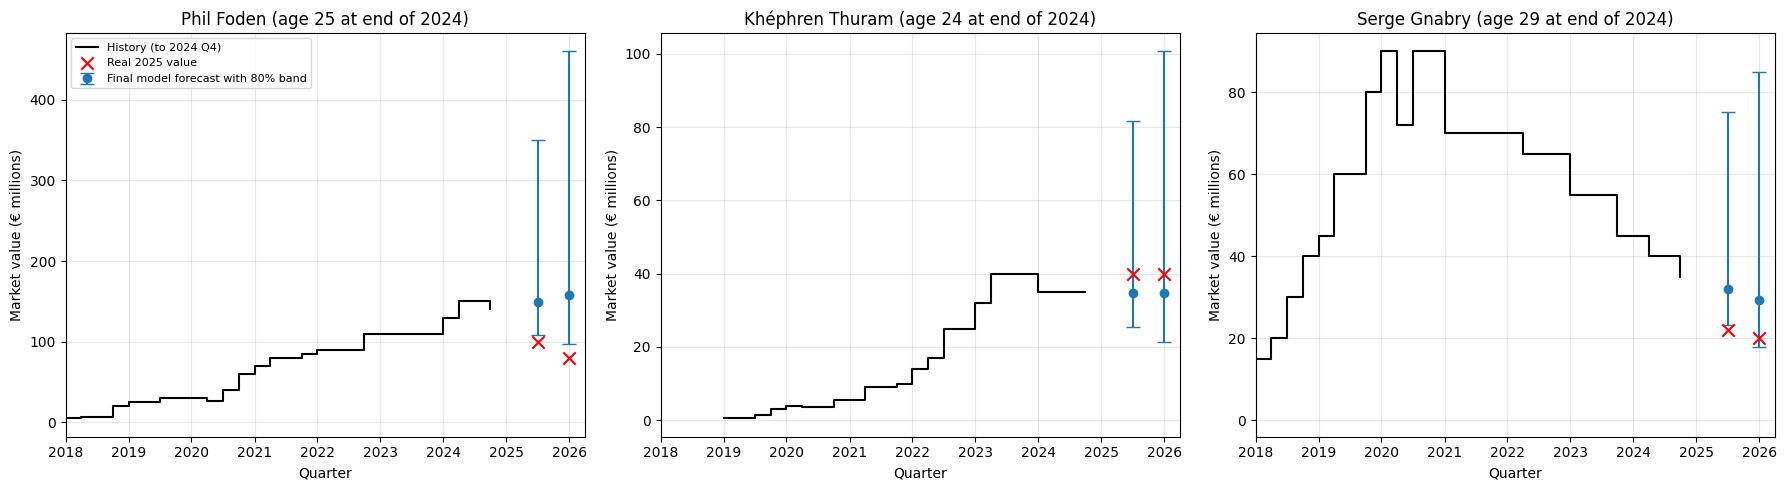

In [ ]:
last_rows = fm_data.groupby("player_id").tail(1).set_index("player_id")
showcase_final = [last_rows["value_m"].idxmax(), last_rows["age"].idxmin(), last_rows["age"].idxmax()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pid in zip(axes, showcase_final):
    g = fm_data[fm_data["player_id"] == pid]
    ax.step(g["date"], g["value_m"], where="post", color="black", label="History (to 2024 Q4)")
    f = final_forecasts[final_forecasts["player_id"] == pid]
    f_dates = pd.PeriodIndex(f["target_quarter"], freq="Q").to_timestamp(how="end")
    yerr = [f["forecast_m"] - f["band_low_m"], f["band_high_m"] - f["forecast_m"]]
    ax.errorbar(f_dates, f["forecast_m"], yerr=yerr, fmt="o", color="tab:blue", capsize=5,
                label="Final model forecast with 80% band")
    a = fin_ho[fin_ho["player_id"] == pid]
    ax.scatter(pd.PeriodIndex([f"{(q - 1)//4}Q{(q - 1) % 4 + 1}" for q in a["q_idx"]], freq="Q").to_timestamp(how="end"),
               a["actual_m"], marker="x", s=80, color="red", zorder=5, label="Real 2025 value")
    ax.set_title(f"{g['name'].iloc[0]} (age {last_rows.loc[pid, 'age']:.0f} at end of 2024)")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Market value (€ millions)")
    ax.set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-03-31"))
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 20.8 Fee check the prototype applies

**What we do:** The same rule as Track B's `valuation_verdict()` (17.4), applied to the final model's forecasts and band:
- **Above the band:** overvalued: negotiate down or walk away.
- **Inside the band:** fair range.
- **Below the band:** undervalued: worth pursuing.

It also returns the timing signal: if the value is forecast to fall by the target quarter, the window to sell is now; otherwise hold or extend.

**Limitation to say out loud:** the target is Transfermarkt's estimated value, not the fee clubs actually pay.

In [ ]:
def final_verdict(player_name, h, quoted_fee_m):
    # Compare a quoted fee (€ millions) with the final model's band for one player and horizon (2 or 4)
    row = final_forecasts[(final_forecasts["name"] == player_name) & (final_forecasts["h"] == h)]
    if row.empty:
        raise ValueError("Unknown player or horizon. Use a cohort player's name and h = 2 or 4.")
    r = row.iloc[0]
    if quoted_fee_m > r["band_high_m"]:
        verdict = "OVERVALUED: the fee is above the forecast band"
    elif quoted_fee_m < r["band_low_m"]:
        verdict = "UNDERVALUED: the fee is below the forecast band"
    else:
        verdict = "FAIR RANGE: the fee is inside the forecast band"
    timing = ("SELL WINDOW: value forecast to fall" if r["forecast_m"] < r["value_2024Q4_m"]
              else "HOLD / EXTEND: value forecast to rise or hold")
    return pd.Series({
        "Player": r["name"], "Target quarter": r["target_quarter"],
        "Value at 2024 Q4 (€M)": r["value_2024Q4_m"], "Forecast (€M)": r["forecast_m"],
        "80% band (€M)": f"{r['band_low_m']} to {r['band_high_m']}",
        "Quoted fee (€M)": quoted_fee_m, "Valuation alert": verdict, "Timing signal": timing,
    }).to_frame("Result")

# Example: the most valuable player, 4 quarters ahead, with a fee 30% above the forecast
ex = final_forecasts[(final_forecasts["player_id"] == showcase_final[0]) & (final_forecasts["h"] == 4)].iloc[0]
display(final_verdict(ex["name"], 4, round(ex["forecast_m"] * 1.3, 1)))

,Result
Player,Phil Foden
Target quarter,2025Q4
Value at 2024 Q4 (€M),140.0
Forecast (€M),158.45
80% band (€M),96.99 to 460.14
Quoted fee (€M),206.0
Valuation alert,FAIR RANGE: the fee is inside the forecast band
Timing signal,HOLD / EXTEND: value forecast to rise or hold


## 21. Final summary for the slides

### 21.1 Every candidate across the three periods

**What we do:** Put each candidate's log MAE (averaged over h = 2 and h = 4) for the three periods side by side, and count the periods where it beats persistence. The chart shows five models: the benchmark, each track's best idea, the final model and the best combination on 2025.

LOG MAE, AVERAGE OF h = 2 AND h = 4 (lower is better)


,Validation (2020-2022 origins),Test (2023-2024),2025 holdout,Periods beating persistence
model,,,,
"Holt damped, € scale (combination)",0.424,0.297,0.335,2 of 3
"SARIMAX AIC, € scale (Track A)",0.427,0.311,0.356,2 of 3
Persistence,0.445,0.377,0.326,benchmark
Average of € Holt and pooled age drift (combination),0.457,0.294,0.284,2 of 3
"€ Holt, trend stops at zero-growth age (combination)",0.460,0.295,0.336,1 of 3
"Holt, € scale (Track A)",0.470,0.290,0.327,1 of 3
"Pooled age drift, log scale (Track B)",0.485,0.344,0.279,2 of 3
"Holt damped, log scale (Track B)",0.495,0.367,0.400,1 of 3
"ARIMA AIC per player, log scale (combination)",0.517,0.417,0.323,1 of 3


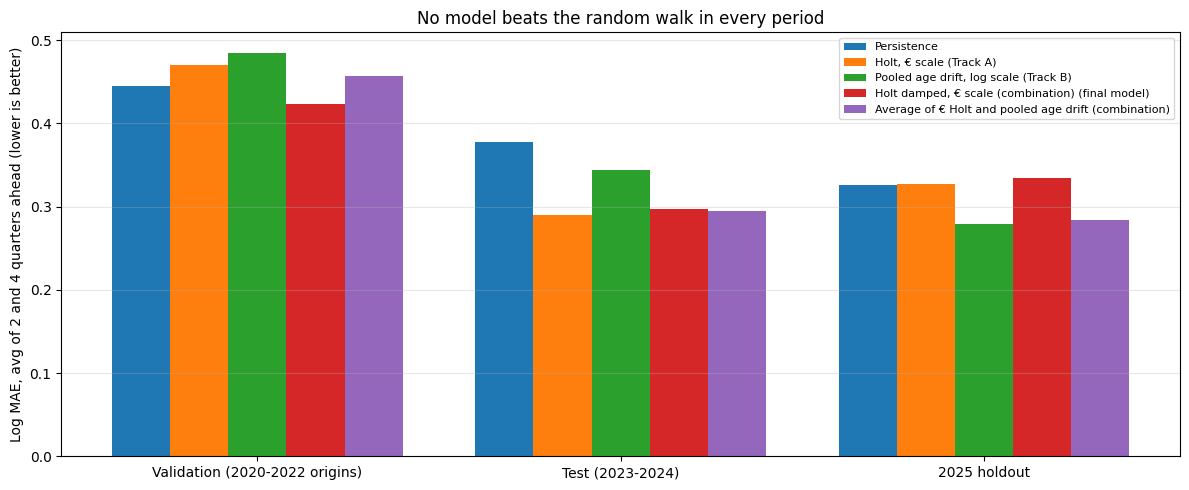

In [ ]:
cross = pd.DataFrame({
    "Validation (2020-2022 origins)": val_scores["log MAE, avg h=2 & h=4"],
    "Test (2023-2024)": test_scores["log MAE, avg h=2 & h=4"],
    "2025 holdout": holdout_scores["log MAE, avg h=2 & h=4"],
})
periods = list(cross.columns)
cross["Periods beating persistence"] = (cross[periods].lt(cross.loc["Persistence", periods], axis=1)
                                        .sum(axis=1).astype(str) + " of 3")
cross.loc["Persistence", "Periods beating persistence"] = "benchmark"
cross = cross.sort_values(periods[0])
print("LOG MAE, AVERAGE OF h = 2 AND h = 4 (lower is better)")
display(cross.round(3))

chart_models = ["Persistence", "Holt, € scale (Track A)", "Pooled age drift, log scale (Track B)",
                FINAL_MODEL, "Average of € Holt and pooled age drift (combination)"]
fig, ax = plt.subplots(figsize=(12, 5))
width = 0.16
x = np.arange(len(periods))
for i, m in enumerate(chart_models):
    ax.bar(x + (i - 2) * width, cross.loc[m, periods].astype(float), width,
           label=m + (" (final model)" if m == FINAL_MODEL else ""))
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.set_ylabel("Log MAE, avg of 2 and 4 quarters ahead (lower is better)")
ax.set_title("No model beats the random walk in every period")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Takeaway:** In our run no model beats persistence in all three periods. Four models beat it in two of three, and which two depends on the market: trend models win when values rise (2023-2024) and the aging curve wins when they fall (2025).

### 21.2 Results (values from our run)
- **Final model:** Holt damped on the € scale, chosen on 2020-2022 origins before the test window. It beat persistence in validation (log MAE 0.424 vs 0.445) and in 2023-2024 (0.297 vs 0.377, 14 of 15 players), but not on real 2025 values (0.335 vs 0.326).
- **Scale matters:** the same Holt model is the best € model on the test window (MAE €11.85M, Track A) and among the worst on the log scale (€55.2M, Track B), because a trend on the log scale compounds.
- **Aging curve:** quarterly value growth falls by about 0.059 log points for each year of age and reaches zero near age 25. It was the weakest idea in a rising market and the best in 2025's falling one.
- **Transfer-window dummies** mostly measure when Transfermarkt publishes revisions (Q3 revisions nearly disappeared after 2022), not market prices.
- **Uncertainty:** the 80% band from validation errors covered 93% of 2023-2024 values but only 20 of 30 in 2025, all misses below the band. Track A's 95% interval covered 80% on the test window.

### 21.3 Decisions log

| Area | Decision | Reason |
|---|---|---|
| Model choice | Lowest validation log MAE at h = 2 and 4 | Made before the test window and before 2025 were used |
| Final model | Holt damped, € scale | Track A's scale with Track B's damping; lowest validation error |
| Band | 80%, from validation errors | Never saw 2023-2025, so its coverage can be checked |
| 2025 data | Extra holdout only | Approved scope ends in 2024; used to check, never to choose |

### 21.4 Limitations
- 15 players, selected for long, successful careers; results may not hold for young or low-value players.
- Each comparison rests on 15 players per period; most differences between models are within resampling noise.
- The target is Transfermarkt's estimate, not the fee clubs pay.
- The band is wide (about -40% to +190% at 4 quarters) and leans upward; in a falling market it misses on the low side.
- The aging curve is extrapolated for players older than the oldest training ages (about 27).